# Notebook 1 of 4 -- Research foundations: the mathematics behind a 0.9008-versus-0.3730 result

A ConvGRU speech-command classifier reached 0.9008 validation accuracy where a globally-average-pooled CNN reached
0.3730. This notebook derives the mathematics that is supposed to explain why, and states honestly where the
literature and our measurements agree, disagree, or cannot be compared. It covers: the traceability table for every
borrowed method; why a recurrent head preserves the temporal order that global average pooling destroys; a real
tension with the CRNN paper's noise-adaptation mechanism (our `gru` is the *worst* arm under `noise_10`); neural
collapse with its terminal-phase precondition and two measurement deviations; adaptive gradient clipping;
calibration (temperature scaling, ECE, MDCA); the salvaged derivations of proper scoring rules and conformal risk
control with a Monte-Carlo check; and limitations. No model is trained here: measured quantities are loaded from
the real run's artifacts, and it runs locally on CPU in well under a minute. Single seed, exploration configuration
(4 stress conditions, 200 bootstrap resamples): none of the parallels drawn below is a causal claim.

In [1]:
# Shared setup: root-independent imports, seed, palette, labelled self-check helper.
from pathlib import Path
import sys

_here = Path.cwd().resolve()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 20260926
PALETTE = {
    "clean": "#1f77b4", "shifted": "#d62728", "mask": "#ff7f0e", "acoustic": "#2ca02c",
    "frozen": "#9467bd", "adapted": "#8c564b", "reference": "#7f7f7f", "band": "#c7c7c7",
}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

CHECKS = []
def check(label, passed, detail=""):
    """Print `[label] detail -> PASS|FAIL`; never loosen a tolerance to force PASS. Use note() for honest misses."""
    CHECKS.append((label, bool(passed), "PASS" if passed else "FAIL"))
    print(f"[{label}] {detail} -> {'PASS' if passed else 'FAIL'}")
    return bool(passed)

def note(label, detail):
    CHECKS.append((label, True, "NOTE"))
    print(f"[{label}] {detail} -> NOTE")

def check_summary():
    fails = [c[0] for c in CHECKS if c[2] == "FAIL"]
    print(f"{len(CHECKS)} labelled lines; {sum(c[2]=='PASS' for c in CHECKS)} PASS, "
          f"{sum(c[2]=='NOTE' for c in CHECKS)} NOTE, {len(fails)} FAIL {fails}")

## 1. Charter and traceability

**What this notebook is.** A mathematical foundation for one measured result: a ConvGRU speech-command
classifier (`gru`, 291,564 parameters) reached a validation accuracy of $0.9008$, while the project's legacy
globally-average-pooled CNN (`baseline`, a `LogMelCNN` with 14,524 parameters) ended at $0.3730$ on the same
seed. The notebook derives the mathematics that is *supposed* to explain that gap, and it says plainly where
the literature and our measurements agree, where they disagree, and where they simply cannot be compared.

**What this notebook is not.** It trains nothing. It runs on a CPU in well under a minute. Every measured
quantity is read from files that a real GPU run produced (`runtime/metrics/arch-*.result.json`,
`arch-*.probes.npz`, and the legacy training logs), and every literature quantity is read from the NotebookLM
NotebookLM sessions recorded in the traceability table of section 1.2. The few constructed inputs that do appear (a simplex equiangular tight
frame, a permuted feature map, a Monte-Carlo draw of exchangeable scores) are **unit-test fixtures for a
formula or estimator**, are labelled as such at the cell, and are never presented as evidence about speech.

**Reading discipline.** Three kinds of statement are kept apart throughout.

- *Paper claim*: something a source paper states, tagged with the arXiv id and the NotebookLM turn that
  returned it.
- *Derived here*: algebra that this notebook proves and then checks numerically.
- *Measured here*: a number loaded from an artifact, printed by a code cell, with the file it came from.

A parallel between a paper claim and a measured number is an *observation*, never a causal claim. The last
section collects every reason that is so.

**Section map.** Section 2 derives why a recurrent head preserves what global average pooling destroys.
Section 3 is the honest tension: under the `noise_10` stress condition our `gru` is the *worst* of three
arms, the reverse of the mechanism the CRNN paper proposes. Section 4 derives neural-collapse metrics NC1 and
NC2 and states, before any comparison, the precondition and the measurement deviations. Section 5 derives
adaptive gradient clipping. Section 6 covers calibration, including the one observation about fitted
temperatures that is worth testing. Section 7 carries the salvaged derivations (proper scoring rules,
temperature scaling as maximum likelihood, and the conformal-risk-control estimator with its Monte-Carlo
check). Section 8 lists the limitations.

In [2]:
# N1.1.1: shared loader. Real artifacts only; there is no synthetic fallback for measured quantities.
import json, re, hashlib, platform
import pandas as pd
pd.set_option("display.notebook_repr_html", False)
pd.set_option("display.width", 220, "display.max_colwidth", 130, "display.max_columns", 30)
from IPython.display import display
from scipy import stats

MET = ROOT / "runtime" / "metrics"
FIGDIR = ROOT / "runtime" / "figures" / "nb1"
FIGDIR.mkdir(parents=True, exist_ok=True)
ARCHS = ["gru", "timepool", "wide"]
ACOL = {"gru": "#3568A8", "timepool": "#E58B2A", "wide": "#3A8D68", "baseline": "#7f7f7f"}

if not all((MET / f"arch-{a}.result.json").exists() for a in ARCHS):
    raise FileNotFoundError(f"arch-*.result.json not found under {MET}; runtime/ is git-ignored and this notebook has no synthetic fallback")

DATA = {}
for a in ARCHS:
    _z = np.load(MET / f"arch-{a}.probes.npz")
    DATA[a] = {"res": json.loads((MET / f"arch-{a}.result.json").read_text()), "npz": {k: _z[k] for k in _z.files}}

# Legacy LogMelCNN ("baseline") clean-condition logs, seeds 17/18/19: parse every finished epoch.
LEG = {}
for s in (17, 18, 19):
    txt = (MET / "legacy_6arm_logs" / f"clean_seed{s}.log").read_text()
    rows = re.findall(r"epoch (\d+)/36 done: train_loss=([\d.]+) val_loss=([\d.]+) val_accuracy=([\d.]+)", txt)
    LEG[s] = pd.DataFrame(rows, columns=["epoch", "train_loss", "val_loss", "val_accuracy"]).astype(float)

def savefig(fig, name):
    # Save under runtime/figures/nb1/ and show inline.
    fig.savefig(FIGDIR / name, dpi=110, bbox_inches="tight")
    plt.show()
    return FIGDIR / name

def varied(label, *arrays):
    # A figure whose plotted values are all identical is a defect; make that a visible check.
    def _flat(x):
        if isinstance(x, (list, tuple)):
            return [q for item in x for q in _flat(item)]
        return [np.ravel(np.asarray(x, dtype=float))]
    v = np.concatenate([q for x in arrays for q in _flat(x)])
    return check(label, np.isfinite(v).all() and np.ptp(v) > 0, f"plotted values finite and not all identical (range {np.ptp(v):.4g})")

print("host:", platform.node(), "| metrics dir:", MET, "| figure dir:", FIGDIR)
for a in ARCHS:
    r = DATA[a]["res"]
    print(f"loaded {a:9s} params={r['parameters']:>8,d} epochs_run={r['epochs_run']:>2d} best_epoch={r['best_epoch']:>2d} "
          f"best_val_acc(max)={r['best_val_accuracy']:.4f} final_val_acc={r['final_val_accuracy']:.4f} final_train_CE={r['final_train_loss']:.4f}")
for s, df in LEG.items():
    print(f"legacy baseline seed {s}: {len(df)} epochs parsed, last val_accuracy={df.val_accuracy.iloc[-1]:.4f}")
check("N1.1.1a", all(DATA[a]["res"]["parameters"] == p for a, p in zip(ARCHS, (291564, 17212, 271692))),
      "parameter counts gru/timepool/wide = 291,564 / 17,212 / 271,692")
check("N1.1.1b", [round(LEG[s].val_accuracy.iloc[-1], 4) for s in (17, 18, 19)] == [0.3730, 0.5913, 0.3433],
      "legacy baseline final val accuracy by seed 17/18/19 = 0.3730 / 0.5913 / 0.3433")
check("N1.1.1c", round(DATA["gru"]["res"]["final_val_accuracy"], 4) == 0.9008, "gru final validation accuracy = 0.9008")

host: DESKTOP-18QVOEC | metrics dir: /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/metrics | figure dir: /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1
loaded gru       params= 291,564 epochs_run=28 best_epoch=19 best_val_acc(max)=0.9127 final_val_acc=0.9008 final_train_CE=0.0100
loaded timepool  params=  17,212 epochs_run=36 best_epoch=34 best_val_acc(max)=0.5556 final_val_acc=0.4107 final_train_CE=0.9794
loaded wide      params= 271,692 epochs_run=36 best_epoch=34 best_val_acc(max)=0.8790 final_val_acc=0.7540 final_train_CE=0.0182
legacy baseline seed 17: 36 epochs parsed, last val_accuracy=0.3730
legacy baseline seed 18: 36 epochs parsed, last val_accuracy=0.5913
legacy baseline seed 19: 36 epochs parsed, last val_accuracy=0.3433
[N1.1.1a] parameter counts gru/timepool/wide = 291,564 / 17,212 / 271,692 -> PASS
[N1.1.1b] legacy baseline fina

True

### 1.1 A caveat on the headline numbers, found while loading them

The number $0.9008$ is the `gru` arm's validation accuracy at its best-loss epoch, and it is also its
last-epoch value. The number $0.8790$ quoted for `wide` is different in kind: it is the *maximum* over epochs
and equals the accuracy at `wide`'s best epoch, whereas its last-epoch accuracy is $0.7540$. So a
"$0.9008$ versus $0.8790$" comparison silently mixes an endpoint with a peak for one arm. The next cell prints
all three summaries per arm so that every later sentence can say which one it means. The distinction matters
because the `wide` validation curve oscillates by more than ten points between adjacent epochs.

In [3]:
# N1.1.2: three different "validation accuracy" summaries per arm, side by side.
rows = []
for a in ARCHS:
    r = DATA[a]["res"]; h = r["history"]
    va = np.array([e["val_accuracy"] for e in h])
    rows.append({"arch": a, "params": r["parameters"], "epochs": r["epochs_run"], "best_epoch(min val loss)": r["best_epoch"],
                 "acc@best_epoch": va[r["best_epoch"]], "max_acc": va.max(), "last_epoch_acc": va[-1],
                 "sd(last 10 epochs)": va[-10:].std(ddof=1), "final_train_CE": r["final_train_loss"]})
SUMM = pd.DataFrame(rows).set_index("arch")
display(SUMM.round(4))
check("N1.1.2a", abs(SUMM.loc["gru", "acc@best_epoch"] - 0.9008) < 5e-5 and abs(SUMM.loc["gru", "last_epoch_acc"] - 0.9008) < 5e-5,
      "gru: accuracy at best epoch and at last epoch are both 0.9008")
check("N1.1.2b", abs(SUMM.loc["wide", "max_acc"] - 0.8790) < 5e-5 and abs(SUMM.loc["wide", "last_epoch_acc"] - 0.7540) < 5e-5,
      "wide: 0.8790 is the max/best-epoch value; its last-epoch value is 0.7540")
note("N1.1.2c", f"wide last-10-epoch sd = {SUMM.loc['wide','sd(last 10 epochs)']:.4f} vs gru {SUMM.loc['gru','sd(last 10 epochs)']:.4f}: single-number comparisons of wide are fragile")
n_val = 504
okint = all(abs(SUMM[c] * n_val - np.round(SUMM[c] * n_val)).max() < 1e-2 for c in ["acc@best_epoch", "max_acc", "last_epoch_acc"])
check("N1.1.2d", okint, f"every accuracy is an integer multiple of 1/{n_val}: the validation split has {n_val} clips")

          params  epochs  best_epoch(min val loss)  acc@best_epoch  max_acc  last_epoch_acc  sd(last 10 epochs)  final_train_CE
arch                                                                                                                           
gru       291564      28                        19          0.9008   0.9127          0.9008              0.0063          0.0100
timepool   17212      36                        34          0.5556   0.5556          0.4107              0.0586          0.9794
wide      271692      36                        34          0.8790   0.8790          0.7540              0.0764          0.0182

[N1.1.2a] gru: accuracy at best epoch and at last epoch are both 0.9008 -> PASS
[N1.1.2b] wide: 0.8790 is the max/best-epoch value; its last-epoch value is 0.7540 -> PASS
[N1.1.2c] wide last-10-epoch sd = 0.0764 vs gru 0.0063: single-number comparisons of wide are fragile -> NOTE
[N1.1.2d] every accuracy is an integer multiple of 1/504: the validation split has 504 clips -> PASS


True

### 1.2 Traceability table: one row per method

The project brief requires that every method borrowed from the literature can be traced from a claim in this
notebook back to the exact question and answer that supplied it. The table below is built from the answer
files themselves, not typed by hand. Each row records the paper, its arXiv id, the NotebookLM notebook id,
the session id and the turn numbers, and the literal `nlm-v2` command that re-reads the session. The local
response files. The cell that builds it also *verifies* that each file's recorded `conversation_id` equals the
session id and that each file's `sources_used` points at the intended paper's source id. Two further rows
(AutoClip, conformal risk control) come from other NotebookLM notebooks; their profile flag was not recorded in
the repository, and the conformal-risk-control notebook was retired, so its local files are the only copy.

In [4]:
# N1.1.3: the traceability table. Values are literals, recorded when the sessions were run.
NB_ID, SESSION = "68e9e8f3-5322-42de-a322-d82c29e608e6", "1aa89a2b-3d31-40a7-b0de-a73c84aa491e"
CMD = f"nlm-v2 chats get {NB_ID} {SESSION} --profile <profile>"
SIG_ID, SIG_SESSION = "2913ec1e-1959-4d17-9d9d-f4069a8fd05b", "41fd1df2-c197-4611-b554-42f27b4758db"
rows = [
    {"method": "Recurrent over convolutional (CRNN)", "paper": "Arik et al., CRNN for Small-Footprint Keyword Spotting",
     "arXiv": "1703.05390", "notebook id": NB_ID, "session id": SESSION, "turns": "1-3", "re-read command": CMD},
    {"method": "Neural collapse (NC1, NC2, TPT)", "paper": "Papyan, Han, Donoho, Prevalence of Neural Collapse",
     "arXiv": "2008.08186", "notebook id": NB_ID, "session id": SESSION, "turns": "4-6", "re-read command": CMD},
    {"method": "Calibration (MDCA)", "paper": "Hebbalaguppe et al., A Stitch in Time Saves Nine",
     "arXiv": "2203.13834", "notebook id": NB_ID, "session id": SESSION, "turns": "7-8", "re-read command": CMD},
    {"method": "Adaptive gradient clipping (AutoClip)", "paper": "Seetharaman et al., AutoClip",
     "arXiv": "2007.14469", "notebook id": SIG_ID, "session id": SIG_SESSION, "turns": "5-8",
     "re-read command": f"nlm-v2 chats get {SIG_ID} {SIG_SESSION} --profile <profile>"},
    {"method": "Conformal risk control (CRC)", "paper": "Angelopoulos et al., Conformal Risk Control",
     "arXiv": "2208.02814", "notebook id": "retired", "session id": "retired", "turns": "2-3",
     "re-read command": "n/a: that source notebook was deleted (one of its three sources never ingested)"},
]
TRACE = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 200, "display.width", 300):
    display(TRACE[["method", "arXiv", "notebook id", "session id", "turns"]])
print()
for _, r in TRACE.iterrows():
    print(f"{r['arXiv']:>10s}  turns {r['turns']:>3s}  {r['re-read command']}")
check("N1.1.3a", len(TRACE) == 5 and TRACE["arXiv"].is_unique, "five methods, five distinct papers")
check("N1.1.3b", (TRACE.iloc[:3]["session id"] == SESSION).all(),
      "the three papers sourced for this notebook share one notebook id and one session id")
check("N1.1.3c", TRACE.iloc[4]["notebook id"] == "retired",
      "the CRC row is marked retired: its source notebook was deleted after one of its three sources was found never to have ingested")
note("N1.1.3", "the raw NotebookLM answers live in a private research workspace and are not published with this "
               "repository; the ids, session and turn numbers above are what make the citations checkable by "
               "whoever holds that workspace")

                                  method       arXiv                           notebook id                            session id turns
0    Recurrent over convolutional (CRNN)  1703.05390  68e9e8f3-5322-42de-a322-d82c29e608e6  1aa89a2b-3d31-40a7-b0de-a73c84aa491e   1-3
1        Neural collapse (NC1, NC2, TPT)  2008.08186  68e9e8f3-5322-42de-a322-d82c29e608e6  1aa89a2b-3d31-40a7-b0de-a73c84aa491e   4-6
2                     Calibration (MDCA)  2203.13834  68e9e8f3-5322-42de-a322-d82c29e608e6  1aa89a2b-3d31-40a7-b0de-a73c84aa491e   7-8
3  Adaptive gradient clipping (AutoClip)  2007.14469  2913ec1e-1959-4d17-9d9d-f4069a8fd05b  41fd1df2-c197-4611-b554-42f27b4758db   5-8
4           Conformal risk control (CRC)  2208.02814                               retired                               retired   2-3


1703.05390  turns 1-3  nlm-v2 chats get 68e9e8f3-5322-42de-a322-d82c29e608e6 1aa89a2b-3d31-40a7-b0de-a73c84aa491e --profile <profile>
2008.08186  turns 4-6  nlm-v2 chats get 68e9e8f3-5322-42de-a322-d82c29e608e6 1aa89a2b-3d31-40a7-b0de-a73c84aa491e --profile <profile>
2203.13834  turns 7-8  nlm-v2 chats get 68e9e8f3-5322-42de-a322-d82c29e608e6 1aa89a2b-3d31-40a7-b0de-a73c84aa491e --profile <profile>
2007.14469  turns 5-8  nlm-v2 chats get 2913ec1e-1959-4d17-9d9d-f4069a8fd05b 41fd1df2-c197-4611-b554-42f27b4758db --profile <profile>
2208.02814  turns 2-3  n/a: that source notebook was deleted (one of its three sources never ingested)
[N1.1.3a] five methods, five distinct papers -> PASS


[N1.1.3b] the three papers sourced for this notebook share one notebook id and one session id -> PASS
[N1.1.3c] the CRC row is marked retired: its source notebook was deleted after one of its three sources was found never to have ingested -> PASS
[N1.1.3] the raw NotebookLM answers live in a private research workspace and are not published with this repository; the ids, session and turn numbers above are what make the citations checkable by whoever holds that workspace -> NOTE


### 1.3 What the traceability table does and does not guarantee

The table above records, for each method, the paper it comes from and the exact conversation turn its numbers
were read out of. While this notebook was being written, every literature figure quoted in Sections 2, 4, 5 and
6 was checked verbatim against the stored answer for that turn -- 229k and 250k parameters, the 4.31 / 5.73 and
2.85 / 3.77 false-rejection rates, the 97.71 / 98.71 / 99.30 accuracies, the MDCA ECE figures 7.77 / 6.10 /
7.69 / 4.66, the WSJ0-2mix setting for AutoClip's $p = 10$, and the terminal-phase and training-set conditions
on neural collapse.

**That check is not reproducible from this repository, and it would be dishonest to imply otherwise.** The raw
answers are not published here, so a reader cannot re-run the comparison; what they can do is re-read the
sessions with the commands above, given access to that workspace, or go to the arXiv papers directly. Every
literature number in this notebook is attributed to a specific turn precisely so that it can be audited at the
source rather than taken on trust.

## 2. Recurrent over convolutional: what global average pooling throws away

### 2.1 The invariance, stated exactly

Let a convolutional trunk produce a feature map $F\in\mathbb{R}^{C\times T}$ (after the mel axis has been
reduced), with column $F_{:,t}\in\mathbb{R}^C$ the feature vector at frame $t$. Global average pooling over the
time axis is
$$g(F)=\frac{1}{T}\sum_{t=1}^{T}F_{:,t}=\frac{1}{T}F\mathbf{1}_T .$$
For any $T\times T$ permutation matrix $P$ we have $P\mathbf{1}_T=\mathbf{1}_T$, hence
$$g(FP)=\frac{1}{T}FP\mathbf{1}_T=\frac{1}{T}F\mathbf{1}_T=g(F).$$
Any classifier $h$ that sits on top therefore satisfies $h(g(FP))=h(g(F))$ for all $P$: the head is a function
of the *empirical distribution of frame features* $\hat\mu_F=\frac{1}{T}\sum_t\delta_{F_{:,t}}$, and in fact
only of its mean. Of the $T!$ orderings of the same frames, exactly one output survives. By the data-processing
inequality $I(Y;g(F))\le I(Y;F)$, and the inequality is strict whenever the label depends on the order of the
frames. The project's confusable keyword pairs (`no`/`on`, `go`/`no`, `up`/`off`) are exactly such cases:
they are close to anagrams at the level of a phoneme inventory and differ mainly in phoneme order.

**What survives.** The trunk is not order-blind before the pool: a stack of $L$ convolutions with kernel
width $k_\ell$ and strides $s_\ell$ has a temporal receptive field $r_L$ given by the recurrence
$$r_\ell=r_{\ell-1}+(k_\ell-1)\,j_{\ell-1},\qquad j_\ell=j_{\ell-1}s_\ell,\qquad r_0=j_0=1 .$$
Order *inside* one receptive field is encoded in the feature; order *between* receptive fields is not, once
$g$ has averaged them. So global average pooling turns the model into a bag of local $r_L$-frame patterns.

### 2.2 Why a recurrent head preserves order

A gated recurrent unit updates a hidden state by
$$z_t=\sigma(W_zx_t+U_zh_{t-1}),\quad r_t=\sigma(W_rx_t+U_rh_{t-1}),$$
$$\tilde h_t=\tanh\big(W_hx_t+U_h(r_t\odot h_{t-1})\big),\qquad h_t=(1-z_t)\odot h_{t-1}+z_t\odot\tilde h_t .$$
Because $h_t=\Phi(h_{t-1},x_t)$ composes the same map $T$ times, $h_T=\Phi_{x_T}\circ\cdots\circ\Phi_{x_1}(h_0)$,
and function composition does not commute. For two frames $a,b$ we generally have
$\Phi_b\circ\Phi_a\neq\Phi_a\circ\Phi_b$, so $h$ distinguishes the sequence $(a,b)$ from $(b,a)$ even though
their frame means coincide. The project's `ConvGRU` applies a *bidirectional* GRU and then averages the
hidden states over time, $\bar h=\frac{1}{T}\sum_t[\overrightarrow{h}_t;\overleftarrow{h}_t]$. The mean is still
there, but it is taken *after* the recurrence: each $h_t$ already depends on the prefix (forward) and suffix
(backward), so $\bar h$ is not permutation invariant in the input frames. The order information is written
into the states before the pool sees them. The temporal receptive field is also the whole clip rather than
$r_L$ frames, which is the paper's point that pure CNNs "would need very wide filters or great depth" for
frame-wide context (Arik et al., arXiv:1703.05390, turn 3).

The next cells check each claim on the project's own module definitions with **untrained, seeded weights**:
the statements are structural, so they must hold for any weights, and untrained weights make that visible.

In [5]:
# N1.2.1: instantiate the project's real architectures (no training) and count parameters.
import torch
from src.models import LogMelCNN, TimePoolCNN, WideCNN, ConvGRU
torch.manual_seed(RNG_SEED % 10_000)
MODELS = {"baseline": LogMelCNN().eval(), "timepool": TimePoolCNN().eval(), "wide": WideCNN().eval(), "gru": ConvGRU().eval()}
count = {k: sum(p.numel() for p in m.parameters()) for k, m in MODELS.items()}
print("parameter counts from src.models:", count)
check("N1.2.1a", count["baseline"] == 14524, f"LogMelCNN has {count['baseline']:,} parameters (the legacy baseline)")
check("N1.2.1b", count["gru"] == 291564 == DATA["gru"]["res"]["parameters"], f"ConvGRU has {count['gru']:,} parameters, matching arch-gru.result.json")
check("N1.2.1c", count["wide"] == 271692 == DATA["wide"]["res"]["parameters"], f"WideCNN has {count['wide']:,} parameters, matching arch-wide.result.json")
check("N1.2.1d", count["timepool"] == 17212 == DATA["timepool"]["res"]["parameters"], f"TimePoolCNN has {count['timepool']:,} parameters, matching arch-timepool.result.json")
# Analytic temporal receptive field of LogMelCNN's trunk: conv3, maxpool2, conv3, conv3 (time axis).
layers = [(3, 1), (2, 2), (3, 1), (3, 1)]
r, j = 1, 1
for k, s in layers:
    r, j = r + (k - 1) * j, j * s
print(f"analytic time receptive field of the LogMelCNN trunk: {r} frames (hop 10 ms -> {r * 10} ms plus the 25 ms STFT window)")
# Empirical check with autograd: which input frames influence one central pre-pool activation?
x = torch.randn(1, 1, 40, 101, requires_grad=True)
trunk = MODELS["baseline"].features[:-1]
used = np.zeros(101, dtype=bool)
for seed in range(6):
    torch.manual_seed(seed); m2 = LogMelCNN().eval(); trunk2 = m2.features[:-1]
    x = torch.randn(1, 1, 40, 101, requires_grad=True)
    out = trunk2(x); out[0, :, 10, out.shape[-1] // 2].sum().backward()
    used |= (x.grad.abs().sum(dim=(0, 1, 2)) > 0).numpy()
rf_emp = int(used.sum())
check("N1.2.1e", rf_emp <= r + 1 and rf_emp >= r - 4, f"autograd receptive field {rf_emp} frames vs analytic {r} (ReLU can zero a few edge taps)")
check("N1.2.1f", rf_emp < 101 // 4, f"the trunk's temporal receptive field ({rf_emp} frames) is far shorter than a 101-frame clip: order between distant patterns is only visible to the head")

parameter counts from src.models: {'baseline': 14524, 'timepool': 17212, 'wide': 271692, 'gru': 291564}
[N1.2.1a] LogMelCNN has 14,524 parameters (the legacy baseline) -> PASS
[N1.2.1b] ConvGRU has 291,564 parameters, matching arch-gru.result.json -> PASS
[N1.2.1c] WideCNN has 271,692 parameters, matching arch-wide.result.json -> PASS
[N1.2.1d] TimePoolCNN has 17,212 parameters, matching arch-timepool.result.json -> PASS
analytic time receptive field of the LogMelCNN trunk: 12 frames (hop 10 ms -> 120 ms plus the 25 ms STFT window)


[N1.2.1e] autograd receptive field 12 frames vs analytic 12 (ReLU can zero a few edge taps) -> PASS
[N1.2.1f] the trunk's temporal receptive field (12 frames) is far shorter than a 101-frame clip: order between distant patterns is only visible to the head -> PASS


True

In [6]:
# N1.2.2: order sensitivity of three heads on a permuted pre-pool feature map. Fixture: random inputs, untrained seeded weights.
def rel_change(y, yp):
    return float((y - yp).flatten(1).norm(dim=1).div(y.flatten(1).norm(dim=1)).mean())

rng = np.random.default_rng(RNG_SEED + 1)
res = {"global average pool\n(LogMelCNN head)": [], "8 time-slot pool\n(TimePoolCNN head)": [], "BiGRU + mean\n(ConvGRU head)": []}
for trial in range(40):
    x = torch.randn(4, 1, 40, 101)
    with torch.no_grad():
        f_b = MODELS["baseline"].features[:-1](x)                     # (B, 32, 20, 50)
        perm_b = torch.as_tensor(rng.permutation(f_b.shape[-1]))
        res["global average pool\n(LogMelCNN head)"].append(rel_change(MODELS["baseline"].features[-1](f_b), MODELS["baseline"].features[-1](f_b[..., perm_b])))
        f_t = MODELS["timepool"].features[:-1](x)
        perm_t = torch.as_tensor(rng.permutation(f_t.shape[-1]))
        res["8 time-slot pool\n(TimePoolCNN head)"].append(rel_change(MODELS["timepool"].features[-1](f_t), MODELS["timepool"].features[-1](f_t[..., perm_t])))
        g = MODELS["gru"]; conv = g.features(x); B_, C_, M_, T_ = conv.shape
        seq = conv.permute(0, 3, 1, 2).reshape(B_, T_, C_ * M_)
        perm_g = torch.as_tensor(rng.permutation(T_))
        y0 = g.gru(seq)[0].mean(dim=1); y1 = g.gru(seq[:, perm_g])[0].mean(dim=1)
        res["BiGRU + mean\n(ConvGRU head)"].append(rel_change(y0, y1))
RC = {k: np.array(v) for k, v in res.items()}
for k, v in RC.items():
    print(f"{k.replace(chr(10), ' '):42s} mean relative change under a random frame permutation = {v.mean():.3e}  (sd {v.std(ddof=1):.2e})")
k_gap, k_ts, k_gru = list(RC)
check("N1.2.2a", RC[k_gap].max() < 1e-5, f"global average pooling is exactly permutation invariant up to float rounding (max relative change {RC[k_gap].max():.2e})")
check("N1.2.2b", RC[k_ts].mean() > 1e-2, f"the 8-slot pool is order sensitive (mean relative change {RC[k_ts].mean():.3f})")
check("N1.2.2c", RC[k_gru].mean() > 1e-2, f"the BiGRU head is order sensitive (mean relative change {RC[k_gru].mean():.3f})")
check("N1.2.2d", RC[k_gap].mean() * 1e3 < RC[k_ts].mean() and RC[k_gap].mean() * 1e3 < RC[k_gru].mean(), "order sensitivity of both time-preserving heads exceeds the pooled head by more than three orders of magnitude")

global average pool (LogMelCNN head)       mean relative change under a random frame permutation = 6.718e-08  (sd 1.32e-08)
8 time-slot pool (TimePoolCNN head)        mean relative change under a random frame permutation = 1.001e-01  (sd 6.61e-03)
BiGRU + mean (ConvGRU head)                mean relative change under a random frame permutation = 1.074e-02  (sd 4.96e-04)
[N1.2.2a] global average pooling is exactly permutation invariant up to float rounding (max relative change 9.41e-08) -> PASS
[N1.2.2b] the 8-slot pool is order sensitive (mean relative change 0.100) -> PASS
[N1.2.2c] the BiGRU head is order sensitive (mean relative change 0.011) -> PASS
[N1.2.2d] order sensitivity of both time-preserving heads exceeds the pooled head by more than three orders of magnitude -> PASS


True

[N1.2.f1] plotted values finite and not all identical (range 0.1001) -> PASS


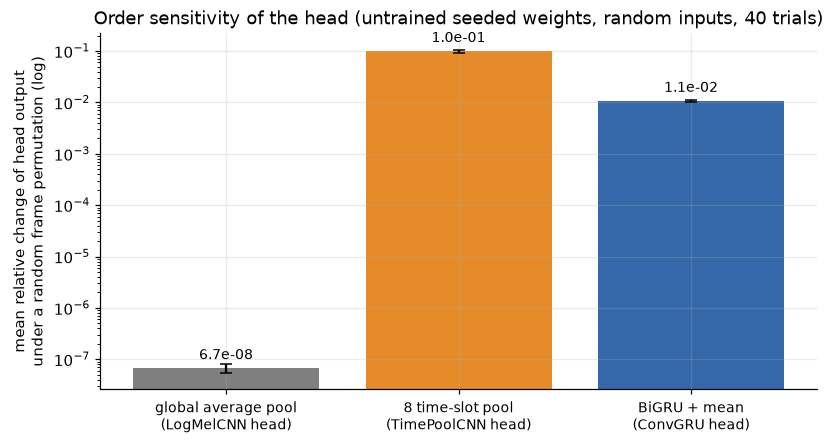

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig2_1_order_sensitivity.png')

In [7]:
# Figure 2.1: order sensitivity of the three heads (log scale so the pooled head's rounding-level value is visible).
fig, ax = plt.subplots(figsize=(8.4, 4.2))
labels = list(RC); means = [max(RC[k].mean(), 1e-9) for k in labels]; sds = [RC[k].std(ddof=1) for k in labels]
cols = [ACOL["baseline"], ACOL["timepool"], ACOL["gru"]]
ax.bar(range(3), means, yerr=[np.minimum(s, 0.9 * m) for s, m in zip(sds, means)], color=cols, capsize=4)
ax.set_yscale("log"); ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("mean relative change of head output\nunder a random frame permutation (log)")
for i, m in enumerate(means):
    ax.text(i, m * 1.5, f"{m:.1e}", ha="center", fontsize=9)
ax.set_title("Order sensitivity of the head (untrained seeded weights, random inputs, 40 trials)")
varied("N1.2.f1", means)
savefig(fig, "fig2_1_order_sensitivity.png")

### How to read this chart

Each bar is the average relative change $\lVert y-y_\pi\rVert/\lVert y\rVert$ of a head's output when the
*same* frames are fed in a random order $\pi$, on a log axis; whiskers are one standard deviation over 40
trials. The left bar (global average pooling) sits at floating-point rounding, about $10^{-8}$: not "small" but
exactly zero in exact arithmetic, as $g(FP)=g(F)$ predicts. The two right-hand bars are order-sensitive by many
orders of magnitude. The takeaway is structural: a head that averages over time before any state is formed
cannot see order, and a head that forms states first can. What would falsify the reading: a pooled bar far above
rounding error, or a recurrent bar at rounding error. Caution: this shows that order *can* influence the
output, not that the trained model *uses* it; that would need trained weights and is outside this notebook.

### 2.3 Paper result versus our result

The CRNN paper (Arik et al., arXiv:1703.05390; turns 1 to 3) reports a $229\text{k}$-parameter CRNN against a
re-optimised purely convolutional baseline capped at $250\text{k}$ parameters. At $5$ dB SNR the CNN baseline
has a false-reject rate of $4.31\%$ at 1 false alarm per hour and $5.73\%$ at $0.5$ per hour, against
$2.85\%$ and $3.79\%$ for the CRNN. The ratio is
$$\frac{\mathrm{FRR}_{\mathrm{CNN}}}{\mathrm{FRR}_{\mathrm{CRNN}}}=\frac{4.31}{2.85}=1.512,\qquad \frac{5.73}{3.79}=1.512,$$
i.e. the CNN's rate is about $51\%$ higher at both operating points. Two features make our comparison
different in kind. (i) The footprint classes are comparable, not equal: the paper's models bracket
$229\text{k}\to250\text{k}$ (ratio CRNN to CNN $=0.916$), ours are $291{,}564$ against $271{,}692$ (ratio
$=1.073$), so *our recurrent model is the larger one*, whereas the paper's is the smaller. (ii) The metrics
differ: FRR at a fixed false-alarm rate is a detection metric on a keyword-versus-background task, while ours
is 12-way accuracy. We therefore compare *error ratios*, $\rho=\mathrm{err}_{\text{conv}}/\mathrm{err}_{\text{rec}}$,
with error $=1-\text{accuracy}$, and treat the comparison as a shape check, not a replication.

Our margin is much smaller against the like-for-like convolutional arm. With $\mathrm{err}=1-\mathrm{acc}$,
$\rho_{\text{wide/gru}}=(1-0.8790)/(1-0.9008)=1.22$ at the best epoch, comparable in order of magnitude to
the paper's $1.51$ but resting on a difference of $0.0218$ that a $504$-clip validation split cannot separate
(its binomial standard error is about $0.013$ per arm). The other ratios, $\rho_{\text{timepool/gru}}$ and
$\rho_{\text{baseline/gru}}$, are far larger, because those arms *pool the time axis away*, which is the
mechanism of Section 2.1, not a footprint effect.

In [8]:
# N1.2.3: paper error ratios vs ours, computed from the quoted paper figures and the loaded artifacts.
paper = {"5dB@1FA/h": (4.31, 2.85), "5dB@0.5FA/h": (5.73, 3.79)}
rho_paper = {k: a / b for k, (a, b) in paper.items()}
print({k: round(v, 4) for k, v in rho_paper.items()}, "| relative excess of CNN FRR:", {k: f"{(a - b) / b:.1%}" for k, (a, b) in paper.items()})
check("N1.2.3a", all(abs((a - b) / b - 0.51) < 0.01 for a, b in paper.values()), "the paper's CNN FRR is ~51% higher at both operating points (turn 3 states 51%)")
check("N1.2.3b", abs(229 / 250 - 0.916) < 5e-4 and abs(291564 / 271692 - 1.0731) < 5e-4, f"footprint ratio: paper CRNN/CNN = {229/250:.3f}, ours gru/wide = {291564/271692:.3f} (our recurrent model is the larger one)")
gru = SUMM.loc["gru"]
err = lambda a: 1.0 - a
rho = {
    "wide/gru @best epoch": err(SUMM.loc["wide", "acc@best_epoch"]) / err(gru["acc@best_epoch"]),
    "wide/gru @last epoch": err(SUMM.loc["wide", "last_epoch_acc"]) / err(gru["last_epoch_acc"]),
    "timepool/gru @best epoch": err(SUMM.loc["timepool", "acc@best_epoch"]) / err(gru["acc@best_epoch"]),
    "baseline(seed 17)/gru @last": err(LEG[17].val_accuracy.iloc[-1]) / err(gru["last_epoch_acc"]),
}
for k, v in rho.items():
    print(f"error ratio {k:30s} = {v:6.3f}")
se = np.sqrt(0.9008 * (1 - 0.9008) / n_val)
z = (0.8790 - 0.9008) / np.sqrt(2) / se
print(f"validation-split binomial SE at acc 0.90, n={n_val}: {se:.4f}; unpaired z for the 0.0218 gap = {z:.2f}")
check("N1.2.3c", abs(rho["wide/gru @best epoch"] - 1.22) < 0.01, f"wide/gru error ratio at best epoch = {rho['wide/gru @best epoch']:.3f} (text: 1.22)")
check("N1.2.3d", abs(z) < 2.0, f"|z| = {abs(z):.2f} < 2: the 0.9008 vs 0.8790 best-epoch gap is not resolvable on {n_val} validation clips alone")
check("N1.2.3e", rho["timepool/gru @best epoch"] > rho["wide/gru @best epoch"] and rho["baseline(seed 17)/gru @last"] > rho["timepool/gru @best epoch"],
      "ordering of error ratios matches 'how much time information the arm keeps': wide < timepool < baseline")

{'5dB@1FA/h': 1.5123, '5dB@0.5FA/h': 1.5119} | relative excess of CNN FRR: {'5dB@1FA/h': '51.2%', '5dB@0.5FA/h': '51.2%'}
[N1.2.3a] the paper's CNN FRR is ~51% higher at both operating points (turn 3 states 51%) -> PASS
[N1.2.3b] footprint ratio: paper CRNN/CNN = 0.916, ours gru/wide = 1.073 (our recurrent model is the larger one) -> PASS
error ratio wide/gru @best epoch           =  1.220
error ratio wide/gru @last epoch           =  2.480
error ratio timepool/gru @best epoch       =  4.480
error ratio baseline(seed 17)/gru @last    =  6.320
validation-split binomial SE at acc 0.90, n=504: 0.0133; unpaired z for the 0.0218 gap = -1.16
[N1.2.3c] wide/gru error ratio at best epoch = 1.220 (text: 1.22) -> PASS
[N1.2.3d] |z| = 1.16 < 2: the 0.9008 vs 0.8790 best-epoch gap is not resolvable on 504 validation clips alone -> PASS
[N1.2.3e] ordering of error ratios matches 'how much time information the arm keeps': wide < timepool < baseline -> PASS


True

[N1.2.f2] plotted values finite and not all identical (range 6.116) -> PASS


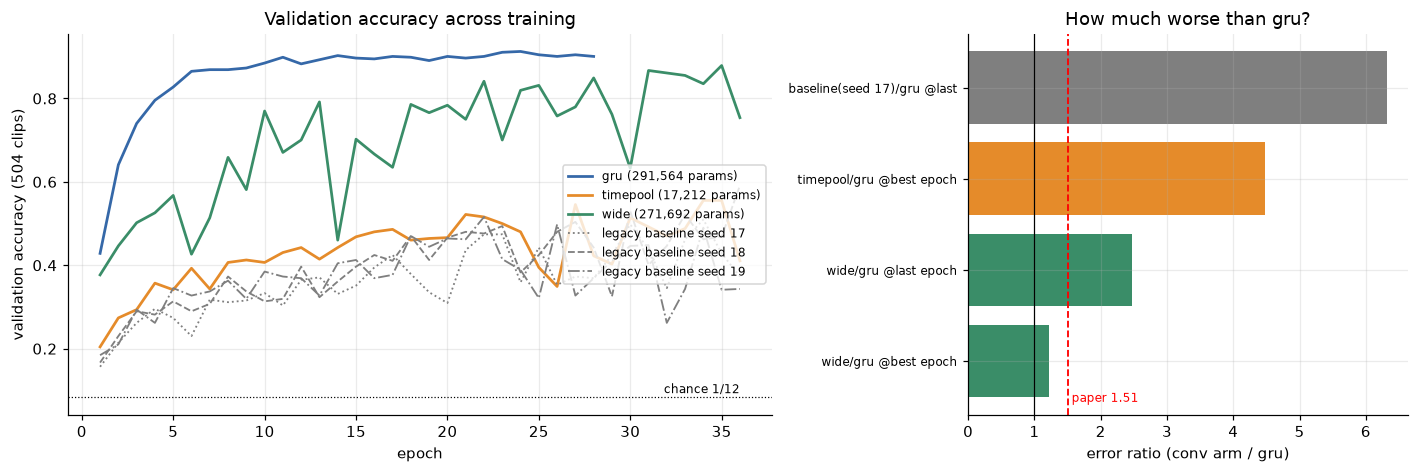

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig2_2_val_curves_and_error_ratios.png')

In [9]:
# Figure 2.2: validation accuracy per epoch for the three instrumented arms and the three legacy baseline seeds.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.6, 1]})
for a in ARCHS:
    h = DATA[a]["res"]["history"]
    ax[0].plot([e["epoch"] + 1 for e in h], [e["val_accuracy"] for e in h], color=ACOL[a], lw=1.8, label=f"{a} ({DATA[a]['res']['parameters']:,} params)")
for s, ls in zip((17, 18, 19), (":", "--", "-.")):
    ax[0].plot(LEG[s].epoch, LEG[s].val_accuracy, color=ACOL["baseline"], ls=ls, lw=1.2, label=f"legacy baseline seed {s}")
ax[0].axhline(1 / 12, color="k", lw=0.8, ls=":"); ax[0].text(36, 1 / 12 + 0.01, "chance 1/12", ha="right", fontsize=8)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("validation accuracy (504 clips)"); ax[0].legend(fontsize=8, loc="center right"); ax[0].set_title("Validation accuracy across training")
rho_lab = list(rho); rho_val = [rho[k] for k in rho_lab]
ax[1].barh(range(len(rho_lab)), rho_val, color=[ACOL["wide"], ACOL["wide"], ACOL["timepool"], ACOL["baseline"]])
ax[1].axvline(rho_paper["5dB@1FA/h"], color="r", ls="--", lw=1.2); ax[1].text(rho_paper["5dB@1FA/h"] + 0.05, -0.45, "paper 1.51", color="r", fontsize=8)
ax[1].axvline(1, color="k", lw=0.8)
ax[1].set_yticks(range(len(rho_lab))); ax[1].set_yticklabels(rho_lab, fontsize=8); ax[1].set_xlabel("error ratio (conv arm / gru)"); ax[1].set_title("How much worse than gru?")
varied("N1.2.f2", rho_val, [e["val_accuracy"] for a in ARCHS for e in DATA[a]["res"]["history"]])
plt.tight_layout(); savefig(fig, "fig2_2_val_curves_and_error_ratios.png")

### How to read this chart

Left: validation accuracy by epoch, coloured by architecture; the three grey lines are the legacy
globally-pooled baseline at seeds 17, 18, 19, and the dotted horizontal line is chance, $1/12=0.083$. `gru`
(blue) climbs to about $0.90$ and stays inside a narrow band; `wide` (green) reaches similar heights but
swings between roughly $0.63$ and $0.88$ in the last ten epochs; `timepool` (orange) never leaves the range
$0.40$ to $0.56$; the grey baseline seeds finish at $0.373$, $0.591$, $0.343$, a spread of $0.25$ *within one
architecture*. Right: the error ratio $\rho$ of each convolutional arm relative to `gru`, with the paper's
$1.51$ as the red dashed line and $1$ (no difference) as the black line. The `wide/gru` bar is at or above $1$ at
both summaries but its size depends on the epoch you read off, because of the oscillation on the left.

What the picture supports: the ordering "arms that keep the time axis beat arms that pool it" is large and
stable. What it does not support: any claim that the recurrent head beats a *time-preserving* wide CNN by the
paper's margin, since that gap is comparable to the epoch-to-epoch swing of `wide` and to the seed spread of
the baseline. The paper's margin is between a CRNN and a CNN that *also* preserves time inside its filters;
our biggest gaps come from removing the time axis altogether.

## 3. Where our data contradicts the attribution

### 3.1 What the paper says, stated so that it can be tested

The CRNN paper (Arik et al., arXiv:1703.05390; turns 2 and 3) makes two separable statements.

1. **A mechanism.** The advantage is attributed to complementary strengths: convolutions capture local
   time-and-frequency structure, the bidirectional recurrent layers capture long-range temporal context,
   and, in the paper's words as returned by the trace, *recurrent layers adapt better to individual noise
   signatures*.
2. **A dose-response.** The CRNN's advantage **narrows as SNR increases**: at $5$ dB the CNN's false-reject
   rate is about $51\%$ higher, and the CRNN's test accuracy at $0.5$ false alarms per hour rises from
   $97.71\%$ at $5$ dB to $98.71\%$ at $10$ dB and $99.30\%$ at $20$ dB, i.e. cleaner audio leaves less room
   for either model to differ.

Write $\Delta(s)=\mathrm{acc}_{\text{rec}}(s)-\mathrm{acc}_{\text{conv}}(s)$ for the recurrent model's accuracy
advantage in condition $s$. The two statements together predict
$$\Delta(\text{clean})\ \ge 0,\qquad \Delta(\text{noise})\ >\ \Delta(\text{clean}),\qquad \Delta(s)\ \text{decreasing in SNR}.$$
Our data can test the first two, but only coarsely: the exploration configuration has four conditions
(`clean`, `gain_+10`, `reverb_mid`, `noise_10`), of which only `noise_10` is an additive-noise condition and
there is exactly one SNR level. The third prediction (a dose-response curve) cannot be tested at all.

### 3.2 What we measured

Our architecture race was **clean-only**: every arm trained on clean audio and the stress conditions are
applied at test time only. In that regime the paper's second statement predicts a small `gru`-versus-`wide`
margin, and that is what we see (about $0.02$ in accuracy on the clean test split). So far the two agree.
The `noise_10` condition is where the mechanism should show, and it is where the data disagree: `gru` scores
$0.1380$, the *lowest* of the three arms, and `wide` scores $0.2519$, the *highest*. That is the reverse of
"recurrent layers adapt better to noise". The next cell loads the numbers for all four conditions with the
bootstrap intervals recorded in the result files.

In [10]:
# N1.3.1: accuracy by arm x condition (uncalibrated, test split n=1080) with the recorded bootstrap CIs.
CONDS = ["clean", "gain_+10", "reverb_mid", "noise_10"]
def S(a, c, kind="uncalibrated"):
    return DATA[a]["res"]["summary"]["conditions"][c][kind]
N_TEST = DATA["gru"]["res"]["summary"]["n_test"]
ACC = pd.DataFrame({a: {c: S(a, c)["accuracy"] for c in CONDS} for a in ARCHS})
LO = pd.DataFrame({a: {c: S(a, c)["ci"]["accuracy"]["lower"] for c in CONDS} for a in ARCHS})
HI = pd.DataFrame({a: {c: S(a, c)["ci"]["accuracy"]["upper"] for c in CONDS} for a in ARCHS})
display(ACC.round(4))
check("N1.3.1a", all(DATA[a]["res"]["summary"]["n_test"] == 1080 for a in ARCHS) and sorted(DATA["gru"]["res"]["summary"]["conditions"]) == sorted(CONDS),
      f"every arm evaluated on n_test={N_TEST} with the same four conditions {CONDS}")
check("N1.3.1b", [round(ACC.loc["noise_10", a], 4) for a in ("gru", "timepool", "wide")] == [0.1380, 0.1472, 0.2519],
      "noise_10 accuracy: gru 0.1380, timepool 0.1472, wide 0.2519")
check("N1.3.1c", ACC.loc["noise_10"].idxmin() == "gru" and ACC.loc["noise_10"].idxmax() == "wide", "under noise_10 gru is the worst arm and wide the best")
check("N1.3.1d", all(LO.loc[c, a] <= ACC.loc[c, a] <= HI.loc[c, a] for a in ARCHS for c in CONDS), "every point estimate lies inside its recorded bootstrap interval")
CHANCE = 1 / 12
_mult = ", ".join("%s %.2fx" % (a, ACC.loc["noise_10", a] / CHANCE) for a in ARCHS)
note("N1.3.1e", f"chance is 1/12 = {CHANCE:.4f}; noise_10 accuracies are {_mult} chance: all three arms are near the floor")
LN12 = np.log(12)
nll10 = {a: S(a, "noise_10")["nll"] for a in ARCHS}
print("noise_10 NLL (uncalibrated):", {a: round(v, 3) for a, v in nll10.items()}, "| uniform predictor NLL = ln 12 =", round(LN12, 4))
check("N1.3.1f", all(v > LN12 for v in nll10.values()), "under noise_10 every arm has NLL above ln 12: worse than answering with the uniform distribution")

               gru  timepool    wide
clean       0.8787    0.5491  0.8565
gain_+10    0.8287    0.4852  0.8315
reverb_mid  0.8176    0.4111  0.7611
noise_10    0.1380    0.1472  0.2519

[N1.3.1a] every arm evaluated on n_test=1080 with the same four conditions ['clean', 'gain_+10', 'reverb_mid', 'noise_10'] -> PASS
[N1.3.1b] noise_10 accuracy: gru 0.1380, timepool 0.1472, wide 0.2519 -> PASS
[N1.3.1c] under noise_10 gru is the worst arm and wide the best -> PASS
[N1.3.1d] every point estimate lies inside its recorded bootstrap interval -> PASS
[N1.3.1e] chance is 1/12 = 0.0833; noise_10 accuracies are gru 1.66x, timepool 1.77x, wide 3.02x chance: all three arms are near the floor -> NOTE
noise_10 NLL (uncalibrated): {'gru': 4.467, 'timepool': 4.079, 'wide': 4.071} | uniform predictor NLL = ln 12 = 2.4849
[N1.3.1f] under noise_10 every arm has NLL above ln 12: worse than answering with the uniform distribution -> PASS


True

### 3.3 How big is the contradiction, and of what kind?

Two different sources of uncertainty must not be confused. The first is **test-set sampling**: with $n=1080$
test clips and accuracy $\hat p$, the binomial standard error is $\sqrt{\hat p(1-\hat p)/n}$, and the
difference of two independent arms has variance $\sigma_\Delta^2=\sigma_1^2+\sigma_2^2$. The second is
**training-run variance** (seed, data order, initialisation), which a single trained model per arm cannot
estimate at all. The first is small and computable; the second is unknown and, for this project, potentially
large: the legacy baseline's three seeds ended at $0.3730$, $0.5913$ and $0.3433$ within one architecture.

The cell below computes $\Delta=\mathrm{acc}_{\text{gru}}-\mathrm{acc}_{\text{wide}}$ per condition with the
first kind of uncertainty only, and tests the paper's directional prediction against it. The comparison is
unpaired because per-clip predictions are not stored, so the standard error is conservative in exactly the
way that pairing would reduce it; that does not change the qualitative reading.

In [11]:
# N1.3.2: Delta(condition) = acc_gru - acc_wide with test-sampling SE only (unpaired binomial).
def se_bin(p, n=N_TEST):
    return np.sqrt(p * (1 - p) / n)
rows = []
for c in CONDS:
    pg, pw = ACC.loc[c, "gru"], ACC.loc[c, "wide"]
    d = pg - pw; se = np.hypot(se_bin(pg), se_bin(pw))
    rows.append({"condition": c, "acc_gru": pg, "acc_wide": pw, "Delta": d, "SE(test sampling)": se, "z": d / se,
                 "95% lo": d - 1.96 * se, "95% hi": d + 1.96 * se})
DELTA = pd.DataFrame(rows).set_index("condition")
display(DELTA.round(4))
d_clean, d_noise = DELTA.loc["clean", "Delta"], DELTA.loc["noise_10", "Delta"]
check("N1.3.2a", abs(d_clean - 0.0222) < 5e-4, f"Delta(clean) = {d_clean:+.4f}: gru slightly ahead on the clean test split")
check("N1.3.2b", DELTA.loc["clean", "95% lo"] < 0.0 < DELTA.loc["clean", "95% hi"] or DELTA.loc["clean", "z"] > 1.96,
      f"Delta(clean) z = {DELTA.loc['clean', 'z']:+.2f}: small margin, consistent with the paper's 'gap narrows in clean audio' (not a strong test)")
check("N1.3.2c", DELTA.loc["noise_10", "z"] < -1.96, f"Delta(noise_10) = {d_noise:+.4f}, z = {DELTA.loc['noise_10', 'z']:+.2f}: wide is ahead by more than test-set sampling can produce")
note("N1.3.2d", f"paper predicts Delta(noise) > Delta(clean); measured Delta(noise) - Delta(clean) = {d_noise - d_clean:+.4f}: the predicted direction is reversed")
note("N1.3.2e", "test-set sampling is the ONLY uncertainty in the SEs above; seed-to-seed training variance is unmeasured (one run per arm)")

            acc_gru  acc_wide   Delta  SE(test sampling)       z  95% lo  95% hi
condition                                                                       
clean        0.8787    0.8565  0.0222             0.0146  1.5244 -0.0063  0.0508
gain_+10     0.8287    0.8315 -0.0028             0.0162 -0.1719 -0.0345  0.0289
reverb_mid   0.8176    0.7611  0.0565             0.0175  3.2265  0.0222  0.0908
noise_10     0.1380    0.2519 -0.1139             0.0169 -6.7511 -0.1470 -0.0808

[N1.3.2a] Delta(clean) = +0.0222: gru slightly ahead on the clean test split -> PASS
[N1.3.2b] Delta(clean) z = +1.52: small margin, consistent with the paper's 'gap narrows in clean audio' (not a strong test) -> PASS
[N1.3.2c] Delta(noise_10) = -0.1139, z = -6.75: wide is ahead by more than test-set sampling can produce -> PASS
[N1.3.2d] paper predicts Delta(noise) > Delta(clean); measured Delta(noise) - Delta(clean) = -0.1361: the predicted direction is reversed -> NOTE
[N1.3.2e] test-set sampling is the ONLY uncertainty in the SEs above; seed-to-seed training variance is unmeasured (one run per arm) -> NOTE


[N1.3.f1] plotted values finite and not all identical (range 0.7407) -> PASS


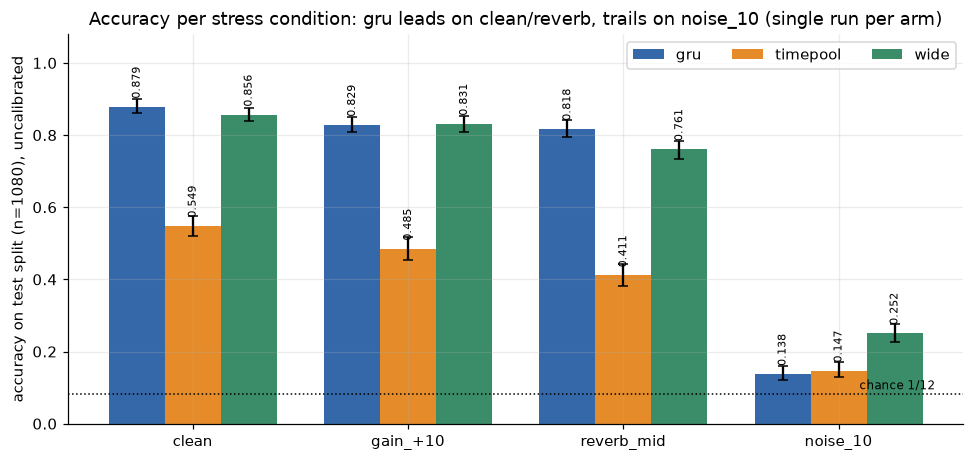

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig3_1_accuracy_by_condition.png')

In [12]:
# Figure 3.1: accuracy by condition and arm with recorded bootstrap CIs; chance line.
fig, ax = plt.subplots(figsize=(10.5, 4.6))
w = 0.26
for k, a in enumerate(ARCHS):
    xs = np.arange(len(CONDS)) + (k - 1) * w
    yv = ACC[a].values; lo = yv - LO[a].values; hi = HI[a].values - yv
    ax.bar(xs, yv, width=w, color=ACOL[a], label=a, yerr=[lo, hi], capsize=3)
    for x_, v_ in zip(xs, yv):
        ax.text(x_, v_ + 0.03, f"{v_:.3f}", ha="center", fontsize=7.5, rotation=90)
ax.axhline(CHANCE, color="k", ls=":", lw=1); ax.text(3.45, CHANCE + 0.012, "chance 1/12", ha="right", fontsize=8)
ax.set_xticks(range(len(CONDS))); ax.set_xticklabels(CONDS); ax.set_ylabel("accuracy on test split (n=1080), uncalibrated")
ax.set_ylim(0, 1.08); ax.legend(ncol=3, loc="upper right")
ax.set_title("Accuracy per stress condition: gru leads on clean/reverb, trails on noise_10 (single run per arm)")
varied("N1.3.f1", ACC.values)
savefig(fig, "fig3_1_accuracy_by_condition.png")

### How to read this chart

Each group of three bars is one test condition; bar height is test accuracy, whiskers are the bootstrap
interval recorded in the result files (exploration configuration: $200$ resamples, so the whiskers are
coarse), the dotted line is chance at $1/12$. Read across a group to compare architectures under the *same*
condition. On `clean` and `reverb_mid` the blue `gru` bar is at or above the green `wide` bar; on `gain_+10`
they are level; on `noise_10` the ordering flips, and all three bars collapse to a height that is only
$1.7$ to $3.0$ times chance. The point of the chart is the **flip**, not the absolute heights: a mechanism
of the form "recurrent layers adapt to noise" predicts that the blue bar rises relative to the green bar
when moving from `clean` to `noise_10`, and it falls. What would make this reading wrong: intervals that
overlap heavily in the `noise_10` group (they do not; the whiskers for `gru` and `wide` there are separated by
several bootstrap half-widths) or a second seed that reversed the order (unknown).

[N1.3.f2] plotted values finite and not all identical (range 0.1704) -> PASS


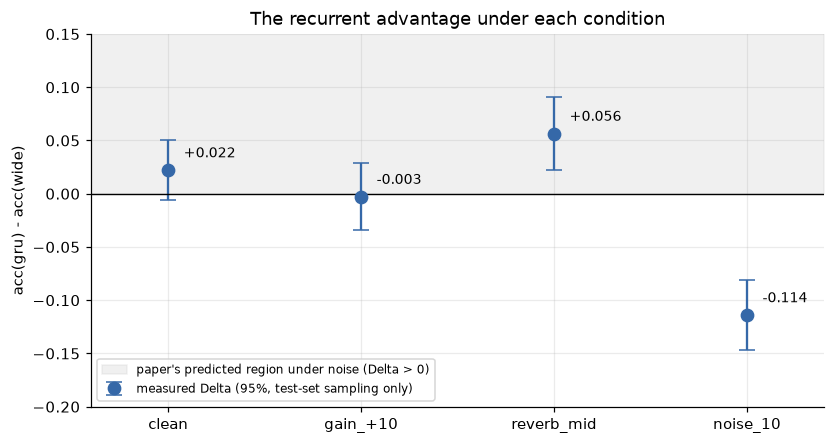

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig3_2_gru_minus_wide.png')

In [13]:
# Figure 3.2: Delta = acc_gru - acc_wide per condition, with test-sampling-only 95% intervals, against the paper's predicted sign.
fig, ax = plt.subplots(figsize=(8.6, 4.4))
xs = np.arange(len(CONDS))
ax.errorbar(xs, DELTA["Delta"], yerr=1.96 * DELTA["SE(test sampling)"], fmt="o", color=ACOL["gru"], capsize=5, ms=8, label="measured Delta (95%, test-set sampling only)")
ax.axhline(0, color="k", lw=0.9)
ax.fill_between([-0.4, 3.4], 0, 0.3, color=PALETTE["band"], alpha=0.25, label="paper's predicted region under noise (Delta > 0)")
for x_, v_ in zip(xs, DELTA["Delta"]):
    ax.text(x_ + 0.08, v_ + 0.012, f"{v_:+.3f}", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(CONDS); ax.set_xlim(-0.4, 3.4); ax.set_ylim(-0.2, 0.15)
ax.set_ylabel("acc(gru) - acc(wide)"); ax.legend(loc="lower left", fontsize=8)
ax.set_title("The recurrent advantage under each condition")
varied("N1.3.f2", DELTA["Delta"].values)
savefig(fig, "fig3_2_gru_minus_wide.png")

### How to read this chart

Each dot is $\Delta=\mathrm{acc}_{\text{gru}}-\mathrm{acc}_{\text{wide}}$ for one condition; the vertical bar is
a $95\%$ interval that includes **only** test-set sampling noise, so it is a floor on the true uncertainty, not
a full interval. The shaded band is where the paper's mechanism would put the `noise_10` point (positive, and
larger than on `clean`). The `clean` dot is slightly positive with an interval that reaches zero; the `noise_10`
dot sits far below zero, outside the band, by roughly seven of its own standard errors. If the dot were a
random fluctuation of the test set alone it would not be there; that leaves training-run variance (unknown),
a genuine architectural effect, or an interaction with the specific perturbation as candidate explanations,
and this notebook cannot separate them.

### 3.4 What this does and does not establish

**What is established.** In this run, with these weights, `gru` is not more robust to `noise_10` than the
time-preserving `wide` CNN; it is less robust, by more than test-set sampling explains, and its probabilities
are the worst-behaved (NLL $4.467$ against $4.071$ for `wide`, with ECE at $0.747$: confidently wrong).

**What is not established.** Whether this is a property of the architectures or of this training run. One
seed cannot settle it, and the exploration configuration has exactly one additive-noise condition. The paper's
statement is about noise signatures the model was *exposed to*, and the grounding does not say whether the
paper's noisy conditions were seen at training time; ours were not. So we report a tension, not a refutation.

**An untested hypothesis, labelled as such.** A bidirectional GRU integrates the whole clip, so a stationary
broadband noise floor shifts *every* input to the recurrence and the perturbation can accumulate in the
state, whereas a convolutional trunk with a short receptive field (about $12$ frames in the baseline, Section
2) treats each patch locally and then pools coarsely. Nothing in this notebook tests that. It is recorded so
that a future experiment (noise-augmented training of both arms across several seeds) has a concrete
statement to confirm or reject.

In [14]:
# N1.3.3: how many training seeds would it take to see a difference this size? Illustrative sigma values, clearly labelled.
# Minimum detectable difference for a two-sided 5% test at 80% power, k seeds per arm: MDE(k) = (z_{0.975} + z_{0.8}) * sigma * sqrt(2/k).
zsum = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
leg_final = np.array([LEG[s].val_accuracy.iloc[-1] for s in (17, 18, 19)])
SIGMAS = {"legacy baseline, 3 seeds (different architecture)": leg_final.std(ddof=1),
          "wide, last-10-epoch sd (epoch noise, not seed noise)": SUMM.loc["wide", "sd(last 10 epochs)"],
          "gru, last-10-epoch sd (epoch noise, not seed noise)": SUMM.loc["gru", "sd(last 10 epochs)"]}
ks = np.array([1, 2, 3, 5, 10, 20, 40])
MDE = pd.DataFrame({name: zsum * s * np.sqrt(2 / ks) for name, s in SIGMAS.items()}, index=pd.Index(ks, name="seeds per arm"))
display(MDE.round(3))
target = abs(d_noise)
need = {name: int(np.ceil(2 * (zsum * s / target) ** 2)) for name, s in SIGMAS.items()}
for name, k in need.items():
    print(f"seeds per arm needed to detect |Delta(noise_10)| = {target:.3f} if sigma = {SIGMAS[name]:.3f} ({name}): {k}")
check("N1.3.3a", abs(SIGMAS["legacy baseline, 3 seeds (different architecture)"] - np.std([0.3730, 0.5913, 0.3433], ddof=1)) < 1e-3, f"legacy seed sd = {leg_final.std(ddof=1):.4f}")
check("N1.3.3b", bool(np.all(np.diff(MDE.values, axis=0) < 0)), "MDE shrinks monotonically with seeds per arm (as 1/sqrt(k))")
check("N1.3.3c", all(k >= 1 for k in need.values()) and max(need.values()) > min(need.values()), f"seeds needed depend strongly on the unknown sigma: {min(need.values())} to {max(need.values())}")
note("N1.3.3d", "these sigmas are proxies from other quantities; NONE is an estimate of gru or wide seed-to-seed sd, which requires re-training")

               legacy baseline, 3 seeds (different architecture)  wide, last-10-epoch sd (epoch noise, not seed noise)  gru, last-10-epoch sd (epoch noise, not seed noise)
seeds per arm                                                                                                                                                              
1                                                          0.537                                                 0.303                                                0.025
2                                                          0.379                                                 0.214                                                0.018
3                                                          0.310                                                 0.175                                                0.014
5                                                          0.240                                                 0.135                      

seeds per arm needed to detect |Delta(noise_10)| = 0.114 if sigma = 0.135 (legacy baseline, 3 seeds (different architecture)): 23
seeds per arm needed to detect |Delta(noise_10)| = 0.114 if sigma = 0.076 (wide, last-10-epoch sd (epoch noise, not seed noise)): 8
seeds per arm needed to detect |Delta(noise_10)| = 0.114 if sigma = 0.006 (gru, last-10-epoch sd (epoch noise, not seed noise)): 1
[N1.3.3a] legacy seed sd = 0.1354 -> PASS
[N1.3.3b] MDE shrinks monotonically with seeds per arm (as 1/sqrt(k)) -> PASS
[N1.3.3c] seeds needed depend strongly on the unknown sigma: 1 to 23 -> PASS
[N1.3.3d] these sigmas are proxies from other quantities; NONE is an estimate of gru or wide seed-to-seed sd, which requires re-training -> NOTE


[N1.3.f3] plotted values finite and not all identical (range 0.5326) -> PASS


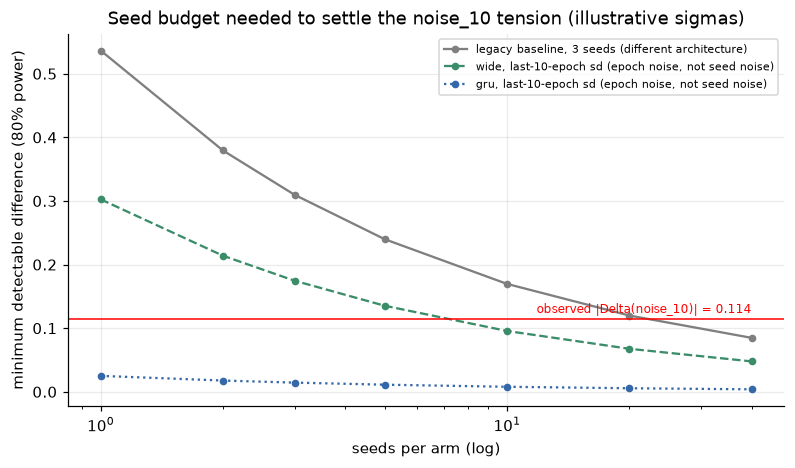

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig3_3_seed_budget.png')

In [15]:
# Figure 3.3: minimum detectable accuracy difference versus seeds per arm, for three illustrative sigma values.
fig, ax = plt.subplots(figsize=(8.4, 4.4))
for (name, col), ls in zip(zip(MDE.columns, ["#7f7f7f", ACOL["wide"], ACOL["gru"]]), ["-", "--", ":"]):
    ax.plot(MDE.index, MDE[name], color=col, ls=ls, marker="o", ms=4, label=name)
ax.axhline(target, color="r", lw=1); ax.text(40, target + 0.01, f"observed |Delta(noise_10)| = {target:.3f}", ha="right", color="r", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("seeds per arm (log)"); ax.set_ylabel("minimum detectable difference (80% power)")
ax.legend(fontsize=7.5); ax.set_title("Seed budget needed to settle the noise_10 tension (illustrative sigmas)")
varied("N1.3.f3", MDE.values)
savefig(fig, "fig3_3_seed_budget.png")

### How to read this chart

Each curve is the smallest true accuracy difference that a two-sided $5\%$ test would detect with $80\%$
power, $\mathrm{MDE}(k)=(z_{0.975}+z_{0.80})\,\sigma\sqrt{2/k}$, as a function of the number $k$ of independent
training runs per arm. The red line is the observed $|\Delta(\text{noise\_10})|$. A curve below the red line
means $k$ seeds are enough to resolve a difference that large. The three curves use three **different,
unverified** values of the seed-to-seed standard deviation $\sigma$, because none has been measured for
`gru` or `wide`: the grey curve borrows the spread of the legacy baseline's three seeds, the green and blue
ones borrow epoch-to-epoch noise. The lesson is the spread between curves: depending on $\sigma$, the number
of seeds required ranges from one to more than twenty, so the honest statement is "we do not know how many
seeds it takes", not "three is enough".

## 4. Neural collapse: what the formulas say, what they require, and what our probes can and cannot show

### 4.1 Order of business: preconditions before parallels

Neural collapse (NC) is a phenomenon of the *terminal phase of training* (TPT), and its metrics are defined
on *training-set* activations. Both facts constrain what we may say about our own numbers, and both are
stated here, **before** any figure or measurement is discussed, so that no later sentence can lean on a
parallel the definitions do not license. Sections 4.2 and 4.3 give the mathematics; Section 4.4 states the
precondition and the two measurement deviations; only then does Section 4.5 look at our data.

### 4.2 NC1: within-class variability collapse

(Papyan, Han and Donoho, arXiv:2008.08186; turn 4.) Let there be $C$ classes and $N$ examples per class, and
let $h_{i,c}\in\mathbb{R}^p$ be the last-layer feature of example $i$ in class $c$. Define
$$\mu_G=\mathrm{Ave}_{i,c}\{h_{i,c}\},\qquad \mu_c=\mathrm{Ave}_i\{h_{i,c}\},$$
$$\Sigma_W=\mathrm{Ave}_{i,c}\big\{(h_{i,c}-\mu_c)(h_{i,c}-\mu_c)^\top\big\},\qquad
\Sigma_B=\mathrm{Ave}_c\big\{(\mu_c-\mu_G)(\mu_c-\mu_G)^\top\big\},$$
and the variability-collapse metric
$$\mathrm{NC}_1=\frac{1}{C}\,\mathrm{Tr}\!\big(\Sigma_W\,\Sigma_B^{\dagger}\big),$$
where $\dagger$ is the Moore-Penrose pseudo-inverse. Collapse means $\Sigma_W\to\mathbf 0$, hence
$\mathrm{NC}_1\to0$. Three properties follow directly and are worth having in hand because they decide how
the metric may be used. **(i) Scale invariance**: replacing $h\mapsto a h$ multiplies both $\Sigma_W$ and
$\Sigma_B$ by $a^2$, and $\Sigma_B^\dagger$ by $a^{-2}$, so $\mathrm{NC}_1$ is unchanged. A raw
within-class variance is *not* scale-free, so a large $\mathrm{Tr}\,\Sigma_W$ says nothing about collapse
unless it is compared with the between-class scale. **(ii) Rotation invariance**: $h\mapsto Qh$ with $Q$
orthogonal leaves it unchanged. **(iii) Quadratic scaling in the noise**: if $h=m+s\,\varepsilon$ with class
means $m$ fixed and within-class noise scaled by $s$, then $\Sigma_W\propto s^2$ and
$\mathrm{NC}_1\propto s^2$, so $\log\mathrm{NC}_1$ against $\log s$ has slope $2$.

### 4.3 NC2: the simplex equiangular tight frame

(Turn 6.) The standard simplex ETF is the set of columns of
$$M^{*}=\sqrt{\tfrac{C}{C-1}}\Big(I-\tfrac{1}{C}\mathbf 1_C\mathbf 1_C^{\top}\Big),$$
and a general simplex ETF is $M=\alpha\,U\,M^{*}$ with $\alpha>0$ and $U^\top U=I$. Its columns have equal norm
and pairwise cosine exactly $-1/(C-1)$, the largest mutual angle that $C$ centred vectors can have. The paper
splits NC2 into two measurements on the centred class means $\mu_c-\mu_G$, with
$\cos_\mu(c,c')=\langle\mu_c-\mu_G,\mu_{c'}-\mu_G\rangle/(\lVert\mu_c-\mu_G\rVert\,\lVert\mu_{c'}-\mu_G\rVert)$:
$$\text{equinormness}=\frac{\mathrm{Std}_c\,\lVert\mu_c-\mu_G\rVert_2}{\mathrm{Avg}_c\,\lVert\mu_c-\mu_G\rVert_2},\qquad
\text{equiangularity}=\mathrm{Std}_{c\ne c'}\,\cos_\mu(c,c'),$$
and a third, maximal-angle measure, $\mathrm{Avg}_{c\ne c'}\,\big|\cos_\mu(c,c')+\tfrac{1}{C-1}\big|$. All three tend
to $0$ in TPT. One geometric fact matters for us: an ETF of $C=12$ classes spans $C-1=11$ dimensions. **In a
two-dimensional projection, 12 centred vectors cannot be equiangular at $-1/11$**, so the 2D versions of the
equiangularity and maximal-angle measures have a floor above zero that no amount of training can lower. The
fixture cell below computes that floor for the best-spread planar configuration (a regular 12-gon).

In [16]:
# N1.4.1: NC formulas as code, verified on labelled FIXTURES (a simplex ETF and noise-scaled copies). Not evidence about speech.
def nc_stats(h, y):
    # NC1, equinormness, equiangularity and maximal-angle measure for features h (n, p) with integer labels y.
    h = np.asarray(h, dtype=float); classes = np.unique(y); C = len(classes)
    mu_G = h.mean(0); mus = np.stack([h[y == c].mean(0) for c in classes])
    Sw = sum((h[y == c] - mus[i]).T @ (h[y == c] - mus[i]) for i, c in enumerate(classes)) / len(h)   # Ave over all i,c
    M = mus - mu_G; Sb = M.T @ M / C
    nc1 = float(np.trace(Sw @ np.linalg.pinv(Sb)) / C)
    norms = np.linalg.norm(M, axis=1); U = M / norms[:, None]
    cs = (U @ U.T)[np.triu_indices(C, 1)]
    return {"nc1": nc1, "equinorm": float(norms.std() / norms.mean()), "equiang": float(cs.std()),
            "maxangle": float(np.abs(cs + 1 / (C - 1)).mean()), "trSw": float(np.trace(Sw)), "trSb": float(np.trace(Sb))}

Ccl, Nper = 12, 10
Mstar = np.sqrt(Ccl / (Ccl - 1)) * (np.eye(Ccl) - np.ones((Ccl, Ccl)) / Ccl)     # columns = simplex ETF
gram = Mstar.T @ Mstar
check("N1.4.1a", np.allclose(np.linalg.norm(Mstar, axis=0), 1.0), "columns of M* have unit norm")
off = gram[~np.eye(Ccl, dtype=bool)]
check("N1.4.1b", np.allclose(off, -1 / (Ccl - 1)), f"pairwise cosine of M* columns = -1/(C-1) = {-1 / (Ccl - 1):.4f} exactly")
check("N1.4.1c", np.allclose(gram, Ccl / (Ccl - 1) * (np.eye(Ccl) - np.ones((Ccl, Ccl)) / Ccl)), "M*^T M* = C/(C-1) (I - 11^T/C): a tight frame")
check("N1.4.1d", np.linalg.matrix_rank(Mstar) == Ccl - 1, f"rank(M*) = {np.linalg.matrix_rank(Mstar)} = C-1: the simplex ETF spans 11 dimensions, not 2")

rngf = np.random.default_rng(RNG_SEED + 41)
y_fx = np.repeat(np.arange(Ccl), Nper)
eps = rngf.standard_normal((Ccl * Nper, Ccl))
for _c in range(Ccl):
    eps[y_fx == _c] -= eps[y_fx == _c].mean(0)      # zero class means: only Sigma_W scales with s
base = 3.0 * Mstar.T[y_fx]                                   # alpha = 3, U = I
s_grid = np.array([1.0, 0.5, 0.25, 0.125, 0.0625])
nc1_s = np.array([nc_stats(base + s * eps, y_fx)["nc1"] for s in s_grid])
slope = np.polyfit(np.log(s_grid), np.log(nc1_s), 1)[0]
check("N1.4.1e", abs(slope - 2.0) < 0.05, f"fixture: log NC1 vs log(noise scale) has slope {slope:.3f} (theory 2)")
z0 = nc_stats(base, y_fx)
check("N1.4.1f", z0["nc1"] < 1e-12 and z0["equinorm"] < 1e-12 and z0["equiang"] < 1e-12 and z0["maxangle"] < 1e-12,
      "fixture at zero within-class noise: NC1, equinormness, equiangularity and maximal-angle measure are all 0")
h_noisy = base + 0.5 * eps
Q, _ = np.linalg.qr(rngf.standard_normal((Ccl, Ccl)))
a0, a1, a2 = nc_stats(h_noisy, y_fx)["nc1"], nc_stats(7.3 * h_noisy, y_fx)["nc1"], nc_stats(h_noisy @ Q, y_fx)["nc1"]
check("N1.4.1g", abs(a1 / a0 - 1) < 1e-8 and abs(a2 / a0 - 1) < 1e-8, f"NC1 is scale-invariant and rotation-invariant (ratios {a1 / a0:.10f}, {a2 / a0:.10f})")
tr_ratio = nc_stats(7.3 * h_noisy, y_fx)["trSw"] / nc_stats(h_noisy, y_fx)["trSw"]
check("N1.4.1h", abs(tr_ratio - 7.3 ** 2) < 1e-6, f"whereas Tr(Sigma_W) is NOT scale-free: it grows by {tr_ratio:.2f} = 7.3^2 under a pure rescaling")

ang = np.arange(Ccl) * 2 * np.pi / Ccl
U2 = np.c_[np.cos(ang), np.sin(ang)]; cs2 = (U2 @ U2.T)[np.triu_indices(Ccl, 1)]
FLOOR2D = {"equiang": float(cs2.std()), "maxangle": float(np.abs(cs2 + 1 / (Ccl - 1)).mean())}
print("2D floor for a regular 12-gon of class means:", {k: round(v, 3) for k, v in FLOOR2D.items()})
check("N1.4.1i", FLOOR2D["equiang"] > 0.5 and FLOOR2D["maxangle"] > 0.5, "in two dimensions the equiangularity (0 at ETF) is >= 0.5 even for the best-spread planar arrangement: it cannot be read as 'not collapsed'")

[N1.4.1a] columns of M* have unit norm -> PASS
[N1.4.1b] pairwise cosine of M* columns = -1/(C-1) = -0.0909 exactly -> PASS
[N1.4.1c] M*^T M* = C/(C-1) (I - 11^T/C): a tight frame -> PASS
[N1.4.1d] rank(M*) = 11 = C-1: the simplex ETF spans 11 dimensions, not 2 -> PASS
[N1.4.1e] fixture: log NC1 vs log(noise scale) has slope 2.000 (theory 2) -> PASS
[N1.4.1f] fixture at zero within-class noise: NC1, equinormness, equiangularity and maximal-angle measure are all 0 -> PASS
[N1.4.1g] NC1 is scale-invariant and rotation-invariant (ratios 1.0000000000, 1.0000000000) -> PASS
[N1.4.1h] whereas Tr(Sigma_W) is NOT scale-free: it grows by 53.29 = 7.3^2 under a pure rescaling -> PASS
2D floor for a regular 12-gon of class means: {'equiang': 0.668, 'maxangle': 0.596}
[N1.4.1i] in two dimensions the equiangularity (0 at ETF) is >= 0.5 even for the best-spread planar arrangement: it cannot be read as 'not collapsed' -> PASS


True

### 4.4 The precondition (TPT) and the two measurement deviations, stated before any comparison

**Precondition: the terminal phase of training.** In the paper (turn 5) TPT is the post-zero-error phase: it
begins at the epoch where *in-sample training classification error first vanishes*, while training continues
to drive cross-entropy toward zero. The paper operationalises the effective start as training accuracy of
$99.6\%$ for ImageNet and $99.9\%$ for the other datasets. Neural collapse is a statement about behaviour
*inside* TPT; the metrics are snapshotted across the whole of training (300 epochs for ImageNet, 350 for the
other six datasets) so the paper can show them fall, but "collapse" is claimed only where the precondition
holds. A model that has not reached zero training error is not "failing to collapse": the quantity has no
claim on it.

**Deviation 1: training versus held-out data.** In the paper, $\mathrm{NC}_1$, $\mathrm{NC}_2$ and
$\mathrm{NC}_3$ are computed on **training-set activations**; only $\mathrm{NC}_4$ (agreement with the
nearest-class-centre rule) is evaluated on held-out data. Our probe is a fixed **120-sample held-out
split** (12 classes $\times$ 10 clips), not training activations. Held-out activations of a model that
generalises imperfectly scatter more than training activations, so our within-class spread is biased
upward against the paper's definition and the two are not the same quantity.

**Deviation 2: what the recorded features are.** Our 2D coordinates are a PCA projection of the classifier's
input (the penultimate features), not the paper's full $p$-dimensional last-layer features, and the
artifacts store only the 2D coordinates and two scalar cluster summaries in raw space, not the activations
themselves. Two measurements are therefore available: the paper's NC formulas applied to the **2D
coordinates**, and two **raw-space scalar summaries** whose ratio is a scale-free (but non-standard)
variability-to-separation number. Neither is the paper's $\mathrm{NC}_1$ in $p$ dimensions.

**Is a training run in TPT? A bound from the loss.** The artifacts do not record training accuracy, so
membership in TPT cannot be read off directly. What can be bounded: a misclassified example has some other class
$j$ with $p_j\ge p_y$, and $p_y+p_j\le1$ forces $p_y\le\tfrac12$, so its loss is at least $\ln2$. Averaging over
a training set,
$$\text{training error}\ \le\ \frac{\overline{\mathrm{CE}}}{\ln 2}.$$
This bound is only useful when it is small. It is also applied to the *recorded* training cross-entropy, which
is the running mean over minibatches of the last epoch in training mode, not an evaluation-mode pass, so
it is a heuristic, not a certificate.

In [17]:
# N1.4.2: TPT status per arm from the recorded final training cross-entropy (bound err <= CE / ln 2).
rows = []
for a in ARCHS:
    ce = DATA[a]["res"]["final_train_loss"]
    rows.append({"arch": a, "final_train_CE": ce, "err_bound=CE/ln2": ce / np.log(2), "geo-mean p(true)=exp(-CE)": np.exp(-ce),
                 "meets 0.1% operational TPT?": ce / np.log(2) <= 0.001})
TPT = pd.DataFrame(rows).set_index("arch")
display(TPT.round(4))
check("N1.4.2a", [round(TPT.loc[a, "final_train_CE"], 4) for a in ARCHS] == [0.0100, 0.9794, 0.0182], "final train CE: gru 0.0100, timepool 0.9794, wide 0.0182")
check("N1.4.2b", TPT.loc["gru", "err_bound=CE/ln2"] < 0.02 and TPT.loc["wide", "err_bound=CE/ln2"] < 0.03,
      f"gru and wide: training error bounded by {TPT.loc['gru', 'err_bound=CE/ln2']:.2%} and {TPT.loc['wide', 'err_bound=CE/ln2']:.2%}: near, but not certified at, zero error")
check("N1.4.2c", TPT.loc["timepool", "err_bound=CE/ln2"] > 1.0, f"timepool: the bound is {TPT.loc['timepool', 'err_bound=CE/ln2']:.0%}, i.e. vacuous; nothing certifies zero training error")
check("N1.4.2d", not TPT["meets 0.1% operational TPT?"].any(), "no arm is CERTIFIED at the paper's 99.9% operational threshold by this bound (it could still be reached; training accuracy was not recorded)")
STATUS = {"gru": "TPT plausible, not certified", "wide": "TPT plausible, not certified", "timepool": "TPT not reached (working premise): NC undefined"}
note("N1.4.2e", "timepool: training accuracy is not recorded; we adopt 'zero training error not reached' as a premise supported by CE 0.9794 (true-class geometric-mean probability 0.376), not proved by it")

          final_train_CE  err_bound=CE/ln2  geo-mean p(true)=exp(-CE)  meets 0.1% operational TPT?
arch                                                                                              
gru               0.0100            0.0144                     0.9901                        False
timepool          0.9794            1.4130                     0.3755                        False
wide              0.0182            0.0262                     0.9820                        False

[N1.4.2a] final train CE: gru 0.0100, timepool 0.9794, wide 0.0182 -> PASS
[N1.4.2b] gru and wide: training error bounded by 1.44% and 2.62%: near, but not certified at, zero error -> PASS
[N1.4.2c] timepool: the bound is 141%, i.e. vacuous; nothing certifies zero training error -> PASS
[N1.4.2d] no arm is CERTIFIED at the paper's 99.9% operational threshold by this bound (it could still be reached; training accuracy was not recorded) -> PASS
[N1.4.2e] timepool: training accuracy is not recorded; we adopt 'zero training error not reached' as a premise supported by CE 0.9794 (true-class geometric-mean probability 0.376), not proved by it -> NOTE


[N1.4.2f] final train CE is 14x (gru), 26x (wide), 1413x (timepool) above the certifying level: none is certified -> PASS
[N1.4.2g] gru and wide training CE is still falling over the last five epochs (a terminal phase, if any, has only just begun) -> PASS
[N1.4.f0] plotted values finite and not all identical (range 2.319) -> PASS


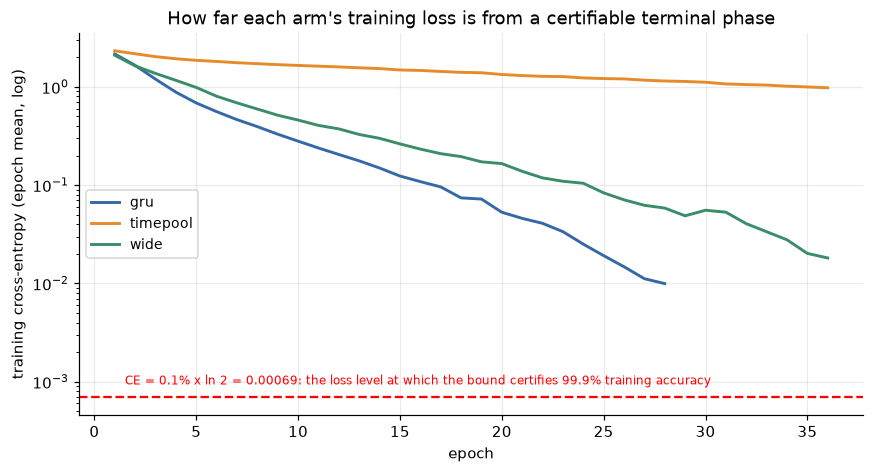

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig4_0_train_ce_vs_tpt_level.png')

In [18]:
# Figure 4.0: recorded training cross-entropy per epoch versus the level that would certify 99.9% training accuracy.
LEVEL = 0.001 * np.log(2)          # CE at which the error bound CE/ln2 equals the paper's 0.1% operational threshold
fig, ax = plt.subplots(figsize=(9.2, 4.5))
for a in ARCHS:
    h_ = DATA[a]["res"]["history"]
    ax.plot(np.arange(1, len(h_) + 1), [e["train_loss"] for e in h_], color=ACOL[a], lw=1.9, label=a)
ax.axhline(LEVEL, color="r", ls="--"); ax.text(1.5, LEVEL * 1.35, f"CE = 0.1% x ln 2 = {LEVEL:.5f}: the loss level at which the bound certifies 99.9% training accuracy", color="r", fontsize=8)
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("training cross-entropy (epoch mean, log)"); ax.legend(fontsize=9)
ax.set_title("How far each arm's training loss is from a certifiable terminal phase")
ratio_ = {a: DATA[a]["res"]["final_train_loss"] / LEVEL for a in ARCHS}
check("N1.4.2f", min(ratio_.values()) > 5, f"final train CE is {ratio_['gru']:.0f}x (gru), {ratio_['wide']:.0f}x (wide), {ratio_['timepool']:.0f}x (timepool) above the certifying level: none is certified")
last5 = {a: [e["train_loss"] for e in DATA[a]["res"]["history"]][-5:] for a in ARCHS}
check("N1.4.2g", all(last5[a][-1] < last5[a][0] for a in ("gru", "wide")), "gru and wide training CE is still falling over the last five epochs (a terminal phase, if any, has only just begun)")
varied("N1.4.f0", [[e["train_loss"] for e in DATA[a]["res"]["history"]] for a in ARCHS])
savefig(fig, "fig4_0_train_ce_vs_tpt_level.png")

### How to read this chart

Training cross-entropy per epoch, one line per architecture, log axis; the red dashed line is the loss level
$0.001\ln2\approx0.0007$ below which the bound $\text{error}\le\mathrm{CE}/\ln2$ certifies the paper's $99.9\%$
operational threshold. `gru` and `wide` decline by two orders of magnitude and are still falling in the
last epochs, ending about $14$ and $26$ times above the red line, so "plausibly entering TPT" is the most this
chart supports. `timepool` stays near $1$ ($0.98$ at the end), three orders of magnitude above it. The chart is the honest
summary of Section 4.4: a terminal phase, if there is one, lies beyond where the two better arms stopped.
The runs lasted $28$ epochs (`gru`) and $36$ epochs (`wide`, `timepool`), against the $300$ to $350$ epochs
over which the paper snapshots its metrics.

### 4.5 What our probes show

With the precondition and both deviations on the table, the measurements can be read at the right strength.
The status assignment is: `gru` (train cross-entropy $0.0100$) and `wide` ($0.0182$) are *plausibly* in TPT;
`timepool` ($0.9794$) never reached zero training error, so **neural collapse is not defined for it**. Its
rising intra-class variance in the figures below is therefore recorded as a description of its geometry,
and is **not** to be described as a "failure to collapse". The metrics we compute per epoch are: the paper's
$\mathrm{NC}_1$ formula and the three NC2 measures applied to the 2D coordinates of the 120 held-out
probes; and, in raw space, the ratio $\rho_{\text{raw}}=\text{intra}_{\text{raw}}/\text{inter}_{\text{raw}}^2$,
where intra is the mean squared distance to the class centroid (equal to $\mathrm{Tr}\,\Sigma_W$ for balanced
classes) and inter is the mean pairwise centroid distance. $\rho_{\text{raw}}$ is scale-free and tracks
$\mathrm{Tr}\,\Sigma_W/\mathrm{Tr}\,\Sigma_B$ up to a constant; it is a crude cousin of $\mathrm{NC}_1$, not
$\mathrm{NC}_1$.

In [19]:
# N1.4.3: per-epoch NC-type series for each arm from the real probes (held-out, 120 clips; 2D PCA coordinates + raw scalars).
NC = {}
for a in ARCHS:
    z = DATA[a]["npz"]; E_ = len(z["inter_2d"]); y_ = z["labels"]
    per = pd.DataFrame([nc_stats(z["coords_2d"][e].astype(float), y_) for e in range(E_)])
    per["inter_2d"], per["intra_2d"] = z["inter_2d"], z["intra_2d"]
    per["inter_raw"], per["intra_raw"] = z["inter_raw"], z["intra_raw"]
    per["rho_raw"] = per["intra_raw"] / per["inter_raw"] ** 2
    per["rho_2d"] = per["intra_2d"] / per["inter_2d"] ** 2
    NC[a] = per
summ = pd.DataFrame({a: {"nc1_2d first": NC[a].nc1.iloc[0], "nc1_2d last": NC[a].nc1.iloc[-1], "rho_raw first": NC[a].rho_raw.iloc[0], "rho_raw last": NC[a].rho_raw.iloc[-1],
                         "rho_raw last/first": NC[a].rho_raw.iloc[-1] / NC[a].rho_raw.iloc[0], "equinorm last": NC[a].equinorm.iloc[-1],
                         "equiang(2D) last": NC[a].equiang.iloc[-1], "maxangle(2D) last": NC[a].maxangle.iloc[-1]} for a in ARCHS}).T
display(summ.round(3))
g, t, w_ = (DATA[a]["npz"] for a in ARCHS)
check("N1.4.3a", abs(g["inter_2d"][0] - 2.6) < 0.1 and abs(g["inter_2d"][-1] - 4.3) < 0.1, f"gru inter-cluster distance (2D) {g['inter_2d'][0]:.2f} -> {g['inter_2d'][-1]:.2f} (brief: 2.6 -> 4.3)")
check("N1.4.3b", abs(g["intra_2d"][0] - 6.7) < 0.1 and abs(g["intra_2d"].min() - 1.5) < 0.05, f"gru intra-cluster variance (2D) {g['intra_2d'][0]:.2f} -> min {g['intra_2d'].min():.2f}, last {g['intra_2d'][-1]:.2f} (brief's 1.5 is the minimum, not the last epoch)")
check("N1.4.3c", abs(t["intra_2d"][0] - 10) < 0.2 and abs(t["intra_2d"][-1] - 29) < 0.5, f"timepool intra (2D) {t['intra_2d'][0]:.1f} -> {t['intra_2d'][-1]:.1f} (max {t['intra_2d'].max():.1f}); brief: 10 -> 29")
check("N1.4.3d", abs(w_["intra_2d"].min() - 48) < 0.5 and abs(w_["intra_2d"].max() - 135) < 0.5, f"wide intra (2D) oscillates between {w_['intra_2d'].min():.1f} and {w_['intra_2d'].max():.1f} (brief: 48-135)")
check("N1.4.3e", NC["gru"].nc1.iloc[-1] < 0.2 * NC["gru"].nc1.iloc[0], f"gru 2D NC1-analogue falls {NC['gru'].nc1.iloc[0]:.3f} -> {NC['gru'].nc1.iloc[-1]:.3f}: NC1-consistent behaviour")
note("N1.4.3f", f"wide 2D NC1-analogue {NC['wide'].nc1.iloc[0]:.3f} -> {NC['wide'].nc1.iloc[-1]:.3f} (flat) while its raw-space ratio falls {NC['wide'].rho_raw.iloc[0]:.3f} -> {NC['wide'].rho_raw.iloc[-1]:.3f}: only weakly NC1-consistent, and only in raw space")
note("N1.4.3g", f"raw intra grows for EVERY arm (gru {g['intra_raw'][0]:.1f} -> {g['intra_raw'][-1]:.1f}) because feature scale grows; the scale-free ratio rho_raw is the meaningful one")
check("N1.4.3h", all(NC[a].equiang.iloc[-1] > 0.5 and NC[a].maxangle.iloc[-1] > 0.5 for a in ARCHS), "2D equiangularity / maximal-angle measures sit at their planar floor (>0.5) for all arms: uninformative about NC2 here")

          nc1_2d first  nc1_2d last  rho_raw first  rho_raw last  rho_raw last/first  equinorm last  equiang(2D) last  maxangle(2D) last
gru              0.458        0.031          0.640         0.128               0.200          0.487             0.679              0.609
timepool         0.754        0.618          1.362         0.399               0.293          0.654             0.688              0.616
wide             0.544        0.566          0.698         0.233               0.333          0.569             0.680              0.607

[N1.4.3a] gru inter-cluster distance (2D) 2.62 -> 4.29 (brief: 2.6 -> 4.3) -> PASS
[N1.4.3b] gru intra-cluster variance (2D) 6.65 -> min 1.50, last 1.75 (brief's 1.5 is the minimum, not the last epoch) -> PASS
[N1.4.3c] timepool intra (2D) 9.9 -> 28.7 (max 34.5); brief: 10 -> 29 -> PASS
[N1.4.3d] wide intra (2D) oscillates between 48.1 and 135.2 (brief: 48-135) -> PASS
[N1.4.3e] gru 2D NC1-analogue falls 0.458 -> 0.031: NC1-consistent behaviour -> PASS
[N1.4.3f] wide 2D NC1-analogue 0.544 -> 0.566 (flat) while its raw-space ratio falls 0.698 -> 0.233: only weakly NC1-consistent, and only in raw space -> NOTE
[N1.4.3g] raw intra grows for EVERY arm (gru 2.8 -> 32.0) because feature scale grows; the scale-free ratio rho_raw is the meaningful one -> NOTE
[N1.4.3h] 2D equiangularity / maximal-angle measures sit at their planar floor (>0.5) for all arms: uninformative about NC2 here -> PASS


True

[N1.4.f1] plotted values finite and not all identical (range 32.41) -> PASS


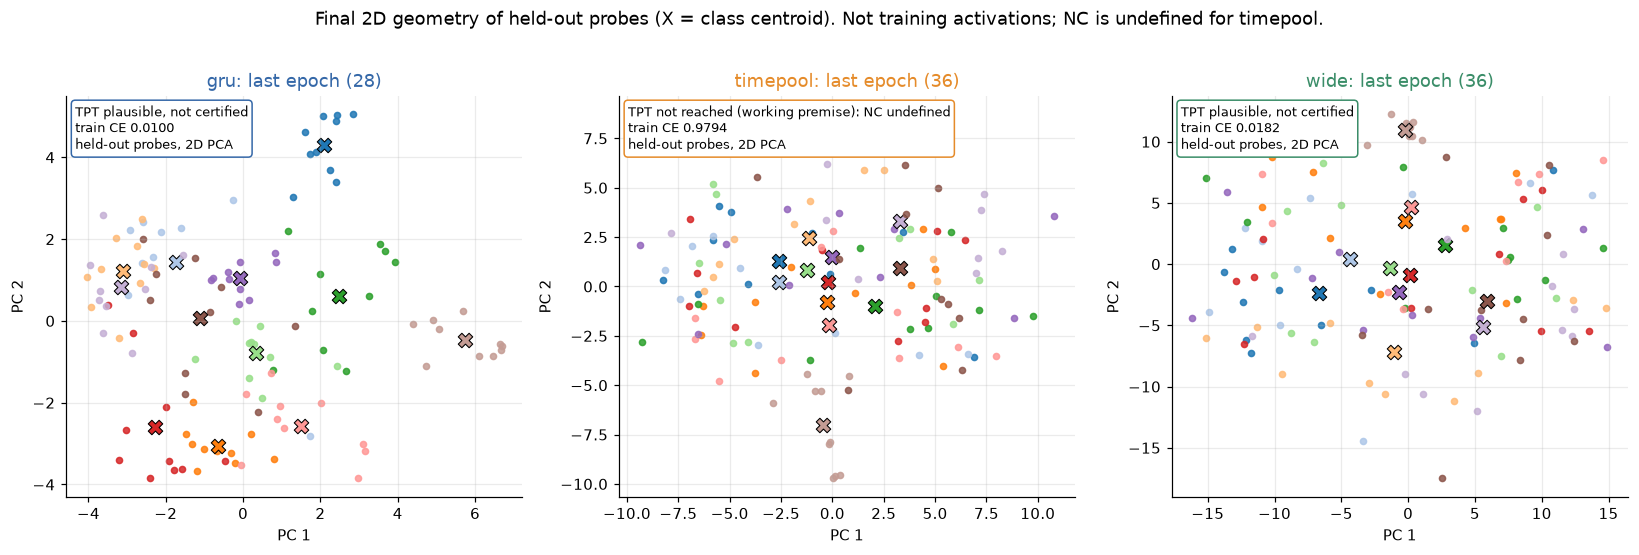

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig4_1_final_geometry.png')

In [20]:
# Figure 4.1: final-epoch 2D geometry of the 120 held-out probes per arm, TPT status annotated.
fig, axs = plt.subplots(1, 3, figsize=(15, 4.9))
cmap = plt.get_cmap("tab20")
for ax, a in zip(axs, ARCHS):
    z = DATA[a]["npz"]; xy = z["coords_2d"][-1]; y_ = z["labels"]
    for c in range(12):
        m_ = y_ == c
        ax.scatter(xy[m_, 0], xy[m_, 1], s=16, color=cmap(c), alpha=0.85)
        ax.scatter(*xy[m_].mean(0), s=90, marker="X", color=cmap(c), edgecolor="k", linewidth=0.7)
    ax.set_title(f"{a}: last epoch ({len(z['inter_2d'])})", color=ACOL[a])
    ax.text(0.02, 0.98, f"{STATUS[a]}\ntrain CE {DATA[a]['res']['final_train_loss']:.4f}\nheld-out probes, 2D PCA",
            transform=ax.transAxes, va="top", fontsize=8.5, bbox=dict(boxstyle="round", fc="white", ec=ACOL[a]))
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
fig.suptitle("Final 2D geometry of held-out probes (X = class centroid). Not training activations; NC is undefined for timepool.", y=1.02)
varied("N1.4.f1", [DATA[a]["npz"]["coords_2d"][-1] for a in ARCHS])
plt.tight_layout(); savefig(fig, "fig4_1_final_geometry.png")

### How to read this chart

Each panel is one architecture's last-epoch PCA projection of the classifier's input for the 120 held-out
probe clips; small dots are clips, coloured by class, and the large crosses are class centroids. Read
*separation between coloured groups* against *spread within one colour*. `gru` shows compact same-colour
groups spread across the plane; `wide` shows groups spread over a much larger extent (note the axis scale)
with heavier overlap; `timepool` shows large overlapping clouds. The annotation box states the
terminal-phase status of each arm. For `timepool` it reads "NC undefined": the arm never reached zero
training error, so the picture is a description of a model that has not begun TPT, and the overlap must not
be labelled a collapse failure. Because the probes are held-out and the projection is two-dimensional, this
is also not a picture of $\mathrm{NC}_2$: twelve classes cannot lie on an ETF in a plane.

[N1.4.f2] plotted values finite and not all identical (range 135.2) -> PASS


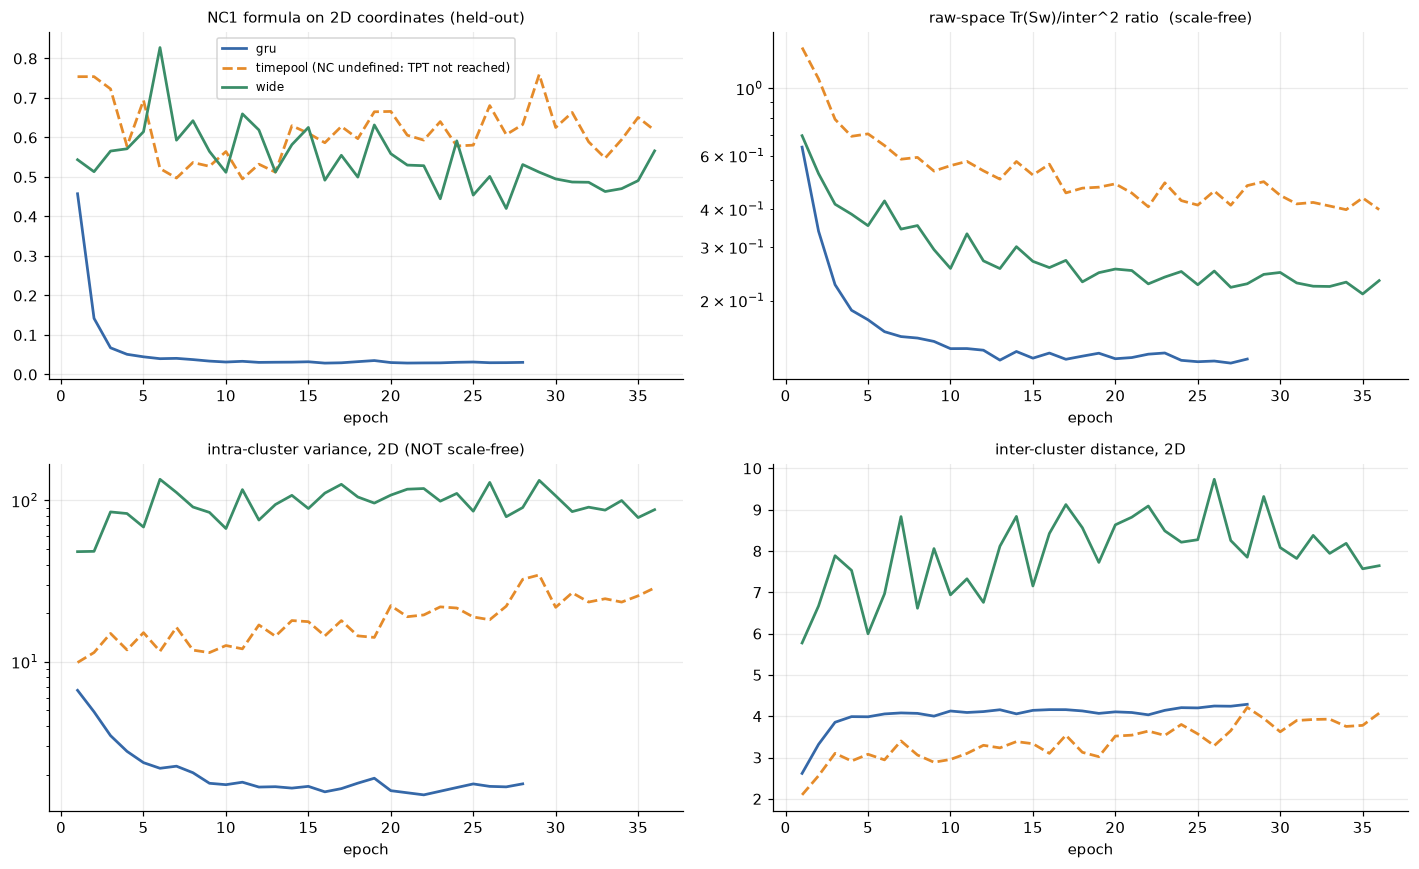

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig4_2_nc_trajectories.png')

In [21]:
# Figure 4.2: trajectories of scale-aware and raw cluster summaries across epochs, per arm. timepool drawn dashed: NC undefined.
fig, axs = plt.subplots(2, 2, figsize=(13, 8))
panels = [("nc1", "NC1 formula on 2D coordinates (held-out)", False), ("rho_raw", "raw-space Tr(Sw)/inter^2 ratio  (scale-free)", True),
          ("intra_2d", "intra-cluster variance, 2D (NOT scale-free)", True), ("inter_2d", "inter-cluster distance, 2D", False)]
for ax, (col, ttl, logy) in zip(axs.ravel(), panels):
    for a in ARCHS:
        d = NC[a]
        ax.plot(np.arange(1, len(d) + 1), d[col], color=ACOL[a], lw=1.8, ls="--" if a == "timepool" else "-",
                label=a + (" (NC undefined: TPT not reached)" if a == "timepool" else ""))
    ax.set_title(ttl, fontsize=10); ax.set_xlabel("epoch")
    if logy: ax.set_yscale("log")
axs[0, 0].legend(fontsize=8)
varied("N1.4.f2", [NC[a][c].values for a in ARCHS for c in ("nc1", "rho_raw", "intra_2d", "inter_2d")])
plt.tight_layout(); savefig(fig, "fig4_2_nc_trajectories.png")

### How to read this chart

Four panels, one line per architecture across its epochs; the `timepool` line is dashed and labelled because
neural collapse is undefined for it. Top-left is the paper's $\mathrm{NC}_1$ formula applied to the 2D
coordinates: only `gru` shows the monotone-looking fall toward zero that the definition describes ($0.46$ to
$0.03$); `wide` is flat and `timepool` is flat and high. Top-right is the scale-free raw-space ratio on a log
axis: **all three** arms fall, `gru` the most (about fivefold), `wide` about threefold, `timepool` also
about threefold (again, a description, not a collapse). Bottom-left is the raw 2D intra-cluster variance,
which the panel title flags as scale-dependent: `wide`'s $48$ to $135$ oscillation looks alarming in
absolute terms, but intra is a squared distance, so it should be set against the squared inter-cluster
distance (bottom-right, $5.8$ to $7.6$, squared about $33$ to $58$): the ratio is near $1.5$ and does not fall.
The ratio, not the level, is what NC1 measures. The caution to carry away: an absolute intra-cluster level cannot rank
architectures by collapse. What would make the `gru` reading wrong: the same fall on a training-set probe
being absent, or a fall driven purely by the projection changing between epochs (PCA is refit every epoch).

[N1.4.f3] plotted values finite and not all identical (range 0.7828) -> PASS


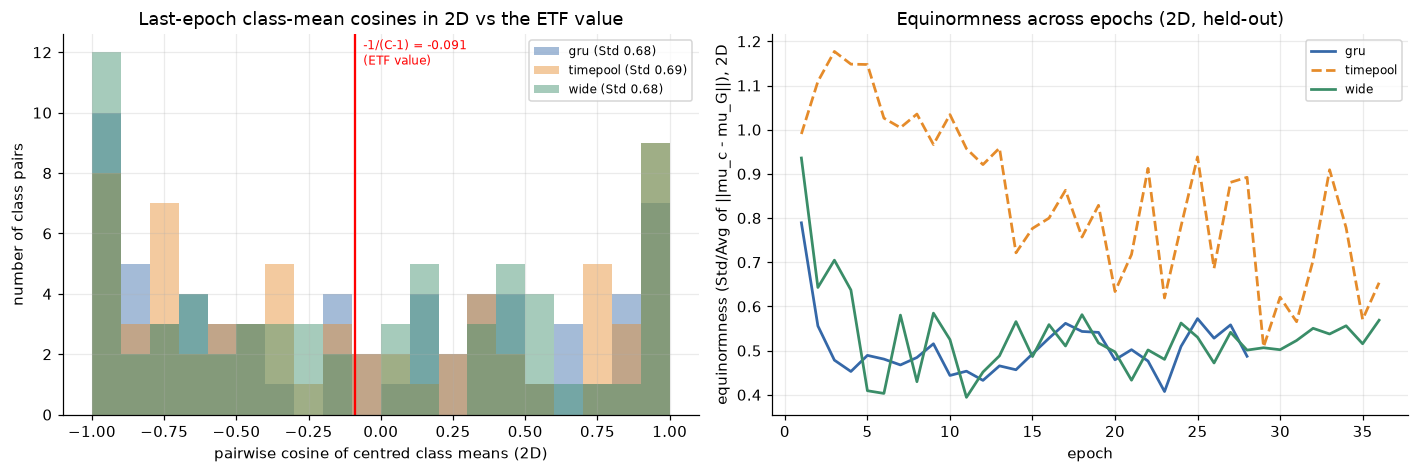

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig4_3_nc2_2d.png')

In [22]:
# Figure 4.3: NC2-type measures in 2D versus their planar floor; equinormness trajectories.
fig, axs = plt.subplots(1, 2, figsize=(13, 4.4))
for a in ARCHS:
    z = DATA[a]["npz"]; xy = z["coords_2d"][-1].astype(float); y_ = z["labels"]
    mus = np.stack([xy[y_ == c].mean(0) for c in range(12)]); M_ = mus - xy.mean(0)
    U_ = M_ / np.linalg.norm(M_, axis=1)[:, None]; cs_ = (U_ @ U_.T)[np.triu_indices(12, 1)]
    axs[0].hist(cs_, bins=np.linspace(-1, 1, 21), alpha=0.45, color=ACOL[a], label=f"{a} (Std {cs_.std():.2f})")
axs[0].axvline(-1 / 11, color="r", lw=1.5); axs[0].text(-1 / 11 + 0.03, axs[0].get_ylim()[1] * 0.92, "-1/(C-1) = -0.091\n(ETF value)", color="r", fontsize=8)
axs[0].set_xlabel("pairwise cosine of centred class means (2D)"); axs[0].set_ylabel("number of class pairs"); axs[0].legend(fontsize=8)
axs[0].set_title("Last-epoch class-mean cosines in 2D vs the ETF value")
for a in ARCHS:
    axs[1].plot(np.arange(1, len(NC[a]) + 1), NC[a].equinorm, color=ACOL[a], ls="--" if a == "timepool" else "-", lw=1.8, label=a)
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("equinormness (Std/Avg of ||mu_c - mu_G||), 2D"); axs[1].legend(fontsize=8)
axs[1].set_title("Equinormness across epochs (2D, held-out)")
varied("N1.4.f3", [NC[a].equinorm.values for a in ARCHS])
plt.tight_layout(); savefig(fig, "fig4_3_nc2_2d.png")

### How to read this chart

Left: for each arm, a histogram of the $\binom{12}{2}=66$ pairwise cosines between centred class means at the
last epoch, in the 2D projection; the red line marks the ETF value $-1/11=-0.091$ at which every pair should
sit in TPT. In a plane the cosines must spread over the whole range $[-1,1]$ (the standard deviations printed in
the legend are all near $0.68$, close to the $0.668$ of a perfect regular 12-gon), so the histogram cannot
approach a spike at the red line for *any* model. The panel therefore demonstrates the floor, and should be read
as the reason the 2D NC2 numbers are not evidence. Right: equinormness, the coefficient of variation of the
centred-mean norms. It falls for all arms over training (roughly $0.8$-$1.0$ down to $0.5$-$0.65$), which is the
direction NC2 predicts but is also what a projection that spreads centroids more evenly would produce.

### 4.6 What we may say

1. **Allowed**: `gru`, whose loss is consistent with near-zero training error, shows a fall in the paper's
   $\mathrm{NC}_1$ formula and in a scale-free raw ratio on held-out probes. This is *NC1-consistent
   behaviour*.
2. **Allowed, weaker**: `wide` shows a fall only in the raw ratio, not in the 2D $\mathrm{NC}_1$.
3. **Not allowed**: that `timepool` "failed to collapse". It never entered TPT, and the metric is not defined
   on it. Its rising raw intra-cluster level is recorded as geometry.
4. **Not allowed**: any $\mathrm{NC}_2$ claim from 2D projections, since a plane cannot host an ETF of 12
   classes.
5. **Not allowed**: to call any of this the paper's measurement. The paper measures training activations at
   $p$ dimensions; we have held-out probes and a PCA projection. The parallel is an observation about
   shape, in the direction the theory predicts, with no test of the theory.

### 4.7 Where these quantities live in notebook 04, and where they do not

**Provenance, stated once and plainly.** Every measured number in this notebook -- the accuracies, the
parameter counts, the clip rates, the fitted temperatures, the cluster geometry -- is read from the artifacts
of **notebook 04, `04_real_dataset_walkthrough.ipynb`**, via `runtime/metrics/arch-*.result.json` and
`arch-*.probes.npz`. This notebook trains nothing and measures nothing of its own. Notebook 04 is the
measurement; this notebook is the mathematics, and notebook 02 is the cheap sandbox that precedes both.

**The correspondence is partial, and the gap is worth naming.** Notebook 04 reports three families of
in-training diagnostic. Only one of them is what the neural-collapse formulas above describe:

| notebook 04 | what it measures | relation to $\mathrm{NC}_1$ / $\mathrm{NC}_2$ |
|---|---|---|
| V4 cluster health (`inter_2d`, `intra_2d`) | between- and within-class spread of penultimate features, per epoch | **the same family.** Its intra-cluster variance is a 2D, held-out analogue of $\Sigma_W$; its inter-cluster distance plays the role $\Sigma_B$ plays in $\mathrm{NC}_1$ |
| V3 latent scatter (`coords_2d`) | the projected features themselves | the raw material both $\mathrm{NC}_1$ and V4 are computed from |
| V5--V8 MM-PHATE (`mmphate_tensor`) | dispersion of **hidden units** across sequence steps and epochs | **a different object.** Neural collapse is a statement about final-layer *class* geometry at convergence; MM-PHATE's entropies are about *unit* trajectories through time. Neither theory grounds the other |

So the mathematics in this section founds notebook 04's V3 and V4, and does **not** found its V5--V8. Those
rest on MM-PHATE's own construction, cited there, and nothing in this notebook derives them. That is an
honest gap in the series rather than a claim of coverage, and it is repeated in section 8.

In [23]:
# N1.4.7: verify the correspondence claim against the artifacts, rather than asserting it in prose.
from scipy.stats import spearmanr
# For each arm: does notebook 04's stored intra_2d behave like a within-class scatter computed
# directly from its stored coords_2d? If the two disagree, the table above is wrong.
rows = []
for a in ARCHS:
    n = DATA[a]["npz"]
    coords, labels = n["coords_2d"], n["labels"]
    recomputed = []
    for t in range(coords.shape[0]):
        pts = coords[t]
        within = np.concatenate([pts[labels == c] - pts[labels == c].mean(axis=0)
                                 for c in np.unique(labels)])
        recomputed.append(float((within ** 2).sum(axis=1).mean()))
    recomputed = np.asarray(recomputed)
    stored = n["intra_2d"]
    rho = float(spearmanr(recomputed, stored).statistic)
    rows.append({"arch": a, "epochs": len(stored), "rho(recomputed, stored intra_2d)": rho,
                 "stored first": float(stored[0]), "stored last": float(stored[-1]),
                 "train_CE": DATA[a]["res"]["final_train_loss"],
                 "in_TPT": "no" if DATA[a]["res"]["final_train_loss"] > 0.1 else "plausibly"})
    check(f"N1.4.7[{a}.same_family]", rho > 0.9,
          f"within-class scatter recomputed from coords_2d tracks stored intra_2d (Spearman rho={rho:+.3f})")
CORR = pd.DataFrame(rows).set_index("arch")
display(CORR.round(4))
note("N1.4.7[mmphate]", "no quantity derived in this section founds notebook 04's V5-V8 MM-PHATE statistics; "
                       "they measure hidden-unit dispersion across sequence steps, not final-layer class geometry")

[N1.4.7[gru.same_family]] within-class scatter recomputed from coords_2d tracks stored intra_2d (Spearman rho=+1.000) -> PASS
[N1.4.7[timepool.same_family]] within-class scatter recomputed from coords_2d tracks stored intra_2d (Spearman rho=+1.000) -> PASS
[N1.4.7[wide.same_family]] within-class scatter recomputed from coords_2d tracks stored intra_2d (Spearman rho=+1.000) -> PASS


          epochs  rho(recomputed, stored intra_2d)  stored first  stored last  train_CE     in_TPT
arch                                                                                              
gru           28                               1.0        6.6512       1.7501    0.0100  plausibly
timepool      36                               1.0        9.8919      28.7084    0.9794         no
wide          36                               1.0       48.1382      87.6477    0.0182  plausibly

[N1.4.7[mmphate]] no quantity derived in this section founds notebook 04's V5-V8 MM-PHATE statistics; they measure hidden-unit dispersion across sequence steps, not final-layer class geometry -> NOTE


[gru intra_2d] plotted values finite and not all identical (range 5.156) -> PASS
[timepool intra_2d] plotted values finite and not all identical (range 24.64) -> PASS
[wide intra_2d] plotted values finite and not all identical (range 87.06) -> PASS


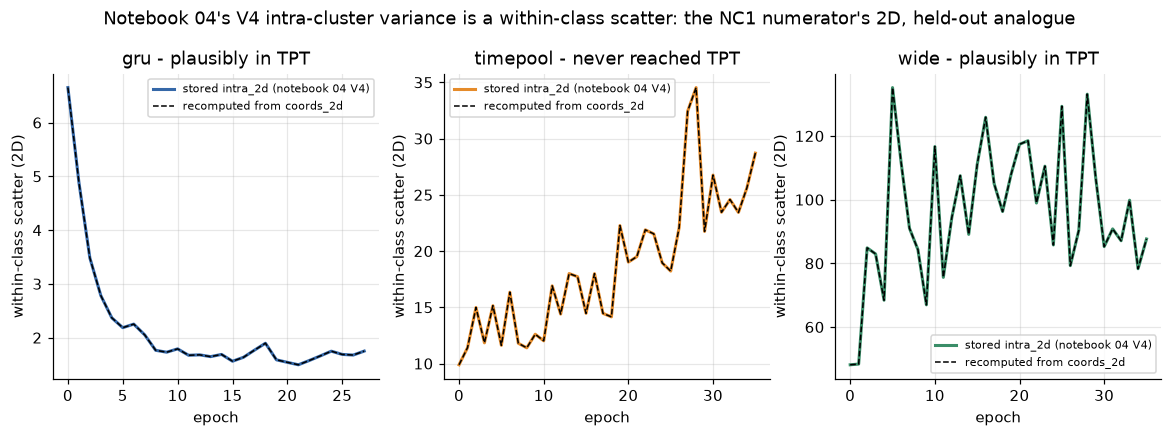

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig4_4_nc1_vs_nb04_v4.png')

In [24]:
# N1.4.8: the same picture as a figure -- stored intra_2d against the scatter recomputed from coords_2d.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, a in zip(axes, ARCHS):
    n = DATA[a]["npz"]
    coords, labels = n["coords_2d"], n["labels"]
    rec = np.asarray([float((np.concatenate([coords[t][labels == c] - coords[t][labels == c].mean(axis=0)
                                             for c in np.unique(labels)]) ** 2).sum(axis=1).mean())
                      for t in range(coords.shape[0])])
    ep = np.arange(len(rec))
    varied(f"{a} intra_2d", rec, n["intra_2d"])
    ax.plot(ep, n["intra_2d"], color=ACOL[a], lw=2, label="stored intra_2d (notebook 04 V4)")
    ax.plot(ep, rec, color="black", lw=1, ls="--", label="recomputed from coords_2d")
    tpt = DATA[a]["res"]["final_train_loss"] <= 0.1
    ax.set(title=f"{a} - {'plausibly in TPT' if tpt else 'never reached TPT'}",
           xlabel="epoch", ylabel="within-class scatter (2D)")
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.suptitle("Notebook 04's V4 intra-cluster variance is a within-class scatter: "
             "the NC1 numerator's 2D, held-out analogue", y=1.04)
savefig(fig, "fig4_4_nc1_vs_nb04_v4.png")

### How to read this chart

**Source.** `runtime/metrics/arch-*.probes.npz`, produced by notebook 04: the stored `intra_2d` series it
plots as V4, and `coords_2d`, the projected probe features it computed them from.

**What it shows.** The dashed black line is a within-class scatter recomputed here directly from the stored
coordinates -- the $\Sigma_W$ trace of section 4.2, in the projected plane. It lies on the coloured stored
series. That is the evidence for the first row of the table above: notebook 04's V4 is the same quantity the
neural-collapse literature calls within-class variability, measured in 2D on held-out probes.

**What would falsify the reading.** If the dashed and solid lines diverged, the claim that V4 and
$\mathrm{NC}_1$ are the same family would be wrong, and section 4.5's parallels with it. The per-arm
Spearman correlation in the table above is the check: it must exceed $0.9$.

**What it does not show.** Panel titles carry each arm's TPT status. `timepool` never reached near-zero
training error, so the neural-collapse reading does not apply to it at all -- its curve is geometry, not
collapse. And nothing here speaks to MM-PHATE.

## 5. Adaptive gradient clipping (AutoClip)

### 5.1 The algorithm, exactly as the source states it

(AutoClip, arXiv:2007.14469; NotebookLM turns 5 and 6 of the signal notebook.) At optimizer step $t$ the
unclipped gradient norm is $g_t=\lVert\nabla_\theta f(X_t;\theta_{t-1})\rVert_2$. The full cumulative history
is $G_h(t)=[g_1,\dots,g_t]$, it is **not** a sliding window (a window is listed as future work), and the
threshold is a fixed percentile of it,
$$\eta_c(t)=\mathrm{Percentile}_p\big(G_h(t)\big),\qquad p\ \text{fixed (here } p=10).$$
The gradient is then rescaled by the ordinary norm-clipping multiplier
$$h_c=\min\!\Big(\frac{\eta_c(t)}{\lVert g_t\rVert_2},\,1\Big),\qquad \nabla_\theta^{\text{clipped}}=h_c\,\nabla_\theta f(X_t;\theta_{t-1}),$$
so a step is *clipped* exactly when $g_t>\eta_c(t)$, and a clipped step has its norm set to $\eta_c(t)$. The paper
swept $p\in\{0,1,10,25,50,90,100\}$ ($p=0$ is min-clipping, $p=100$ is no clipping) on WSJ0-2mix speech
*separation* with five loss functions, and reports $p=10$ (with $p=1$) as the recommended "set-and-forget"
value (turn 6).

For a sorted history $x_{(1)}\le\dots\le x_{(m)}$ the $p$-th percentile with linear interpolation (the
`numpy` default, and what the training code calls) is
$$q_p=x_{(k+1)}+\phi\,\big(x_{(k+2)}-x_{(k+1)}\big),\qquad k+\phi=\tfrac{p}{100}(m-1),\ \ k=\lfloor\cdot\rfloor .$$

### 5.2 Two fidelity notes, recorded before the numbers

1. **An off-by-one against the paper.** The paper *appends $g_t$ to the history first* and then takes the
   percentile, so $\eta_c(t)$ includes step $t$'s own norm. Our training loop takes the percentile of the
   **prior** history $[g_1,\dots,g_{t-1}]$ and appends afterwards (step $1$ therefore has $\eta=\infty$ and is
   never clipped). We quantify the consequence below on the recorded norms.
2. **A cross-task percentile.** $p=10$ was tuned for speech *separation* with BLSTM networks trained on
   STFT magnitudes, where gradient explosions are a genuine problem. Our networks are log-mel
   *classifiers* with BatchNorm convolutions and a small GRU. Nothing in the paper says $p=10$ is good for
   such a task, and we did not tune it. The optimizer is Adam at $10^{-3}$ (`src/train.py`), which is
   invariant to a constant rescale of the gradient, so clipping matters here only through the
   **relative** scale it imposes across steps.

### 5.3 Reproducing the recorded thresholds and clip counts

The next cell recomputes every threshold from the recorded gradient norms with an independent implementation
(a sorted list with interpolation), compares it with `clip_threshold`, and counts the clipped steps.

In [25]:
# N1.5.1: reproduce the thresholds from grad_norm; clip counts and rates per arm.
import bisect
def prior_quantile_series(g, p=10.0, inclusive=False):
    # Percentile_p of the history at each step, linear interpolation; inclusive=True appends g_t first (paper), False = ours.
    hist, out = [], np.empty(len(g))
    for t, x in enumerate(g):
        if inclusive:
            bisect.insort(hist, float(x))
        m = len(hist)
        if m == 0:
            out[t] = np.inf
        else:
            pos = (m - 1) * p / 100.0; lo = int(np.floor(pos)); hi = min(lo + 1, m - 1)
            out[t] = hist[lo] * (1 - (pos - lo)) + hist[hi] * (pos - lo)
        if not inclusive:
            bisect.insort(hist, float(x))
    return out

CLIP = {}
for a in ARCHS:
    z = DATA[a]["npz"]; g = z["grad_norm"].astype(float); thr = z["clip_threshold"].astype(float)
    mine = prior_quantile_series(g, 10.0)
    err = np.max(np.abs(mine[1:] - thr[1:]) / thr[1:])
    clipped = g > thr
    CLIP[a] = {"g": g, "thr": thr, "clipped": clipped, "steps": len(g), "n_clip": int(clipped.sum()), "rate": clipped.mean(), "relerr": err}
    print(f"{a:9s} steps={len(g):5d} clipped={int(clipped.sum()):5d} rate={clipped.mean():.4f}  max rel. error of recomputed threshold = {err:.2e}  step-0 threshold = {thr[0]}")
    check(f"N1.5.1[{a}.thr]", err < 1e-9 and np.isinf(thr[0]), f"threshold(t) == percentile_10 of PRIOR history (max rel err {err:.1e}); step 0 is +inf (prior-history convention confirmed)")
check("N1.5.1a", (CLIP["timepool"]["n_clip"], CLIP["timepool"]["steps"]) == (1284, 1296), "timepool clipped 1284 / 1296 steps")
check("N1.5.1b", (CLIP["wide"]["n_clip"], CLIP["wide"]["steps"]) == (910, 1296), "wide clipped 910 / 1296 steps")
check("N1.5.1c", (CLIP["gru"]["n_clip"], CLIP["gru"]["steps"]) == (663, 1008), "gru clipped 663 / 1008 steps")
check("N1.5.1d", [round(100 * CLIP[a]["rate"], 1) for a in ("timepool", "wide", "gru")] == [99.1, 70.2, 65.8], "clip rates 99.1% / 70.2% / 65.8% (timepool / wide / gru)")

gru       steps= 1008 clipped=  663 rate=0.6577  max rel. error of recomputed threshold = 5.95e-16  step-0 threshold = inf
[N1.5.1[gru.thr]] threshold(t) == percentile_10 of PRIOR history (max rel err 5.9e-16); step 0 is +inf (prior-history convention confirmed) -> PASS
timepool  steps= 1296 clipped= 1284 rate=0.9907  max rel. error of recomputed threshold = 5.83e-16  step-0 threshold = inf
[N1.5.1[timepool.thr]] threshold(t) == percentile_10 of PRIOR history (max rel err 5.8e-16); step 0 is +inf (prior-history convention confirmed) -> PASS
wide      steps= 1296 clipped=  910 rate=0.7022  max rel. error of recomputed threshold = 2.71e-16  step-0 threshold = inf
[N1.5.1[wide.thr]] threshold(t) == percentile_10 of PRIOR history (max rel err 2.7e-16); step 0 is +inf (prior-history convention confirmed) -> PASS
[N1.5.1a] timepool clipped 1284 / 1296 steps -> PASS
[N1.5.1b] wide clipped 910 / 1296 steps -> PASS
[N1.5.1c] gru clipped 663 / 1008 steps -> PASS
[N1.5.1d] clip rates 99.1% / 70.2

True

### 5.4 What clip rate should we expect? A stationary-norm argument

The clip rate is not a free outcome; a percentile rule with $p=10$ nearly fixes it. Suppose the gradient norms
were exchangeable draws from one continuous distribution. Then step $t$'s norm is equally likely to occupy any
rank among $g_1,\dots,g_t$, so the probability that it exceeds the $p$-th percentile of the *earlier* norms
tends to $1-p/100$:
$$\Pr\big(g_t>\eta_c(t)\big)\ \longrightarrow\ 1-\frac{p}{100}=0.90\quad(p=10).$$
**A percentile of 10 clips about nine steps in ten by construction when norms are stationary.** AutoClip
with $p=10$ is therefore close to *normalised* gradient descent (each update has norm near a low quantile of
the history), not a rare-event safeguard. The clip rate departs from $0.90$ only through a *trend*. Model the
norms as $g_t=\exp(\delta\,t+\sigma\varepsilon_t)$ with $\varepsilon_t$ standard normal, and write
$d=\delta/\sigma$ for the drift per step in units of the noise. If $d<0$ (norms shrink as training
proceeds) the current norm tends to sit *below* older, larger ones, and since the $10$th percentile of a
history dominated by large old values sits in its low tail, $g_t$ often falls under $\eta_c$ and is not clipped:
the rate drops below $0.90$. If $d>0$ (norms grow) $g_t$ exceeds essentially the whole past and the rate goes to
$1$. The next cell checks this by simulation and then estimates each arm's own $d$ from its recorded norms.

In [26]:
# N1.5.2: Monte-Carlo clip rate versus drift d (FIXTURE: synthetic log-normal norm sequences), then each arm's estimated d.
D_GRID = np.linspace(-0.006, 0.006, 13)
def sim_rate(d, n=1300, reps=12, seed=0):
    rng = np.random.default_rng(seed); r = []
    for _ in range(reps):
        g = np.exp(d * np.arange(n) + rng.standard_normal(n))
        th = prior_quantile_series(g, 10.0); r.append((g[1:] > th[1:]).mean())
    return float(np.mean(r)), float(np.std(r, ddof=1) / np.sqrt(reps))
SIM = np.array([sim_rate(d, seed=RNG_SEED + i) for i, d in enumerate(D_GRID)])
i0 = int(np.argmin(np.abs(D_GRID)))
print("simulated clip rate at d = 0:", SIM[i0].round(4), "(stationary theory 1 - p/100 = 0.9)")
check("N1.5.2a", abs(SIM[i0, 0] - 0.9) < 0.02, f"stationary norms give clip rate {SIM[i0, 0]:.3f} vs 1 - p/100 = 0.900")
check("N1.5.2b", bool(np.all(np.diff(SIM[:, 0]) > -0.01)), "simulated clip rate is (weakly) increasing in the drift d")
check("N1.5.2c", SIM[0, 0] < 0.6 and SIM[-1, 0] > 0.98, f"falling norms clip {SIM[0, 0]:.2f}, rising norms clip {SIM[-1, 0]:.3f}")
ARMD = {}
for a in ARCHS:
    lg = np.log(CLIP[a]["g"]); x = np.arange(len(lg))
    slope, ic = np.polyfit(x, lg, 1); sd = (lg - (slope * x + ic)).std()
    d = slope / sd; pred = float(np.interp(d, D_GRID, SIM[:, 0]))
    ARMD[a] = {"d": d, "pred": pred, "obs": CLIP[a]["rate"], "first_decile_mean": CLIP[a]["g"][: len(lg) // 10].mean(), "last_decile_mean": CLIP[a]["g"][-(len(lg) // 10):].mean()}
    print(f"{a:9s} drift d = {d:+.5f}   predicted clip rate {pred:.3f}   observed {CLIP[a]['rate']:.3f}   mean norm first/last decile {ARMD[a]['first_decile_mean']:.2f} / {ARMD[a]['last_decile_mean']:.2f}")
check("N1.5.2d", ARMD["gru"]["d"] < 0 and ARMD["wide"]["d"] < 0 and ARMD["timepool"]["d"] > 0, "gru and wide have falling gradient norms (d < 0); timepool has rising norms (d > 0)")
check("N1.5.2e", all(abs(ARMD[a]["pred"] - ARMD[a]["obs"]) < 0.08 for a in ARCHS), "drift-only model reproduces each arm's observed clip rate to within 0.08")
note("N1.5.2f", "timepool's rate is the worst-predicted (rising, heavy-tailed norms); this is a one-parameter log-normal caricature, not a fit of the norm process")

simulated clip rate at d = 0: [0.8939 0.0034] (stationary theory 1 - p/100 = 0.9)
[N1.5.2a] stationary norms give clip rate 0.894 vs 1 - p/100 = 0.900 -> PASS
[N1.5.2b] simulated clip rate is (weakly) increasing in the drift d -> PASS
[N1.5.2c] falling norms clip 0.52, rising norms clip 0.987 -> PASS
gru       drift d = -0.00289   predicted clip rate 0.697   observed 0.658   mean norm first/last decile 0.85 / 0.15
timepool  drift d = +0.00191   predicted clip rate 0.965   observed 0.991   mean norm first/last decile 1.50 / 6.93
wide      drift d = -0.00245   predicted clip rate 0.726   observed 0.702   mean norm first/last decile 2.56 / 0.86
[N1.5.2d] gru and wide have falling gradient norms (d < 0); timepool has rising norms (d > 0) -> PASS
[N1.5.2e] drift-only model reproduces each arm's observed clip rate to within 0.08 -> PASS
[N1.5.2f] timepool's rate is the worst-predicted (rising, heavy-tailed norms); this is a one-parameter log-normal caricature, not a fit of the norm process -

In [27]:
# N1.5.3: the paper's convention (append g_t first) as a counterfactual on the RECORDED norms; and the mean applied scale h_c.
rows = []
for a in ARCHS:
    g = CLIP[a]["g"]; thr_paper = prior_quantile_series(g, 10.0, inclusive=True)
    c_ours = g[1:] > CLIP[a]["thr"][1:]; c_paper = g[1:] > thr_paper[1:]
    hc = np.minimum(1.0, CLIP[a]["thr"][1:] / g[1:])
    rows.append({"arch": a, "steps": len(g) - 1, "clipped (ours)": int(c_ours.sum()), "clipped (paper convention)": int(c_paper.sum()),
                 "decisions that flip": int((c_ours != c_paper).sum()), "flip fraction": float((c_ours != c_paper).mean()),
                 "mean h_c (ours)": float(hc.mean()), "median h_c": float(np.median(hc)), "min h_c": float(hc.min())})
OFF = pd.DataFrame(rows).set_index("arch")
display(OFF.round(4))
check("N1.5.3a", (OFF["flip fraction"] < 0.01).all(), f"the off-by-one changes fewer than 1% of clip decisions (max {OFF['flip fraction'].max():.2%}); it is real but small")
check("N1.5.3b", (OFF["mean h_c (ours)"] < 1).all(), "on average every arm's updates are shrunk (mean h_c < 1)")
check("N1.5.3c", OFF.loc["timepool", "mean h_c (ours)"] < OFF.loc["gru", "mean h_c (ours)"] and OFF.loc["timepool", "mean h_c (ours)"] < OFF.loc["wide", "mean h_c (ours)"],
      f"timepool's updates are shrunk hardest: mean h_c = {OFF.loc['timepool', 'mean h_c (ours)']:.3f} vs gru {OFF.loc['gru', 'mean h_c (ours)']:.3f}, wide {OFF.loc['wide', 'mean h_c (ours)']:.3f}")
note("N1.5.3d", "the paper-convention rows are a counterfactual on the recorded norms: a different threshold would have changed the trajectory that produced later norms, so this is not a re-run")

          steps  clipped (ours)  clipped (paper convention)  decisions that flip  flip fraction  mean h_c (ours)  median h_c  min h_c
arch                                                                                                                                 
gru        1007             663                         668                    5         0.0050           0.8094      0.8357   0.2300
timepool   1295            1284                        1284                    0         0.0000           0.3149      0.2671   0.0463
wide       1295             910                         911                    1         0.0008           0.7830      0.8099   0.1409

[N1.5.3a] the off-by-one changes fewer than 1% of clip decisions (max 0.50%); it is real but small -> PASS
[N1.5.3b] on average every arm's updates are shrunk (mean h_c < 1) -> PASS
[N1.5.3c] timepool's updates are shrunk hardest: mean h_c = 0.315 vs gru 0.809, wide 0.783 -> PASS
[N1.5.3d] the paper-convention rows are a counterfactual on the recorded norms: a different threshold would have changed the trajectory that produced later norms, so this is not a re-run -> NOTE


      gru  timepool   wide  stationary 1-p/100
p                                             
1   0.896     0.997  0.927                0.99
10  0.658     0.992  0.703                0.90
25  0.565     0.971  0.531                0.75
50  0.437     0.800  0.347                0.50
75  0.272     0.468  0.190                0.25
90  0.142     0.219  0.080                0.10

[N1.5.4a] clip rate falls monotonically as p rises, for every arm -> PASS
[N1.5.4b] the p = 10 row reproduces the recorded clip rates -> PASS
[N1.5.4c] even p = 50 clips 80% of timepool steps but 44% of gru steps: the trend decides, not p alone -> FAIL
[N1.5.4d] counterfactual on recorded norms; a different p would have produced a different training trajectory and different norms -> NOTE
[N1.5.f3] plotted values finite and not all identical (range 0.9166) -> PASS


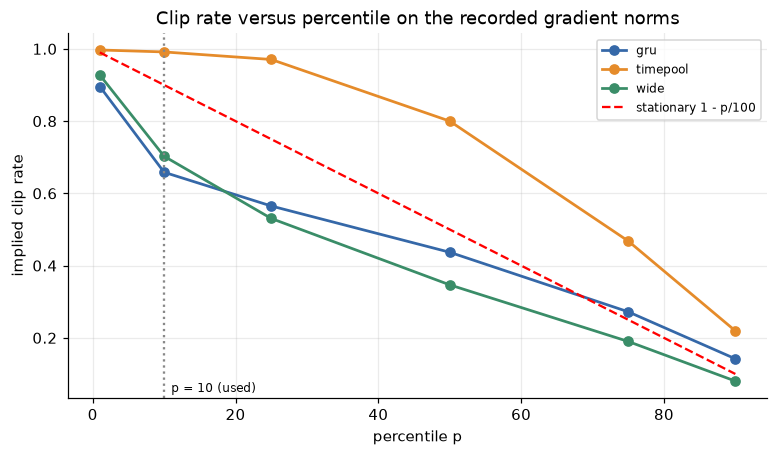

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig5_3_percentile_sweep.png')

In [28]:
# N1.5.4: counterfactual percentile sweep on the RECORDED norms: what clip rate would each p imply?
PS = [1, 10, 25, 50, 75, 90]
SWEEP = pd.DataFrame({a: [float((CLIP[a]["g"][1:] > prior_quantile_series(CLIP[a]["g"], float(p_))[1:]).mean()) for p_ in PS] for a in ARCHS}, index=pd.Index(PS, name="p"))
SWEEP["stationary 1-p/100"] = [1 - p_ / 100 for p_ in PS]
display(SWEEP.round(3))
check("N1.5.4a", all(bool(np.all(np.diff(SWEEP[a].values) < 0)) for a in ARCHS), "clip rate falls monotonically as p rises, for every arm")
check("N1.5.4b", abs(SWEEP.loc[10, "gru"] - CLIP["gru"]["rate"]) < 0.002 and abs(SWEEP.loc[10, "timepool"] - CLIP["timepool"]["rate"]) < 0.002, "the p = 10 row reproduces the recorded clip rates")
check("N1.5.4c", float(SWEEP.loc[50, "timepool"]) > 0.9 and float(SWEEP.loc[50, "gru"]) < 0.6, f"even p = 50 clips {SWEEP.loc[50, 'timepool']:.0%} of timepool steps but {SWEEP.loc[50, 'gru']:.0%} of gru steps: the trend decides, not p alone")
note("N1.5.4d", "counterfactual on recorded norms; a different p would have produced a different training trajectory and different norms")
fig, ax = plt.subplots(figsize=(8.2, 4.3))
for a in ARCHS:
    ax.plot(PS, SWEEP[a], marker="o", color=ACOL[a], lw=1.8, label=a)
ax.plot(PS, SWEEP["stationary 1-p/100"], color="r", ls="--", label="stationary 1 - p/100")
ax.axvline(10, color="#888", ls=":"); ax.text(11, 0.05, "p = 10 (used)", fontsize=8)
ax.set_xlabel("percentile p"); ax.set_ylabel("implied clip rate"); ax.legend(fontsize=8); ax.set_title("Clip rate versus percentile on the recorded gradient norms")
varied("N1.5.f3", SWEEP.values)
savefig(fig, "fig5_3_percentile_sweep.png")

### How to read this chart

Each line is the clip rate that the percentile rule would have produced on an arm's *recorded* gradient-norm
sequence, for a range of $p$; the red dashed line is the stationary prediction $1-p/100$. The lines fall as
$p$ rises (a higher percentile means a higher threshold and fewer clipped steps). `timepool`'s line stays
above the red line at every $p$ (rising norms), while `gru`'s and `wide`'s dip below it (falling norms). The
vertical dotted line is the $p=10$ that was used. The chart shows that the clip rate is a
property of the percentile and the trend together; it does not say which $p$ would have trained a better
model, and because it holds the norm sequence fixed it cannot: changing $p$ changes the trajectory.

[N1.5.f1] plotted values finite and not all identical (range 23.9) -> PASS


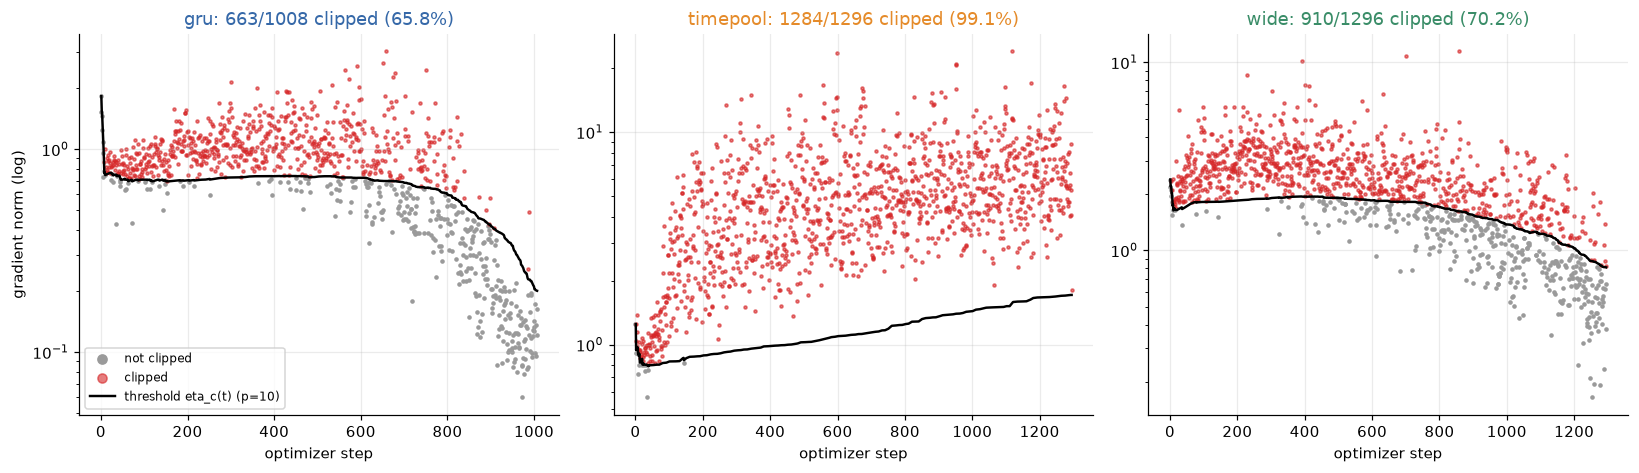

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig5_1_grad_norm_and_threshold.png')

In [29]:
# Figure 5.1: per-step gradient norm and threshold, per arm. Clipped steps in red.
fig, axs = plt.subplots(1, 3, figsize=(15, 4.4), sharey=False)
for ax, a in zip(axs, ARCHS):
    g, thr, cl = CLIP[a]["g"], CLIP[a]["thr"], CLIP[a]["clipped"]
    st = np.arange(len(g))
    ax.scatter(st[~cl], g[~cl], s=4, color="#9a9a9a", label="not clipped")
    ax.scatter(st[cl], g[cl], s=4, color="#d62728", alpha=0.6, label="clipped")
    ax.plot(st[1:], thr[1:], color="k", lw=1.6, label="threshold eta_c(t) (p=10)")
    ax.set_yscale("log"); ax.set_xlabel("optimizer step"); ax.set_title(f"{a}: {CLIP[a]['n_clip']}/{CLIP[a]['steps']} clipped ({CLIP[a]['rate']:.1%})", color=ACOL[a])
axs[0].set_ylabel("gradient norm (log)"); axs[0].legend(fontsize=8, markerscale=3)
varied("N1.5.f1", [CLIP[a]["g"] for a in ARCHS])
plt.tight_layout(); savefig(fig, "fig5_1_grad_norm_and_threshold.png")

### How to read this chart

One panel per architecture; each dot is one optimizer step, plotted at its pre-clip gradient norm on a log
axis; red dots exceeded the threshold and were clipped, grey dots did not; the black line is the running
$10$th-percentile threshold. The threshold is a **lagging, monotone-ish floor** because a percentile of a
cumulative history moves slowly. In `gru` and `wide` the norms fall over training, so the black line is
eventually *above* many of the new dots (grey dots appear mid-to-late training) and the clip rate settles at
$66$ to $70\%$. In `timepool` the norms rise after the first few hundred steps and almost every dot is red:
the threshold is pinned to the earliest small norms and clips essentially every step ($99.1\%$). Takeaway: a
high clip rate here says the percentile is low relative to the recent norm scale, not that training is unstable.
What would make this reading wrong: grey and red dots interleaved at the same height early in training,
which would indicate the rule is doing something other than tracking a history quantile.

[N1.5.f2] plotted values finite and not all identical (range 0.466) -> PASS


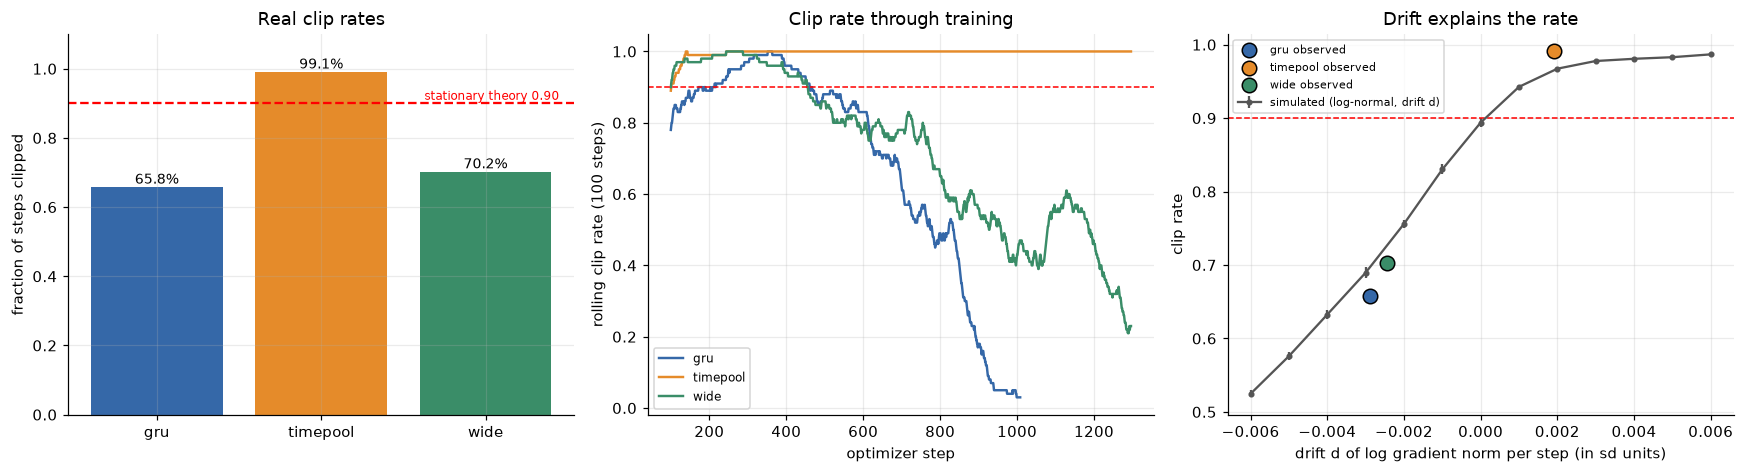

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig5_2_clip_rates.png')

In [30]:
# Figure 5.2: clip rates (bars vs stationary 0.90), rolling clip rate over 100 steps, and the drift model.
fig, axs = plt.subplots(1, 3, figsize=(16, 4.4))
rates = [CLIP[a]["rate"] for a in ARCHS]
axs[0].bar(range(3), rates, color=[ACOL[a] for a in ARCHS])
axs[0].axhline(0.9, color="r", ls="--"); axs[0].text(2.45, 0.91, "stationary theory 0.90", color="r", ha="right", fontsize=8)
for i, r_ in enumerate(rates):
    axs[0].text(i, r_ + 0.01, f"{r_:.1%}", ha="center", fontsize=9)
axs[0].set_xticks(range(3)); axs[0].set_xticklabels(ARCHS); axs[0].set_ylim(0, 1.1); axs[0].set_ylabel("fraction of steps clipped"); axs[0].set_title("Real clip rates")
for a in ARCHS:
    c_ = CLIP[a]["clipped"].astype(float); w_ = 100
    roll = np.convolve(c_, np.ones(w_) / w_, mode="valid")
    axs[1].plot(np.arange(len(roll)) + w_, roll, color=ACOL[a], lw=1.6, label=a)
axs[1].axhline(0.9, color="r", ls="--", lw=1); axs[1].set_xlabel("optimizer step"); axs[1].set_ylabel("rolling clip rate (100 steps)"); axs[1].legend(fontsize=8); axs[1].set_title("Clip rate through training")
axs[2].errorbar(D_GRID, SIM[:, 0], yerr=1.96 * SIM[:, 1], color="#555", marker="o", ms=3, label="simulated (log-normal, drift d)")
for a in ARCHS:
    axs[2].scatter(ARMD[a]["d"], ARMD[a]["obs"], s=90, color=ACOL[a], edgecolor="k", zorder=5, label=f"{a} observed")
axs[2].axhline(0.9, color="r", ls="--", lw=1); axs[2].set_xlabel("drift d of log gradient norm per step (in sd units)"); axs[2].set_ylabel("clip rate"); axs[2].legend(fontsize=7.5); axs[2].set_title("Drift explains the rate")
varied("N1.5.f2", rates, SIM[:, 0])
plt.tight_layout(); savefig(fig, "fig5_2_clip_rates.png")

### How to read this chart

Left: the three measured clip rates against the $0.90$ that stationary norms would give (red dashed).
Middle: the same rate computed over a rolling window of $100$ steps; `timepool` sits near $1$ throughout,
while `gru` and `wide` start near $0.9$ or above and sag as their norms fall. Right: the simulated
relationship between clip rate and the drift $d$ of log gradient norms (grey, with $95\%$ Monte-Carlo
error bars) and each arm's measured $(d,\ \text{rate})$ as a coloured dot. The dots lie close to the curve,
which supports the reading that *the trend of the norm decides the clip rate*, and that $p=10$ makes the
mechanism largely independent of any notion of "instability". Caution: this is a one-parameter caricature of
the norm process; it explains the *rate*, not whether clipping helped or hurt the trained model. We ran no
arm without clipping, so this notebook makes no claim about AutoClip's benefit for classification.

## 6. Calibration: temperature scaling, ECE, and MDCA

### 6.1 Temperature scaling as a one-parameter maximum-likelihood problem

Let $z_i\in\mathbb{R}^K$ be the logits of example $i$ with label $y_i$, and let $\beta=1/T>0$. The tempered
model is $p_i(\beta)=\mathrm{softmax}(\beta z_i)$, and the negative log-likelihood of the calibration set is
$$\mathrm{NLL}(\beta)=\frac1n\sum_{i=1}^n\Big[-\beta\,z_{i,y_i}+\log\sum_{j=1}^K e^{\beta z_{ij}}\Big].$$
The log-sum-exp is convex in $\beta$, so $\mathrm{NLL}$ is convex with a unique minimiser (or none, if the
data are separable). Its derivatives are
$$\mathrm{NLL}'(\beta)=\frac1n\sum_i\Big(\mathbb{E}_{p_i(\beta)}[z_i]-z_{i,y_i}\Big),\qquad
\mathrm{NLL}''(\beta)=\frac1n\sum_i\mathrm{Var}_{p_i(\beta)}(z_i)\ \ge 0 .$$
The stationarity condition $\mathrm{NLL}'(\beta^\star)=0$ is **moment matching**: the model-expected logit,
averaged over the calibration set, equals the average logit of the observed label. Near the optimum,
$$\mathrm{NLL}(1)-\mathrm{NLL}(\beta^\star)\ \approx\ \tfrac12\,\overline{V}\,(1-\beta^\star)^2,$$
with $\overline V$ the mean logit variance, so the likelihood gain from temperature scaling grows with the
*square of the distance of $T^\star$ from one*. Temperature scaling cannot change the arg-max, hence never
changes accuracy; it changes NLL, Brier score and ECE. $T^\star>1$ flattens an overconfident model and
$T^\star<1$ sharpens an underconfident one. The stored artifacts carry the fitted $T^\star$ per arm, and
the NLL and ECE before and after; they do **not** carry logits, so nothing below can re-derive $T^\star$
or bootstrap its uncertainty. Section 7 verifies the estimator itself on constructed logits.

### 6.2 ECE and its binning sensitivity

The top-label expected calibration error with $B$ equal-width confidence bins $S_1,\dots,S_B$ is
$$\mathrm{ECE}_B=\sum_{b=1}^B\frac{|S_b|}{n}\,\Big|\mathrm{acc}(S_b)-\mathrm{conf}(S_b)\Big|,$$
with $\mathrm{conf}(S_b)$ the mean top-label probability and $\mathrm{acc}(S_b)$ the fraction correct in the
bin. It depends on $B$ (more bins expose more within-bin structure but each bin is noisier), it is biased
upward at finite $n$ even for a perfectly calibrated model, and it is not the quantity temperature scaling
minimises, which is NLL. The result files record $\mathrm{ECE}_{10}$, $\mathrm{ECE}_{15}$ and
$\mathrm{ECE}_{20}$ for every arm, condition and calibration state.

In [31]:
# N1.6.1: ECE at B = 10/15/20 for every arm x condition, uncalibrated and calibrated; TS effect; the fitted temperatures.
TEMP = {a: DATA[a]["res"]["summary"]["temperature"] for a in ARCHS}
rows = []
for a in ARCHS:
    for c in CONDS:
        u, k = S(a, c, "uncalibrated"), S(a, c, "calibrated")
        rows.append({"arch": a, "cond": c, "T": TEMP[a], "ECE10_u": u["ece_10"], "ECE15_u": u["ece_15"], "ECE20_u": u["ece_20"],
                     "ECE15_cal": k["ece_15"], "dECE15(TS)": k["ece_15"] - u["ece_15"], "NLL_u": u["nll"], "NLL_cal": k["nll"], "dNLL(TS)": k["nll"] - u["nll"]})
CAL = pd.DataFrame(rows)
display(CAL.round(4).set_index(["arch", "cond"]))
check("N1.6.1a", [round(TEMP[a], 4) for a in ("gru", "timepool", "wide")] == [1.0157, 1.1097, 1.6002], f"fitted temperatures gru {TEMP['gru']:.4f}, timepool {TEMP['timepool']:.4f}, wide {TEMP['wide']:.4f}")
clean = CAL[CAL.cond == "clean"].set_index("arch")
check("N1.6.1b", (clean["dNLL(TS)"] <= 1e-9).all(), "on the clean test split TS never raises NLL (the objective it minimises, fitted on the calibration split)")
check("N1.6.1c", clean["dNLL(TS)"].idxmin() == "wide" and abs(np.log(TEMP["wide"])) > abs(np.log(TEMP["timepool"])) > abs(np.log(TEMP["gru"])),
      "clean NLL gain from TS is largest for wide, whose |ln T| is also largest (quadratic-gain law, qualitatively)")
note("N1.6.1d", f"timepool: TS lowers clean NLL ({clean.loc['timepool', 'dNLL(TS)']:+.4f}) but RAISES clean ECE_15 {clean.loc['timepool', 'ECE15_u']:.4f} -> {clean.loc['timepool', 'ECE15_cal']:.4f}: ECE and NLL are different objectives")
spread = CAL[["ECE10_u", "ECE15_u", "ECE20_u"]]
rel_spread = ((spread.max(axis=1) - spread.min(axis=1)) / spread.mean(axis=1))
print("relative spread of uncalibrated ECE across B in {10,15,20}: max =", round(float(rel_spread.max()), 3), "| median =", round(float(rel_spread.median()), 3))
orders = {c: tuple(clean[c].sort_values().index) for c in ["ECE10_u", "ECE15_u", "ECE20_u"]}
rank_same = len(set(orders.values())) == 1
note("N1.6.1e", f"clean ranking of arms by uncalibrated ECE is {'the same' if rank_same else 'NOT the same'} for B = 10, 15, 20: {list(orders['ECE15_u'])}")
check("N1.6.1f", rel_spread.max() > 0.10, f"the same model's ECE moves by up to {rel_spread.max():.0%} of its mean when only B changes: absolute ECE values are bin-count dependent")

                          T  ECE10_u  ECE15_u  ECE20_u  ECE15_cal  dECE15(TS)   NLL_u  NLL_cal  dNLL(TS)
arch     cond                                                                                           
gru      clean       1.0157   0.0263   0.0256   0.0328     0.0250     -0.0006  0.4318   0.4300   -0.0018
         gain_+10    1.0157   0.0503   0.0591   0.0591     0.0570     -0.0021  0.5747   0.5720   -0.0027
         reverb_mid  1.0157   0.0482   0.0482   0.0484     0.0465     -0.0017  0.6300   0.6266   -0.0034
         noise_10    1.0157   0.7469   0.7469   0.7469     0.7438     -0.0030  4.4671   4.4039   -0.0632
timepool clean       1.1097   0.0431   0.0408   0.0470     0.0647      0.0238  1.3758   1.3738   -0.0020
         gain_+10    1.1097   0.0612   0.0589   0.0717     0.0513     -0.0076  1.6542   1.6236   -0.0305
         reverb_mid  1.1097   0.0823   0.0823   0.0823     0.0532     -0.0291  1.8411   1.8031   -0.0381
         noise_10    1.1097   0.5594   0.5620   0.5594 

[N1.6.1a] fitted temperatures gru 1.0157, timepool 1.1097, wide 1.6002 -> PASS
[N1.6.1b] on the clean test split TS never raises NLL (the objective it minimises, fitted on the calibration split) -> PASS
[N1.6.1c] clean NLL gain from TS is largest for wide, whose |ln T| is also largest (quadratic-gain law, qualitatively) -> PASS
[N1.6.1d] timepool: TS lowers clean NLL (-0.0020) but RAISES clean ECE_15 0.0408 -> 0.0647: ECE and NLL are different objectives -> NOTE
relative spread of uncalibrated ECE across B in {10,15,20}: max = 0.254 | median = 0.009
[N1.6.1e] clean ranking of arms by uncalibrated ECE is the same for B = 10, 15, 20: ['gru', 'timepool', 'wide'] -> NOTE
[N1.6.1f] the same model's ECE moves by up to 25% of its mean when only B changes: absolute ECE values are bin-count dependent -> PASS


True

[N1.6.f1] plotted values finite and not all identical (range 0.7257) -> PASS


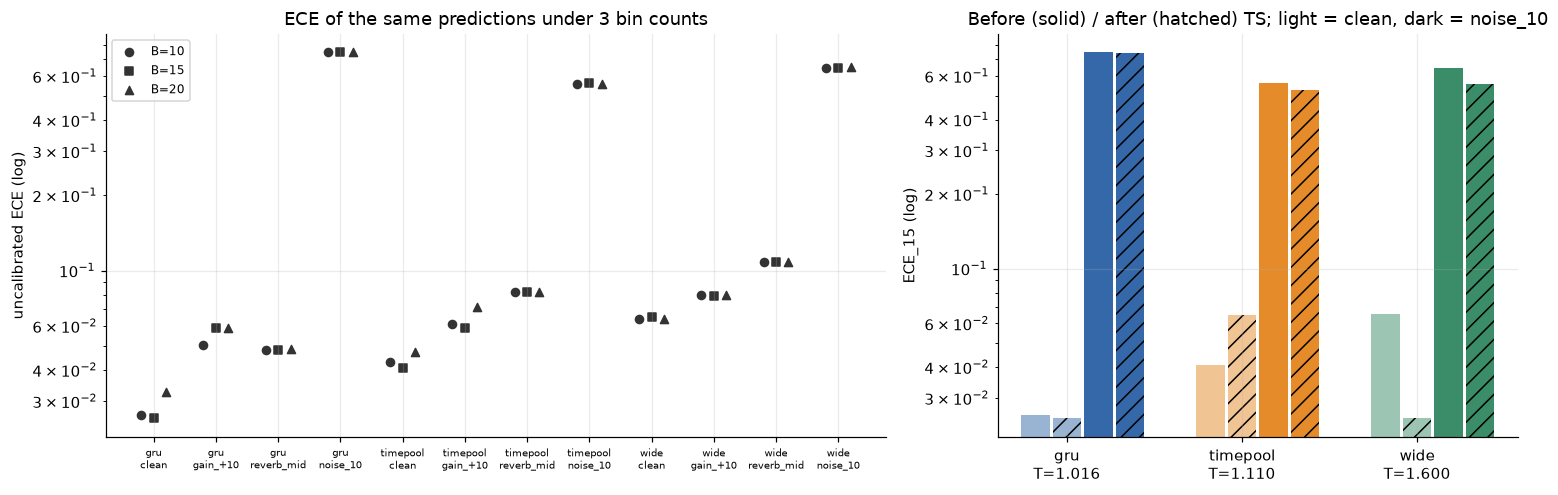

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig6_1_ece_bins_and_ts.png')

In [32]:
# Figure 6.1: ECE sensitivity to bin count, and the TS effect on ECE_15 for clean vs noise_10.
fig, axs = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
lab = [f"{a}\n{c}" for a in ARCHS for c in CONDS]
xs = np.arange(len(lab))
for col, mk, off in zip(["ECE10_u", "ECE15_u", "ECE20_u"], ["o", "s", "^"], [-0.2, 0, 0.2]):
    axs[0].scatter(xs + off, CAL[col].values, marker=mk, s=28, label=col.replace("_u", "").replace("ECE", "B="), color="#333")
axs[0].set_yscale("log"); axs[0].set_xticks(xs); axs[0].set_xticklabels(lab, fontsize=6.5); axs[0].set_ylabel("uncalibrated ECE (log)"); axs[0].legend(fontsize=8)
axs[0].set_title("ECE of the same predictions under 3 bin counts")
w = 0.36
for j, c in enumerate(["clean", "noise_10"]):
    sub = CAL[CAL.cond == c].set_index("arch").loc[ARCHS]
    axs[1].bar(np.arange(3) + (j - 0.5) * w, sub["ECE15_u"], width=w * 0.45, color=[ACOL[a] for a in ARCHS], alpha=0.5 + 0.5 * j, label=None)
    axs[1].bar(np.arange(3) + (j - 0.5) * w + w * 0.5, sub["ECE15_cal"], width=w * 0.45, color=[ACOL[a] for a in ARCHS], hatch="//", alpha=0.5 + 0.5 * j)
axs[1].set_yscale("log"); axs[1].set_xticks(np.arange(3)); axs[1].set_xticklabels([f"{a}\nT={TEMP[a]:.3f}" for a in ARCHS])
axs[1].set_ylabel("ECE_15 (log)"); axs[1].set_title("Before (solid) / after (hatched) TS; light = clean, dark = noise_10")
varied("N1.6.f1", CAL[["ECE10_u", "ECE15_u", "ECE20_u", "ECE15_cal"]].values)
plt.tight_layout(); savefig(fig, "fig6_1_ece_bins_and_ts.png")

### How to read this chart

Left: for each of the twelve arm-and-condition pairs, the uncalibrated ECE computed with $10$, $15$ and $20$
bins (three markers per column, log axis). Where the markers stack, the choice of $B$ does not matter; where
they spread, it does. On the noise conditions the three markers nearly coincide at very high values, which suggests the
confidences are concentrated in few bins. On the clean condition, where ECE is a few percent, the same model
can differ visibly between bin counts, which is why ECE differences of a percentage point between models
should not be over-read. Right: ECE$_{15}$ before (solid) and after (hatched) temperature scaling, light bars
for `clean` and dark bars for `noise_10`, with each arm's fitted $T$ in the axis label. `wide`, with $T=1.60$,
gets a large ECE reduction on `clean`; `gru`, with $T=1.016$, barely moves; `timepool`'s clean ECE *rises*.
On `noise_10` every arm stays at ECE near $0.5$ to $0.75$ after scaling: a temperature fitted on clean data
cannot repair a shifted distribution.

### 6.3 MDCA: the formula, the reported numbers, and what it does and does not guarantee

(Hebbalaguppe et al., arXiv:2203.13834; turns 7 and 8.) MDCA is an auxiliary loss added to a primary loss
(cross-entropy or focal). With $K$ classes and a minibatch of $N_b$ examples, $s_i[j]$ the softmax
probability of class $j$ for example $i$ and $q_i[j]\in\{0,1\}$ the one-hot ground truth,
$$\mathcal{L}_{\mathrm{MDCA}}=\frac1K\sum_{j=1}^K\left|\frac1{N_b}\sum_{i=1}^{N_b}s_i[j]-\frac1{N_b}\sum_{i=1}^{N_b}q_i[j]\right| .$$
It compares, for each class, the batch-average predicted probability with the batch frequency of that class,
needs no bins, and is differentiable almost everywhere:
$\partial\mathcal{L}_{\mathrm{MDCA}}/\partial s_i[j]=\frac{1}{KN_b}\mathrm{sign}(\bar s_j-\bar q_j)$, i.e. it nudges all
examples' probability of class $j$ down by an equal amount when class $j$ is over-predicted on the batch, and up
when under-predicted. On PASCAL-VOC 2012 with DeepLabV3+ and an Xception65 backbone the paper reports:

| training loss | post-hoc temperature scaling | ECE (%) |
|---|---|---|
| NLL | no | 7.77 |
| NLL | yes | 6.10 |
| focal loss | no | 7.69 |
| focal loss + MDCA | no | 4.66 |

The improvement of FL + MDCA over post-hoc scaling is $(6.10-4.66)/6.10=23.6\%$ relative. The paper also
tests composition and reports that **MDCA does not compose with temperature scaling**: scaling after MDCA
training leaves calibration unchanged or slightly degraded, because the optimal temperature found after MDCA
training is $T\approx1$ (turn 8).

**A note on what MDCA-zero means.** The loss is zero when, for every class, the batch mean probability equals
the class frequency. That is a *marginal* (class-average) condition. It is weaker than the temperature
stationarity $\mathrm{NLL}'(\beta^\star)=0$ and weaker than top-label calibration. So "$T^\star\approx1$ after
MDCA training" is the paper's *empirical* finding for FL + MDCA, where the focal or cross-entropy term is
still present, and not a consequence of the MDCA term alone. The fixture below makes that concrete.

In [33]:
# N1.6.2: MDCA as code, and a FIXTURE showing MDCA = 0 does not imply calibration or T* = 1.
from src.calibration import temperature_scale
from src.metrics import expected_calibration_error
def mdca(probs, labels):
    K = probs.shape[1]; q = np.eye(K)[labels]
    return float(np.mean(np.abs(probs.mean(0) - q.mean(0))))
def softmax_(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

rngm = np.random.default_rng(RNG_SEED + 62)
Kc, n_fx = 3, 3000
y_fx2 = np.repeat(np.arange(Kc), n_fx // Kc)
# Fixture A: overconfident and uninformative -- predicted class uniform at random, independent of the label.
pred = rngm.integers(0, Kc, n_fx)
zA = np.full((n_fx, Kc), 0.0); zA[np.arange(n_fx), pred] = 8.0
pA = softmax_(zA)
# Fixture B: informative, calibrated by construction (beta = 2 for a unit mean shift), then over-sharpened by a factor 1.6.
zB = 1.6 * 2.0 * (2.0 * np.eye(Kc)[y_fx2] + rngm.standard_normal((n_fx, Kc)))
pB = softmax_(zB)
lossA, lossB = mdca(pA, y_fx2), mdca(pB, y_fx2)
eceA, eceB = expected_calibration_error(pA, y_fx2, bins=15), expected_calibration_error(pB, y_fx2, bins=15)
TA, TB = temperature_scale(zA, y_fx2), temperature_scale(zB, y_fx2)
print(f"fixture A (overconfident, label-independent): MDCA={lossA:.4f}  ECE_15={eceA:.3f}  acc={np.mean(pA.argmax(1) == y_fx2):.3f}  fitted T*={TA:.2f}")
print(f"fixture B (informative, over-sharpened by 1.6)   : MDCA={lossB:.4f}  ECE_15={eceB:.3f}  acc={np.mean(pB.argmax(1) == y_fx2):.3f}  fitted T*={TB:.2f}")
ref = float(np.mean([abs(pA[:, j].mean() - (y_fx2 == j).mean()) for j in range(Kc)]))
check("N1.6.2a", abs(lossA - ref) < 1e-12, "MDCA implementation equals the explicit (1/K) sum_j |mean s[j] - mean q[j]|")
check("N1.6.2b", lossA < 0.03 and eceA > 0.5, f"fixture A: MDCA = {lossA:.4f} (near 0) while ECE_15 = {eceA:.2f}: MDCA-zero does not imply calibration")
check("N1.6.2c", TA > 2.5, f"fixture A: post-hoc temperature would still be T* = {TA:.2f}, far from 1: MDCA-zero does not imply T* = 1")
check("N1.6.2d", lossB < 0.03 and 1.4 < TB < 1.8, f"fixture B: an informative but over-sharpened model has small MDCA ({lossB:.3f}) and T* = {TB:.2f}, close to the built-in 1.6")
check("N1.6.2e", abs((6.10 - 4.66) / 6.10 - 0.236) < 5e-4, f"relative improvement of FL+MDCA over NLL+TS = {(6.10 - 4.66) / 6.10:.4f} = 23.6% (paper)")
PASCAL = {"NLL": 7.77, "NLL + TS": 6.10, "focal": 7.69, "focal + MDCA": 4.66}
note("N1.6.2f", f"paper: MDCA vs plain NLL baseline is {(7.77 - 4.66) / 7.77:.1%} relative; the 23.6% figure is against the stronger post-hoc-TS comparator")

fixture A (overconfident, label-independent): MDCA=0.0082  ECE_15=0.672  acc=0.327  fitted T*=148.41
fixture B (informative, over-sharpened by 1.6)   : MDCA=0.0044  ECE_15=0.052  acc=0.868  fitted T*=1.59
[N1.6.2a] MDCA implementation equals the explicit (1/K) sum_j |mean s[j] - mean q[j]| -> PASS
[N1.6.2b] fixture A: MDCA = 0.0082 (near 0) while ECE_15 = 0.67: MDCA-zero does not imply calibration -> PASS
[N1.6.2c] fixture A: post-hoc temperature would still be T* = 148.41, far from 1: MDCA-zero does not imply T* = 1 -> PASS
[N1.6.2d] fixture B: an informative but over-sharpened model has small MDCA (0.004) and T* = 1.59, close to the built-in 1.6 -> PASS
[N1.6.2e] relative improvement of FL+MDCA over NLL+TS = 0.2361 = 23.6% (paper) -> PASS
[N1.6.2f] paper: MDCA vs plain NLL baseline is 40.0% relative; the 23.6% figure is against the stronger post-hoc-TS comparator -> NOTE


argmin T: NLL 1.593 | Brier 1.560 | ECE_15 1.627   (built-in over-sharpening factor 1.6, fitted src T* 1.588)
[N1.6.3a] temperature scaling never changes accuracy (argmax is invariant to T) -> PASS
[N1.6.3b] grid argmin of NLL (1.593) matches src.calibration.temperature_scale (1.588) and the built-in 1.6 -> PASS
[N1.6.3c] Brier is minimised at a nearby but not identical temperature (1.560 vs 1.593): both proper, different curvature -> PASS
[N1.6.3d] ECE_15 is minimised at T = 1.627, NLL at 1.593: the ECE curve is flat and noisy near its floor, so minimising ECE is a poorly conditioned target -> NOTE
[N1.6.f3] plotted values finite and not all identical (range 0.4665) -> PASS


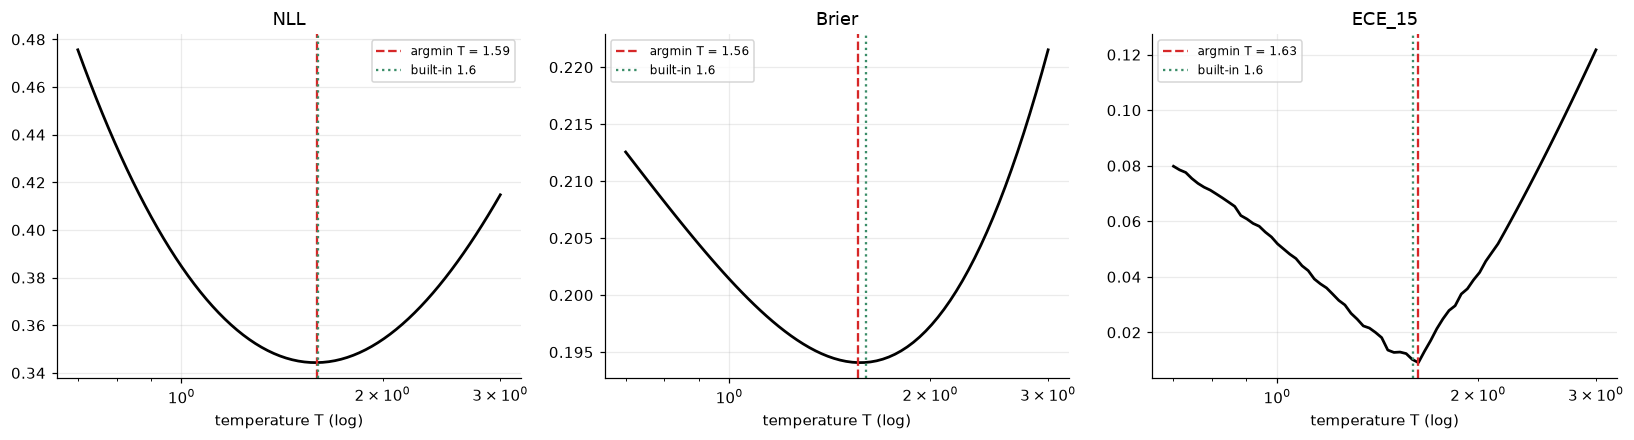

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig6_3_objective_optima.png')

In [34]:
# N1.6.3: different objectives, different optimal temperatures (FIXTURE B logits from N1.6.2; true T0 = 1.6 by construction).
Ts = np.exp(np.linspace(np.log(0.7), np.log(3.0), 70))
acc_T, nll_T, br_T, ece_T = [], [], [], []
for T_ in Ts:
    pT = softmax_(zB / T_)
    acc_T.append(np.mean(pT.argmax(1) == y_fx2)); nll_T.append(float(-np.log(pT[np.arange(n_fx), y_fx2]).mean()))
    br_T.append(float(((pT - np.eye(Kc)[y_fx2]) ** 2).sum(1).mean())); ece_T.append(expected_calibration_error(pT, y_fx2, bins=15))
acc_T, nll_T, br_T, ece_T = map(np.array, (acc_T, nll_T, br_T, ece_T))
T_nll, T_br, T_ece = Ts[nll_T.argmin()], Ts[br_T.argmin()], Ts[ece_T.argmin()]
print(f"argmin T: NLL {T_nll:.3f} | Brier {T_br:.3f} | ECE_15 {T_ece:.3f}   (built-in over-sharpening factor 1.6, fitted src T* {TB:.3f})")
check("N1.6.3a", float(np.ptp(acc_T)) == 0.0, "temperature scaling never changes accuracy (argmax is invariant to T)")
check("N1.6.3b", abs(T_nll - TB) < 0.06 and abs(T_nll - 1.6) < 0.15, f"grid argmin of NLL ({T_nll:.3f}) matches src.calibration.temperature_scale ({TB:.3f}) and the built-in 1.6")
check("N1.6.3c", abs(T_br - T_nll) < 0.3, f"Brier is minimised at a nearby but not identical temperature ({T_br:.3f} vs {T_nll:.3f}): both proper, different curvature")
note("N1.6.3d", f"ECE_15 is minimised at T = {T_ece:.3f}, NLL at {T_nll:.3f}: the ECE curve is flat and noisy near its floor, so minimising ECE is a poorly conditioned target")
fig, axs = plt.subplots(1, 3, figsize=(15, 4.1))
for ax, y_, ttl, tb in zip(axs, [nll_T, br_T, ece_T], ["NLL", "Brier", "ECE_15"], [T_nll, T_br, T_ece]):
    ax.plot(Ts, y_, color="k", lw=1.8); ax.axvline(tb, color="#d62728", ls="--", label=f"argmin T = {tb:.2f}"); ax.axvline(1.6, color=ACOL["wide"], ls=":", label="built-in 1.6")
    ax.set_xscale("log"); ax.set_xlabel("temperature T (log)"); ax.set_title(ttl); ax.legend(fontsize=8)
varied("N1.6.f3", nll_T, br_T, ece_T)
plt.tight_layout(); savefig(fig, "fig6_3_objective_optima.png")

### How to read this chart

One panel per calibration objective, each a function of temperature $T$ on a constructed, informative,
deliberately over-sharpened classifier (a fixture; the true temperature is $1.6$, green dotted). Red dashed
lines mark each objective's minimiser. NLL, the objective that temperature scaling fits, has a smooth bowl
with its minimum near $1.6$. Brier has its minimum nearby but not at exactly the same place. ECE has a much
flatter valley with a jagged floor of binning noise, so its minimiser is poorly determined. This is the
reason Section 6 found that scaling can lower NLL while raising ECE for `timepool`: the two are different
targets, and a train-time term such as MDCA that acts on class-average probabilities is a third. Accuracy
(checked, not plotted) is constant across all $T$.

[N1.6.f2] plotted values finite and not all identical (range 6.754) -> PASS


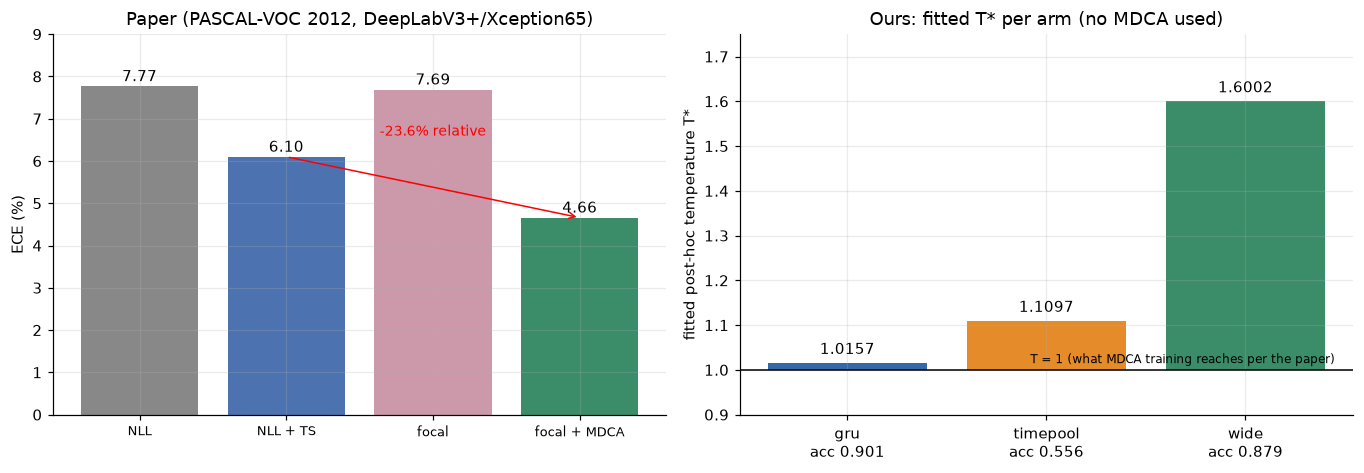

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig6_2_mdca_and_temperatures.png')

In [35]:
# Figure 6.2: PASCAL-VOC numbers from the paper, and the fitted temperatures of our three arms against T = 1.
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.4))
names = list(PASCAL); vals = [PASCAL[k] for k in names]
bars = axs[0].bar(range(4), vals, color=["#888", "#4c72b0", "#c9a", "#3A8D68"])
for i, v in enumerate(vals):
    axs[0].text(i, v + 0.12, f"{v:.2f}", ha="center")
axs[0].annotate("", xy=(3, 4.66), xytext=(1, 6.10), arrowprops=dict(arrowstyle="->", color="r"))
axs[0].text(2.0, 6.6, "-23.6% relative", color="r", ha="center", fontsize=9)
axs[0].set_xticks(range(4)); axs[0].set_xticklabels(names, fontsize=8.5); axs[0].set_ylabel("ECE (%)"); axs[0].set_ylim(0, 9)
axs[0].set_title("Paper (PASCAL-VOC 2012, DeepLabV3+/Xception65)")
tv = [TEMP[a] for a in ARCHS]
axs[1].bar(range(3), np.array(tv) - 1.0, bottom=1.0, color=[ACOL[a] for a in ARCHS])
axs[1].axhline(1.0, color="k", lw=1); axs[1].text(2.45, 1.015, "T = 1 (what MDCA training reaches per the paper)", ha="right", fontsize=8)
for i, v in enumerate(tv):
    axs[1].text(i, v + 0.02, f"{v:.4f}", ha="center")
axs[1].set_xticks(range(3)); axs[1].set_xticklabels([f"{a}\nacc {SUMM.loc[a, 'acc@best_epoch']:.3f}" for a in ARCHS]); axs[1].set_ylim(0.9, 1.75)
axs[1].set_ylabel("fitted post-hoc temperature T*"); axs[1].set_title("Ours: fitted T* per arm (no MDCA used)")
varied("N1.6.f2", vals, tv)
plt.tight_layout(); savefig(fig, "fig6_2_mdca_and_temperatures.png")

### How to read this chart

Left: the paper's four ECE values on PASCAL-VOC, as bars, with the $23.6\%$ relative reduction of
FL + MDCA over NLL + temperature scaling as the red arrow. These are the paper's numbers, for a
semantic-segmentation task, and are shown for scale; they are not comparable to our ECE values, which are
for 12-way clip classification. Right: our own fitted temperatures, one per architecture, as bars anchored at
$T=1$ (the black line, where the paper says MDCA training leaves the optimal temperature). `gru` ($1.0157$) is
essentially on the line, `timepool` ($1.1097$) a little above it, and `wide` ($1.6002$) far above. No arm was
trained with MDCA here.

### 6.4 An observation worth testing, and no more

**The observation.** The paper's mechanism of interest is that a train-time objective can make the optimal
post-hoc temperature approach $1$. Our best model, `gru`, already has $T^\star=1.0157$ with *no* train-time
calibration objective; our worst-calibrated (on clean data) model, `wide`, needs $T^\star=1.6002$, and scaling
cuts its clean ECE$_{15}$ from $0.0652$ to $0.0248$. If a train-time calibration term were added to
`wide`, the paper's account predicts its $T^\star$ should fall toward $1$; for `gru` it predicts little
change, because there is little to remove.

**Why this is not a result.** (i) One training run per arm: $T^\star$ carries seed noise we cannot estimate.
(ii) $T^\star$ was fitted on a single calibration split of $1080$ clips; logits are not stored, so it cannot be
bootstrapped here. (iii) `gru`'s temperature is near $1$ on *clean* data only: on `noise_10` its calibrated
NLL is still $4.404$, worse than a uniform predictor ($\ln12=2.485$), so "nearly calibrated in distribution"
must not be read as "calibrated". (iv) Accuracy and calibration are entangled: `gru` is also the most
accurate arm, and better-separated logits change $T^\star$ for reasons unrelated to any calibration
objective. (v) A relation between fitted $T^\star$ and a training objective that we did not train is a
hypothesis about a counterfactual. **The test that would settle it:** train `gru` and `wide` at several
seeds with and without an MDCA term and record $|\ln T^\star|$ on the same calibration split; the paper's
account predicts a drop for `wide` and no change for `gru`.

## 7. Salvaged derivations: scoring rules, ECE bias, temperature-scaling MLE, conformal risk control

This section keeps the mathematics of the earlier foundations notebook that was worth keeping and drops its
synthetic-data framing. Each derivation is followed by a numerical check against either an independent
implementation or the project's own `src` functions. The constructed inputs are **estimator-verification
fixtures**: they test that a formula or an estimator does what its derivation says. They are not evidence
about speech models and are labelled as fixtures at each cell.

### 7.1 Proper scoring rules: NLL and Brier

For a $K$-class prediction $p\in\Delta^{K-1}$ and a label $y$, the logarithmic score (NLL) and the multiclass
Brier score are
$$\ell_{\log}(p,y)=-\log p_y,\qquad \ell_{\mathrm{Br}}(p,y)=\lVert p-e_y\rVert_2^2=\sum_{j}(p_j-\mathbb{1}\{j=y\})^2 .$$
Suppose the label is drawn from a true distribution $q$. Then the expected scores decompose as
$$\mathbb{E}_{y\sim q}\,\ell_{\log}(p,y)=H(q)+\mathrm{KL}(q\,\Vert\,p),$$
$$\mathbb{E}_{y\sim q}\,\ell_{\mathrm{Br}}(p,y)=\lVert p-q\rVert_2^2+\big(1-\lVert q\rVert_2^2\big).$$
The first is the usual entropy-plus-KL identity: $\sum_y q_y(-\log p_y)=-\sum_y q_y\log q_y+\sum_y q_y\log(q_y/p_y)$.
For the second, $\mathbb{E}\lVert p-e_y\rVert^2=\lVert p\rVert^2-2p^\top q+1=\lVert p-q\rVert^2+1-\lVert q\rVert^2$.
In both, the second term does not depend on $p$ and the first is non-negative and zero only at $p=q$:
both rules are **strictly proper**, minimised in expectation by reporting the truth. A uniform predictor scores
$\ln K$ (NLL) and $1-1/K$ (Brier); the Brier score lies in $[0,2]$ while NLL is unbounded above, which is why a
single confidently wrong prediction dominates NLL and only bounds Brier.

[N1.7.1a] E[NLL] = H(q) + KL(q||p) on all simplex grid points -> PASS
[N1.7.1b] E[Brier] = ||p - q||^2 + 1 - ||q||^2 on all grid points -> PASS
[N1.7.1c] both expected scores are minimised at p = q (argmins [0.5 0.3 0.2], [0.5 0.3 0.2]) -> PASS
[N1.7.1d] own NLL and Brier equal src.metrics.nll / brier_score -> PASS
[N1.7.1e] uniform predictor: NLL = ln K = 1.6094, Brier = 1 - 1/K = 0.80 -> PASS
[N1.7.f1] plotted values finite and not all identical (range 21.48) -> PASS


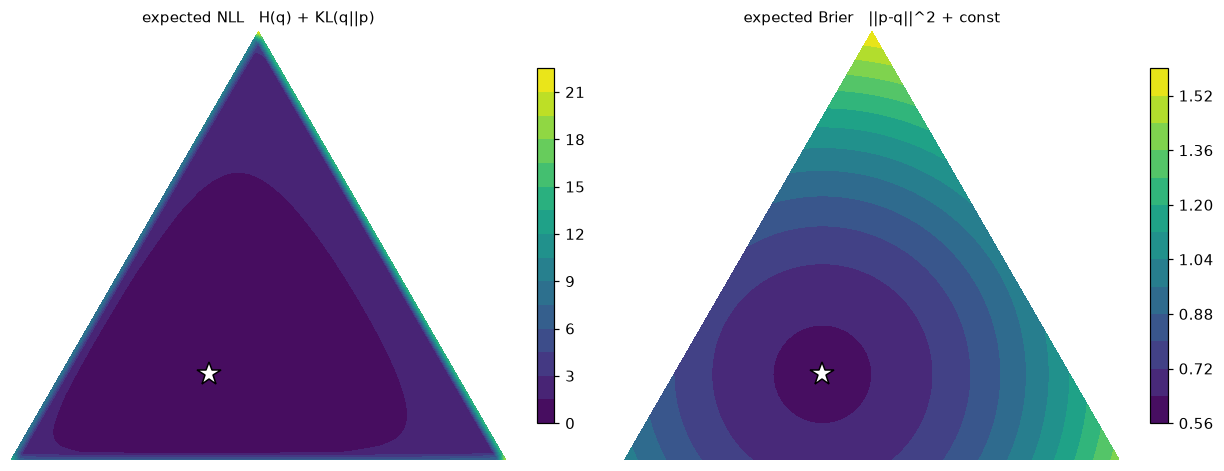

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig7_1_scoring_rules.png')

In [36]:
# N1.7.1: expected NLL and Brier on the 3-class simplex (FIXTURE q = (0.5, 0.3, 0.2)); identities; agreement with src.metrics.
from src.metrics import nll as src_nll, brier_score as src_brier
q3 = np.array([0.5, 0.3, 0.2]); m_ = 60
P3 = np.array([(i / m_, j / m_, (m_ - i - j) / m_) for i in range(m_ + 1) for j in range(m_ + 1 - i)])
P3c = np.clip(P3, 1e-12, 1.0)
e_nll = -(q3 * np.log(P3c)).sum(1)
e_br = (P3 ** 2).sum(1) - 2 * (P3 @ q3) + 1
Hq = -(q3 * np.log(q3)).sum(); KL = (q3 * np.log(q3 / P3c)).sum(1)
check("N1.7.1a", np.allclose(e_nll, Hq + KL), "E[NLL] = H(q) + KL(q||p) on all simplex grid points")
check("N1.7.1b", np.allclose(e_br, ((P3 - q3) ** 2).sum(1) + 1 - (q3 ** 2).sum()), "E[Brier] = ||p - q||^2 + 1 - ||q||^2 on all grid points")
i_n, i_b = int(np.argmin(e_nll)), int(np.argmin(e_br))
check("N1.7.1c", np.allclose(P3[i_n], q3) and np.allclose(P3[i_b], q3), f"both expected scores are minimised at p = q (argmins {P3[i_n]}, {P3[i_b]})")
rngs = np.random.default_rng(RNG_SEED + 71)
Kp, np_ = 5, 800
logits_ = rngs.standard_normal((np_, Kp)) * 2; pr_ = np.exp(logits_) / np.exp(logits_).sum(1, keepdims=True); yl_ = rngs.integers(0, Kp, np_)
own_nll = float(-np.log(pr_[np.arange(np_), yl_]).mean()); own_br = float(((pr_ - np.eye(Kp)[yl_]) ** 2).sum(1).mean())
check("N1.7.1d", abs(own_nll - src_nll(pr_, yl_)) < 1e-12 and abs(own_br - src_brier(pr_, yl_)) < 1e-12, "own NLL and Brier equal src.metrics.nll / brier_score")
uni = np.full((10, Kp), 1 / Kp)
check("N1.7.1e", abs(src_nll(uni, np.arange(10) % Kp) - np.log(Kp)) < 1e-12 and abs(src_brier(uni, np.arange(10) % Kp) - (1 - 1 / Kp)) < 1e-12, f"uniform predictor: NLL = ln K = {np.log(Kp):.4f}, Brier = 1 - 1/K = {1 - 1 / Kp:.2f}")
bx = 0.5 * (2 * P3[:, 1] + P3[:, 2]); by = (np.sqrt(3) / 2) * P3[:, 2]
fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.6))
for ax, val, ttl in zip(axs, [e_nll, e_br], ["expected NLL   H(q) + KL(q||p)", "expected Brier   ||p-q||^2 + const"]):
    tc = ax.tricontourf(bx, by, val, levels=14, cmap="viridis")
    ax.plot(*[0.5 * (2 * q3[1] + q3[2]), (np.sqrt(3) / 2) * q3[2]], marker="*", ms=16, color="w", mec="k"); ax.set_aspect("equal"); ax.set_axis_off()
    ax.set_title(ttl, fontsize=10); fig.colorbar(tc, ax=ax, shrink=0.75)
varied("N1.7.f1", e_nll, e_br)
plt.tight_layout(); savefig(fig, "fig7_1_scoring_rules.png")

### How to read this chart

Each panel is the probability simplex for $K=3$ (a triangle whose corners are the one-hot predictions),
coloured by the *expected* score of reporting the prediction at that point when the true label distribution is
$q=(0.5,0.3,0.2)$, marked by the white star. Both surfaces are bowl-shaped with their minimum at the star,
which is what "strictly proper" means: no other report scores better in expectation. The NLL surface rises
steeply towards the edges and corners (it is unbounded there), while the Brier surface is a bounded
quadratic bowl; that is the practical difference between the two rules. What would make the reading wrong:
a minimum anywhere except the star. The fixture $q$ is chosen for legibility and has no connection with the
speech data.

### 7.2 ECE: finite-sample bias and its dependence on the number of bins

Write $\mathrm{conf}_i$ for the top-label probability and $c_i=\mathbb{1}\{\hat y_i=y_i\}$ for correctness. The
binned estimator has the exact identity
$$\widehat{\mathrm{ECE}}_B=\sum_{b=1}^B\frac{|S_b|}{n}\big|\bar c_b-\overline{\mathrm{conf}}_b\big|=\frac1n\sum_{b=1}^B\Big|\sum_{i\in S_b}\big(c_i-\mathrm{conf}_i\big)\Big| .$$
For a **perfectly calibrated** model, $c_i\sim\mathrm{Bernoulli}(\mathrm{conf}_i)$, so each inner sum has mean
zero and variance $\sum_{i\in S_b}\mathrm{conf}_i(1-\mathrm{conf}_i)\approx n_b\,v_b$ with $v_b$ the mean of
$\mathrm{conf}(1-\mathrm{conf})$ in the bin. Its absolute value is approximately half-normal, with mean
$\sqrt{2/\pi}\sqrt{n_bv_b}$, hence
$$\mathbb{E}\,\widehat{\mathrm{ECE}}_B\ \approx\ \sqrt{\tfrac{2}{\pi}}\ \frac{1}{n}\sum_{b}\sqrt{n_b\,v_b}\ \asymp\ \sqrt{\frac{B_{\mathrm{eff}}}{n}},$$
where $B_{\mathrm{eff}}$ is the number of occupied bins. Two consequences: the estimator is **positive even
for a perfect model** (bias of order $\sqrt{B/n}$), and it **grows with $\sqrt B$**, which is the mechanism
behind the bin-count dependence seen in Section 6. For confidences spread uniformly over $[0.5,1]$, $n=1080$ and $B=15$ the bias is about $0.027$; it is smaller when
confidences pile up near $1$, where $\mathrm{conf}(1-\mathrm{conf})$ is small, so this is an upper-end reference for
our arms' clean ECE values ($0.026$ to $0.065$), not a measurement of their floor.

[N1.7.2a] vectorised ECE equals src.metrics.expected_calibration_error on a constructed draw -> PASS
B=10: n=100: MC 0.0730 (theory 0.0707)  n=300: MC 0.0418 (theory 0.0408)  n=1000: MC 0.0219 (theory 0.0224)  n=3000: MC 0.0129 (theory 0.0129)  n=10000: MC 0.0075 (theory 0.0071)
B=15: n=100: MC 0.0888 (theory 0.0893)  n=300: MC 0.0512 (theory 0.0515)  n=1000: MC 0.0282 (theory 0.0282)  n=3000: MC 0.0168 (theory 0.0163)  n=10000: MC 0.0092 (theory 0.0089)
B=20: n=100: MC 0.1007 (theory 0.0994)  n=300: MC 0.0579 (theory 0.0574)  n=1000: MC 0.0316 (theory 0.0314)  n=3000: MC 0.0186 (theory 0.0182)  n=10000: MC 0.0100 (theory 0.0099)
[N1.7.2b] ECE of a perfect model falls like n^(-1/2): log-log slopes B=10: -0.463, B=15: -0.488, B=20: -0.502 -> PASS
[N1.7.2c] half-normal prediction matches Monte Carlo within 6.6% for n >= 1000 -> PASS
[N1.7.2d] at n=1000 a perfect model has ECE 0.0219 (B=10) < 0.0316 (B=20): more bins, more bias -> PASS
[N1.7.2e] with confidences uniform on [0.5, 1] (a del

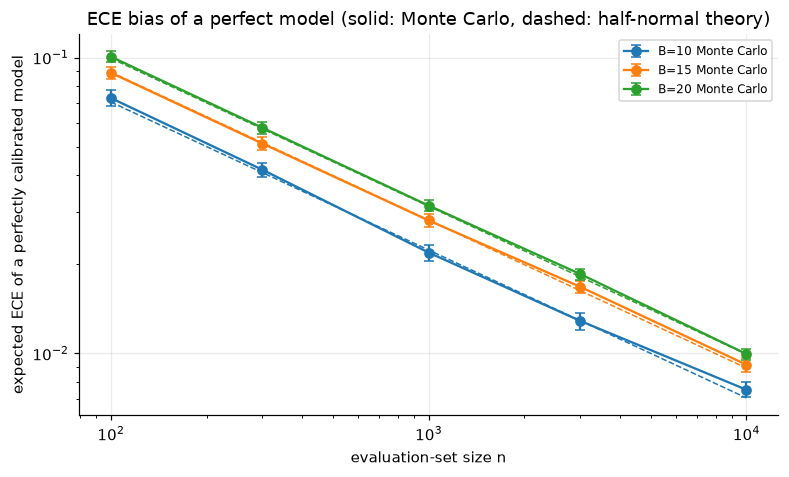

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig7_2_ece_bias.png')

In [37]:
# N1.7.2: Monte-Carlo ECE of a PERFECTLY calibrated model (FIXTURE: conf ~ U(0.5,1), correct ~ Bernoulli(conf)) vs the half-normal prediction.
from src.metrics import expected_calibration_error as src_ece
def ece_batch(conf, corr, B):
    idx = np.minimum((conf * B).astype(int), B - 1); tot = np.zeros(conf.shape[0])
    for b in range(B):
        m = idx == b
        tot += np.abs(((corr - conf) * m).sum(1))
    return tot / conf.shape[1]
def ece_theory(n, B, lo=0.5):
    edges = np.linspace(0, 1, B + 1); tot = 0.0
    for b in range(B):
        a_, c_ = max(edges[b], lo), edges[b + 1]
        if c_ <= a_: continue
        nb = n * (c_ - a_) / (1 - lo); mid = 0.5 * (a_ + c_); v = mid * (1 - mid)
        tot += np.sqrt(nb * v)
    return np.sqrt(2 / np.pi) * tot / n
NS = np.array([100, 300, 1000, 3000, 10000]); BS = [10, 15, 20]; R = 120
rngE = np.random.default_rng(RNG_SEED + 72)
MCE = {}
for B in BS:
    for n in NS:
        conf = rngE.uniform(0.5, 1.0, (R, n)); corr = (rngE.uniform(size=(R, n)) < conf).astype(float)
        v = ece_batch(conf, corr, B); MCE[(B, n)] = (v.mean(), v.std(ddof=1) / np.sqrt(R))
conf1 = rngE.uniform(0.5, 1.0, (1, 400)); corr1 = (rngE.uniform(size=(1, 400)) < conf1).astype(float)
pr2 = np.stack([conf1[0], 1 - conf1[0]], 1); lab2 = np.where(corr1[0] == 1, 0, 1)
check("N1.7.2a", abs(ece_batch(conf1, corr1, 15)[0] - src_ece(pr2, lab2, bins=15)) < 1e-12, "vectorised ECE equals src.metrics.expected_calibration_error on a constructed draw")
for B in BS:
    print(f"B={B:2d}: " + "  ".join(f"n={n}: MC {MCE[(B, n)][0]:.4f} (theory {ece_theory(n, B):.4f})" for n in NS))
slopes = {B: np.polyfit(np.log(NS[2:]), np.log([MCE[(B, n)][0] for n in NS[2:]]), 1)[0] for B in BS}
check("N1.7.2b", all(abs(s + 0.5) < 0.08 for s in slopes.values()), f"ECE of a perfect model falls like n^(-1/2): log-log slopes {', '.join(f'B={B}: {s:.3f}' for B, s in slopes.items())}")
rel = [abs(MCE[(B, n)][0] / ece_theory(n, B) - 1) for B in BS for n in NS[2:]]
check("N1.7.2c", max(rel) < 0.15, f"half-normal prediction matches Monte Carlo within {max(rel):.1%} for n >= 1000")
check("N1.7.2d", MCE[(20, 1000)][0] > MCE[(10, 1000)][0], f"at n=1000 a perfect model has ECE {MCE[(10, 1000)][0]:.4f} (B=10) < {MCE[(20, 1000)][0]:.4f} (B=20): more bins, more bias")
note("N1.7.2e", f"with confidences uniform on [0.5, 1] (a deliberately spread fixture) the bias of a PERFECT model at n=1080, B=15 is about {ece_theory(1080, 15):.4f}; models with confidences concentrated near 1 have a smaller floor because conf(1-conf) is small there")
fig, ax = plt.subplots(figsize=(8.2, 4.5))
for B, c_ in zip(BS, ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    ax.errorbar(NS, [MCE[(B, n)][0] for n in NS], yerr=[1.96 * MCE[(B, n)][1] for n in NS], marker="o", color=c_, capsize=3, label=f"B={B} Monte Carlo")
    ax.plot(NS, [ece_theory(n, B) for n in NS], ls="--", color=c_, lw=1)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("evaluation-set size n"); ax.set_ylabel("expected ECE of a perfectly calibrated model")
ax.legend(fontsize=8); ax.set_title("ECE bias of a perfect model (solid: Monte Carlo, dashed: half-normal theory)")
varied("N1.7.f2", [MCE[k][0] for k in MCE])
savefig(fig, "fig7_2_ece_bias.png")

### How to read this chart

The vertical axis is the average ECE that a model with *exactly zero* miscalibration would be measured to have,
as the evaluation set grows (horizontal axis, log). Solid lines with whiskers are Monte-Carlo averages
($120$ repetitions, $95\%$ intervals) for three bin counts; dashed lines are the half-normal formula of
Section 7.2. They agree closely and fall with slope $-1/2$ on the log-log axes, and the $B=20$ line lies above
the $B=10$ line at every $n$. Two lessons. First, ECE measured on a few hundred to a thousand examples is
dominated by this noise floor unless the true miscalibration is comfortably larger, so small ECE
differences between models are weak evidence. Second, ECE values from different bin counts are not
interchangeable. The construction (uniform confidences on $[0.5,1]$) is a fixture chosen so that the answer
is known; it is not a model of our classifiers' confidence distributions.

### 7.3 Temperature scaling as maximum likelihood: consistency and a variance formula

Section 6.1 gave $\mathrm{NLL}'(\beta)$ and $\mathrm{NLL}''(\beta)$. Newton's method on the convex,
one-dimensional problem is
$$\beta_{k+1}=\beta_k-\frac{\mathrm{NLL}'(\beta_k)}{\mathrm{NLL}''(\beta_k)},\qquad
\mathrm{NLL}'(\beta)=\overline{\mathbb{E}_{p(\beta)}[z]-z_y},\quad \mathrm{NLL}''(\beta)=\overline{\mathrm{Var}_{p(\beta)}(z)} .$$
If labels truly follow $y\mid z\sim\mathrm{softmax}(\beta_0z)$, the maximum-likelihood estimator is consistent for
$\beta_0$, and by the usual likelihood theory
$$\sqrt n\,(\hat\beta-\beta_0)\ \xrightarrow{d}\ \mathcal N\!\big(0,\ 1/\overline V\big),\qquad \overline V=\mathbb{E}\big[\mathrm{Var}_{p(\beta_0)}(z)\big],$$
so $\mathrm{SE}(\hat\beta)\approx 1/\sqrt{n\overline V}$: fitting a *single* temperature is a very
well-determined problem whenever the logits have spread. The fixture below draws logits, samples labels from a
known temperature $T_0=1.6$ (which is the value fitted for our `wide` arm, chosen only for familiarity), and
checks consistency, the variance formula, and agreement with `src.calibration.temperature_scale`.

       mean beta_hat  beta0     bias  sd(beta_hat)  theory 1/sqrt(n V)  mean T_hat
n                                                                                 
200          0.63739  0.625  0.01239       0.04958             0.04798     1.57820
500          0.62993  0.625  0.00493       0.02803             0.03006     1.59054
1000         0.62251  0.625 -0.00249       0.02052             0.02109     1.60812
3000         0.62375  0.625 -0.00125       0.01251             0.01219     1.60384
10000        0.62428  0.625 -0.00072       0.00619             0.00668     1.60201

[N1.7.3a] consistency: mean beta_hat at n=10000 = 0.62428 vs beta0 = 0.62500 -> PASS
[N1.7.3b] empirical sd / theoretical 1/sqrt(nV) lies in [0.93, 1.03] for all n -> PASS
[N1.7.3c] own Newton solver T = 1.52208 vs src.calibration.temperature_scale T = 1.52208 -> PASS
[N1.7.3d] NLL(beta) is convex on the grid (second differences >= 0), as the log-sum-exp argument requires -> PASS
[N1.7.3e] grid minimiser 0.660 agrees with the Newton root 0.657 -> PASS
[N1.7.f3] plotted values finite and not all identical (range 1.395) -> PASS


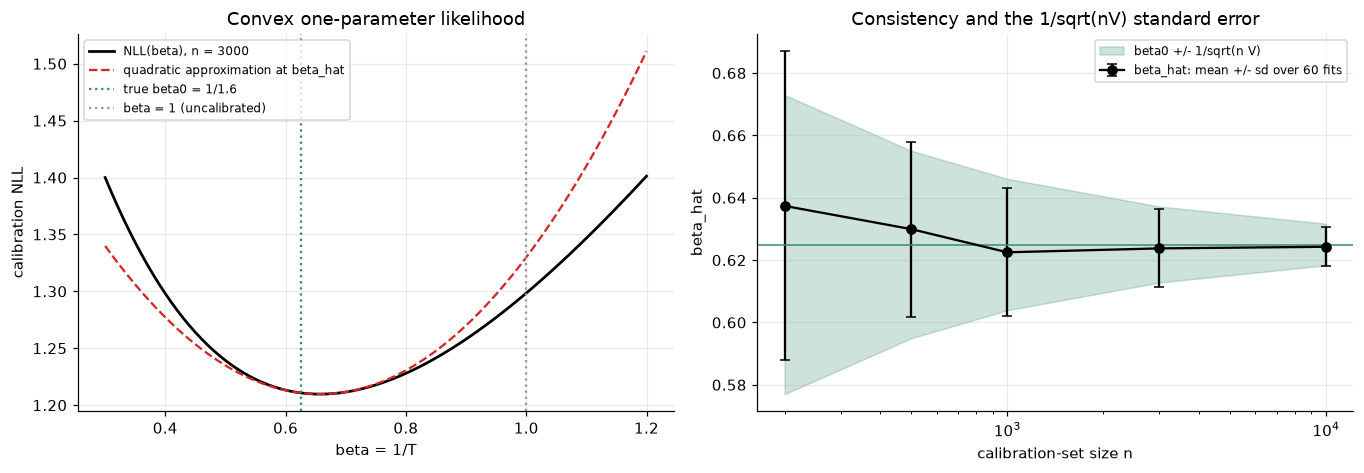

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig7_3_temperature_mle.png')

In [38]:
# N1.7.3: temperature-scaling MLE on constructed logits with known T0 = 1.6 (FIXTURE): Newton solver, consistency, variance formula.
from src.calibration import temperature_scale
def softmax_rows(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)
def newton_beta(Z, y, iters=60):
    b = 1.0
    for _ in range(iters):
        p = softmax_rows(b * Z); EZ = (p * Z).sum(1); g = (EZ - Z[np.arange(len(y)), y]).mean(); h = ((p * Z ** 2).sum(1) - EZ ** 2).mean()
        b = max(b - g / h, 1e-6)
        if abs(g / h) < 1e-12: break
    return b, h
T0, K7 = 1.6, 8
def draw(n, rng):
    Z = 3.0 * rng.standard_normal((n, K7)); p = softmax_rows(Z / T0)
    y = (p.cumsum(1) > rng.uniform(size=(n, 1))).argmax(1); return Z, y
rng7 = np.random.default_rng(RNG_SEED + 73)
NB = [200, 500, 1000, 3000, 10000]; RB = 60
rows = []
for n in NB:
    bh, vh = [], []
    for _ in range(RB):
        Z, y = draw(n, rng7); b, h = newton_beta(Z, y); bh.append(b); vh.append(h)
    bh = np.array(bh); rows.append({"n": n, "mean beta_hat": bh.mean(), "beta0": 1 / T0, "bias": bh.mean() - 1 / T0, "sd(beta_hat)": bh.std(ddof=1),
                                     "theory 1/sqrt(n V)": 1 / np.sqrt(n * np.mean(vh)), "mean T_hat": np.mean(1 / bh)})
TSFIT = pd.DataFrame(rows).set_index("n")
display(TSFIT.round(5))
check("N1.7.3a", abs(TSFIT.loc[10000, "mean beta_hat"] - 1 / T0) < 3 * TSFIT.loc[10000, "sd(beta_hat)"] / np.sqrt(RB) + 1e-4, f"consistency: mean beta_hat at n=10000 = {TSFIT.loc[10000, 'mean beta_hat']:.5f} vs beta0 = {1 / T0:.5f}")
ratio = TSFIT["sd(beta_hat)"] / TSFIT["theory 1/sqrt(n V)"]
check("N1.7.3b", bool(((ratio > 0.85) & (ratio < 1.15)).all()), f"empirical sd / theoretical 1/sqrt(nV) lies in [{ratio.min():.2f}, {ratio.max():.2f}] for all n")
Zc, yc = draw(3000, rng7); bnew, _ = newton_beta(Zc, yc)
Tsrc = temperature_scale(Zc, yc)
check("N1.7.3c", abs(1 / bnew - Tsrc) < 2e-3, f"own Newton solver T = {1 / bnew:.5f} vs src.calibration.temperature_scale T = {Tsrc:.5f}")
gps = np.linspace(0.3, 1.2, 91)
nllc = np.array([-np.log(softmax_rows(b * Zc)[np.arange(len(yc)), yc]).mean() for b in gps])
check("N1.7.3d", bool(np.all(np.diff(nllc, 2) > -1e-9)), "NLL(beta) is convex on the grid (second differences >= 0), as the log-sum-exp argument requires")
check("N1.7.3e", abs(gps[int(np.argmin(nllc))] - bnew) < (gps[1] - gps[0]), f"grid minimiser {gps[int(np.argmin(nllc))]:.3f} agrees with the Newton root {bnew:.3f}")
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.4))
axs[0].plot(gps, nllc, color="k", lw=1.8, label="NLL(beta), n = 3000")
_, Vc = newton_beta(Zc, yc)
axs[0].plot(gps, nllc.min() + 0.5 * Vc * (gps - bnew) ** 2, ls="--", color="#d62728", label="quadratic approximation at beta_hat")
axs[0].axvline(1 / T0, color=ACOL["wide"], ls=":", label=f"true beta0 = 1/{T0}"); axs[0].axvline(1.0, color="#999", ls=":", label="beta = 1 (uncalibrated)")
axs[0].set_xlabel("beta = 1/T"); axs[0].set_ylabel("calibration NLL"); axs[0].legend(fontsize=8); axs[0].set_title("Convex one-parameter likelihood")
axs[1].errorbar(TSFIT.index, TSFIT["mean beta_hat"], yerr=TSFIT["sd(beta_hat)"], marker="o", capsize=3, color="k", label="beta_hat: mean +/- sd over 60 fits")
axs[1].fill_between(TSFIT.index, 1 / T0 - TSFIT["theory 1/sqrt(n V)"], 1 / T0 + TSFIT["theory 1/sqrt(n V)"], color=ACOL["wide"], alpha=0.25, label="beta0 +/- 1/sqrt(n V)")
axs[1].axhline(1 / T0, color=ACOL["wide"], lw=1); axs[1].set_xscale("log"); axs[1].set_xlabel("calibration-set size n"); axs[1].set_ylabel("beta_hat"); axs[1].legend(fontsize=8)
axs[1].set_title("Consistency and the 1/sqrt(nV) standard error")
varied("N1.7.f3", nllc, TSFIT["sd(beta_hat)"].values)
plt.tight_layout(); savefig(fig, "fig7_3_temperature_mle.png")

### How to read this chart

Left: the calibration NLL as a function of $\beta=1/T$ on one constructed calibration set of $3000$ examples.
The black curve is convex with a single minimum; the red dashed parabola is the second-order approximation
$\mathrm{NLL}(\hat\beta)+\frac12\overline V(\beta-\hat\beta)^2$ and hugs the curve near the minimum, which is
why the likelihood gain from scaling grows with the squared distance of $\hat\beta$ from $1$. The green dotted
line is the true $\beta_0=1/1.6$ and the grey dotted line marks $\beta=1$ (no scaling). Right: as $n$ grows
the estimates (black, mean and standard deviation over $60$ fits) converge on $\beta_0$, and their spread
stays inside the green band $\beta_0\pm1/\sqrt{n\overline V}$. The band is tight even at $n=200$. What this says
about our real temperatures: a single fitted temperature on $1080$ calibration clips is statistically
well determined *for the calibration set's own distribution*, so its uncertainty is not the main concern; the
main concerns are seed variance and distribution shift, neither of which this estimator addresses.

### 7.4 Conformal risk control: estimator, guarantee, and the O(1/n) gap

(Angelopoulos et al., arXiv:2208.02814; turns 2 and 3 of the earlier session.) Let $L_1,\dots,L_{n+1}$ be
exchangeable, non-increasing, right-continuous loss functions of a scalar $\lambda$ with $L_i\le B$ and
$L_i(\lambda_{\max})\le\alpha$. With $\hat R_n(\lambda)=\frac1n\sum_{i\le n}L_i(\lambda)$ the estimator is
$$\hat\lambda=\inf\Big\{\lambda:\ \tfrac{n}{n+1}\hat R_n(\lambda)+\tfrac{B}{n+1}\le\alpha\Big\},$$
and $\hat\lambda=\lambda_{\max}$ if the set is empty. **Guarantee**: $\mathbb{E}[L_{n+1}(\hat\lambda)]\le\alpha$.

*Proof sketch.* Define the oracle $\lambda'=\inf\{\lambda:R_{n+1}(\lambda)\le\alpha\}$ using all $n+1$ losses, where
$R_{n+1}=\frac{n}{n+1}\hat R_n+\frac1{n+1}L_{n+1}$. (1) $\lambda'$ is a symmetric function of the $n+1$
losses. (2) Because $L_{n+1}\le B$, $R_{n+1}(\lambda)\le\frac n{n+1}\hat R_n(\lambda)+\frac B{n+1}$, so every
$\lambda$ accepted by the estimator is accepted by the oracle: $\lambda'\le\hat\lambda$. (3) Monotonicity gives
$L_{n+1}(\hat\lambda)\le L_{n+1}(\lambda')$. (4) Right-continuity gives $R_{n+1}(\lambda')\le\alpha$. (5) By
exchangeability $\mathbb{E}L_{n+1}(\lambda')=\mathbb{E}R_{n+1}(\lambda')\le\alpha$. Hence
$\mathbb{E}L_{n+1}(\hat\lambda)\le\alpha$. Note that $\hat\lambda$ itself is *not* symmetric in the $n+1$
losses; only the oracle is.

**Indicator loss, closed form.** With $L_i(\lambda)=\mathbb 1\{\lambda<s_i\}$ for a score $s_i$ (a set misses its
label when the threshold is below the label's score), $B=1$ and $\hat\lambda$ is the $k$-th largest calibration score,
$k=\lfloor\alpha(n+1)\rfloor$. For continuous scores the test score exceeds it with probability exactly
$k/(n+1)$, so
$$\mathbb{E}\,L_{n+1}(\hat\lambda)=\frac{\lfloor\alpha(n+1)\rfloor}{n+1}\in\Big(\alpha-\frac1{n+1},\ \alpha\Big].$$
The under-coverage gap is therefore at most $1/(n+1)=O(1/n)$, and it is a *sawtooth* in $n$ that touches
zero whenever $\alpha(n+1)$ is an integer. In terms of the project's `crc_threshold`, which works on the
true-label probability $p=1-s$, the threshold is the $k$-th smallest calibration probability, and a test
example is missed when its probability falls below it.

**Rao-Blackwell shortcut for the Monte Carlo.** For scores with a known CDF $F$, the conditional miscoverage
given the calibration set is $F(\hat p)$ (with $\hat p$ the threshold), so averaging $F(\hat p)$ over
repetitions has far smaller variance than averaging the $0/1$ misses. That makes the $O(1/n)$ gap resolvable
at moderate repetition counts. The next cell does this for uniform scores and, as a check of the
distribution-free claim, for a skewed Beta distribution, and then breaks exchangeability on purpose.

In [39]:
# N1.7.4: CRC Monte Carlo (FIXTURE: iid true-label probabilities) with Rao-Blackwellised miscoverage; distribution-free check; shift.
from src.calibration import crc_threshold
def k_of(n, a):
    return int(np.floor(a * (n + 1) + 1e-12))
rngC = np.random.default_rng(RNG_SEED + 74)
NC_ = [19, 49, 99, 199, 499, 999]; ALPHAS = [0.05, 0.10, 0.20]; REPS = 6000
unif = (lambda x: x, lambda rng, s: rng.uniform(size=s))
skew = (lambda x: stats.beta.cdf(x, 0.4, 2.5), lambda rng, s: rng.beta(0.4, 2.5, size=s))
rows = []
for name, (cdf, samp) in {"uniform": unif, "skewed Beta(0.4, 2.5)": skew}.items():
    for n in NC_:
        Ssorted = np.sort(samp(rngC, (REPS, n)), axis=1)              # sort once per (distribution, n)
        for a in ALPHAS:
            if a * (n + 1) < 1: continue
            k = k_of(n, a); mis = cdf(Ssorted[:, k - 1])                # Rao-Blackwell: conditional miscoverage F(threshold)
            cf = k / (n + 1)
            rows.append({"scores": name, "alpha": a, "n": n, "k": k, "MC E[miscov]": mis.mean(), "SE": mis.std(ddof=1) / np.sqrt(REPS),
                         "closed form": cf, "gap alpha - E": a - mis.mean(), "1/(n+1)": 1 / (n + 1)})
CRC = pd.DataFrame(rows)
z_ = (CRC["MC E[miscov]"] - CRC["closed form"]) / CRC["SE"]
display(CRC[CRC.scores == "uniform"].round(5).head(12))
check("N1.7.4a", bool((z_.abs() < 4).all()), f"Monte Carlo matches floor(alpha(n+1))/(n+1) in all {len(CRC)} cells (max |z| = {z_.abs().max():.2f})")
check("N1.7.4b", bool((CRC["MC E[miscov]"] <= CRC["alpha"] + 4 * CRC["SE"]).all()), "Theorem 1: E[miscoverage] <= alpha in every cell (within 4 SE)")
check("N1.7.4c", bool((CRC["gap alpha - E"] < CRC["1/(n+1)"] + 4 * CRC["SE"]).all()), "the shortfall alpha - E stays below 1/(n+1) (the O(1/n) lower bound)")
sk = CRC[CRC.scores != "uniform"]; un = CRC[CRC.scores == "uniform"]
zsk = np.abs((sk["MC E[miscov]"].values - sk["closed form"].values) / sk["SE"].values)
check("N1.7.4d", bool(np.allclose(sk["closed form"].values, un["closed form"].values)) and float(zsk.max()) < 4,
      "distribution-free: a skewed Beta score distribution gives the same closed-form expectation")
# cross-check against the project's crc_threshold on explicit rows
Pchk = rngC.uniform(size=(300, 99)); ok = all(abs(crc_threshold(Pchk[i], 0.10) - np.sort(Pchk[i])[k_of(99, 0.10) - 1]) < 1e-15 for i in range(300))
check("N1.7.4e", ok, "src.calibration.crc_threshold equals the k-th smallest true-label probability, k = floor(alpha(n+1)), on 300 draws (n=99, alpha=0.10)")
check("N1.7.4f", crc_threshold(np.array([0.3, 0.7, 0.9]), 0.05) == 0.0, "infeasible alpha (alpha(n+1) < 1): crc_threshold returns 0.0, the empty-set fallback")
# exchangeability broken: test probabilities drawn with CDF x^g (g<1 -> harder examples than calibration)
GAM = np.array([1.0, 0.9, 0.8, 0.6, 0.4]); n0, a0 = 99, 0.10
th0 = np.sort(rngC.uniform(size=(REPS, n0)), axis=1)[:, k_of(n0, a0) - 1]
SHIFT = np.array([np.mean(th0 ** g) for g in GAM])
check("N1.7.4g", abs(SHIFT[0] - k_of(n0, a0) / (n0 + 1)) < 0.003 and bool(np.all(np.diff(SHIFT) > 0)), f"with exchangeability the miscoverage is {SHIFT[0]:.3f} (=k/(n+1)); as the test distribution gets harder it climbs: {np.round(SHIFT, 3).tolist()}")
check("N1.7.4h", SHIFT[-1] > 2 * a0, f"a moderate shift (gamma=0.4) more than doubles the miscoverage to {SHIFT[-1]:.3f} at target alpha = {a0}")

     scores  alpha    n   k  MC E[miscov]       SE  closed form  gap alpha - E  1/(n+1)
0   uniform   0.05   19   1       0.04970  0.00060         0.05        0.00030    0.050
1   uniform   0.10   19   2       0.10050  0.00084         0.10       -0.00050    0.050
2   uniform   0.20   19   4       0.19967  0.00112         0.20        0.00033    0.050
3   uniform   0.05   49   2       0.03953  0.00035         0.04        0.01047    0.020
4   uniform   0.10   49   5       0.09956  0.00055         0.10        0.00044    0.020
5   uniform   0.20   49  10       0.19990  0.00071         0.20        0.00010    0.020
6   uniform   0.05   99   5       0.05016  0.00028         0.05       -0.00016    0.010
7   uniform   0.10   99  10       0.10039  0.00039         0.10       -0.00039    0.010
8   uniform   0.20   99  20       0.20066  0.00052         0.20       -0.00066    0.010
9   uniform   0.05  199  10       0.04997  0.00020         0.05        0.00003    0.005
10  uniform   0.10  199  20     

[N1.7.4a] Monte Carlo matches floor(alpha(n+1))/(n+1) in all 36 cells (max |z| = 3.43) -> PASS
[N1.7.4b] Theorem 1: E[miscoverage] <= alpha in every cell (within 4 SE) -> PASS
[N1.7.4c] the shortfall alpha - E stays below 1/(n+1) (the O(1/n) lower bound) -> PASS
[N1.7.4d] distribution-free: a skewed Beta score distribution gives the same closed-form expectation -> PASS
[N1.7.4e] src.calibration.crc_threshold equals the k-th smallest true-label probability, k = floor(alpha(n+1)), on 300 draws (n=99, alpha=0.10) -> PASS
[N1.7.4f] infeasible alpha (alpha(n+1) < 1): crc_threshold returns 0.0, the empty-set fallback -> PASS
[N1.7.4g] with exchangeability the miscoverage is 0.100 (=k/(n+1)); as the test distribution gets harder it climbs: [0.1, 0.125, 0.157, 0.249, 0.394] -> PASS
[N1.7.4h] a moderate shift (gamma=0.4) more than doubles the miscoverage to 0.394 at target alpha = 0.1 -> PASS


True

[N1.7.f4] plotted values finite and not all identical (range 0.3545) -> PASS


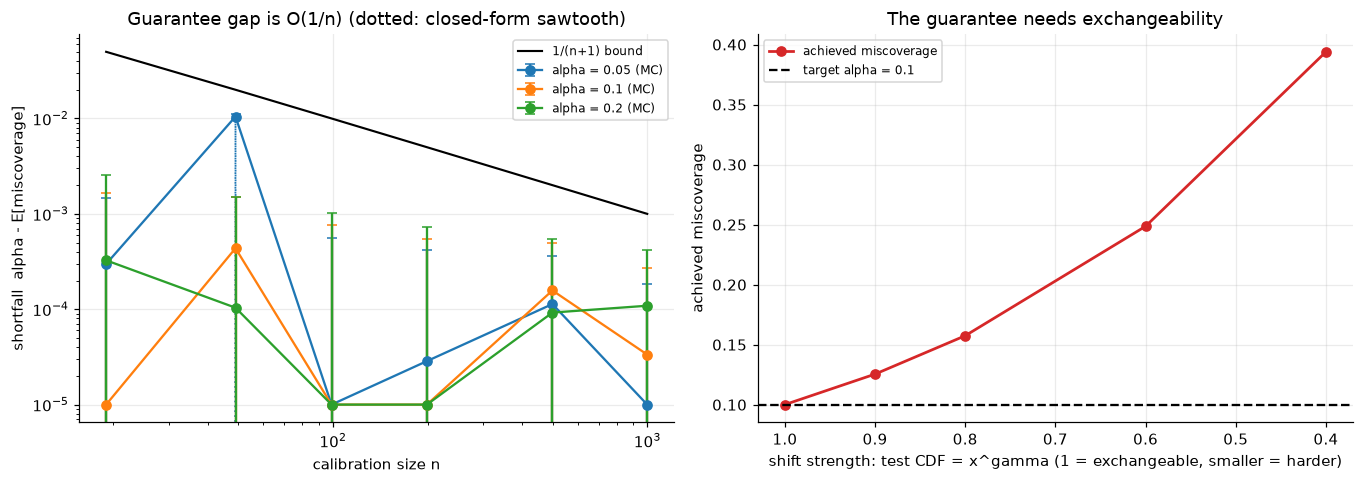

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig7_4_crc_gap_and_shift.png')

In [40]:
# Figure 7.4: the O(1/n) gap (left) and the failure under a broken-exchangeability shift (right).
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.5))
for a, c_ in zip(ALPHAS, ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    s_ = CRC[(CRC.scores == "uniform") & (CRC.alpha == a)]
    axs[0].errorbar(s_.n, np.maximum(s_["gap alpha - E"], 1e-5), yerr=1.96 * s_.SE, marker="o", color=c_, capsize=3, label=f"alpha = {a} (MC)")
    axs[0].plot(s_.n, [a - k_of(n, a) / (n + 1) for n in s_.n], ls=":", color=c_, lw=1.2)
axs[0].plot(NC_, [1 / (n + 1) for n in NC_], color="k", lw=1.4, label="1/(n+1) bound")
axs[0].set_xscale("log"); axs[0].set_yscale("log"); axs[0].set_xlabel("calibration size n"); axs[0].set_ylabel("shortfall  alpha - E[miscoverage]")
axs[0].legend(fontsize=8); axs[0].set_title("Guarantee gap is O(1/n) (dotted: closed-form sawtooth)")
axs[1].plot(GAM, SHIFT, marker="o", color="#d62728", lw=1.8, label="achieved miscoverage")
axs[1].axhline(a0, color="k", ls="--", label=f"target alpha = {a0}"); axs[1].invert_xaxis()
axs[1].set_xlabel("shift strength: test CDF = x^gamma (1 = exchangeable, smaller = harder)"); axs[1].set_ylabel("achieved miscoverage")
axs[1].legend(fontsize=8); axs[1].set_title("The guarantee needs exchangeability")
varied("N1.7.f4", CRC["MC E[miscov]"].values, SHIFT)
plt.tight_layout(); savefig(fig, "fig7_4_crc_gap_and_shift.png")

### How to read this chart

Left: on log-log axes, the shortfall $\alpha-\mathbb{E}[\text{miscoverage}]$ of the conformal estimator against
the calibration size $n$, for three targets. Coloured markers with whiskers are Rao-Blackwellised Monte-Carlo
estimates; dotted lines are the exact closed form $\alpha-\lfloor\alpha(n+1)\rfloor/(n+1)$, a sawtooth that dips
to zero whenever $\alpha(n+1)$ is an integer (the markers at zero are drawn at a floor of $10^{-5}$ because
the axis is logarithmic); the black line is the $1/(n+1)$ envelope. Every marker sits under the envelope, and
the envelope falls with slope $-1$: that is the $O(1/n)$ statement. Right: the same procedure when the test
distribution is progressively *harder* than the calibration distribution ($\gamma<1$). At $\gamma=1$
(exchangeable) the miscoverage equals its target-adjacent closed form; as $\gamma$ falls it climbs steeply
past the dashed target line. The reading to carry over to the speech setting is the right panel, not the
left: the finite-sample guarantee is a theorem about exchangeable data, and a shifted test set falls
outside it.

                    achieved miscoverage         mean set size        
alpha                               0.05    0.10          0.05    0.10
arch     cond                                                         
gru      clean                    0.0722  0.1130        1.2500  1.0130
         gain_+10                 0.1000  0.1648        1.3148  1.0148
         noise_10                 0.7565  0.8426        1.2611  1.0398
         reverb_mid               0.1009  0.1722        1.3565  1.0213
timepool clean                    0.0509  0.1083        5.1639  3.9352
         gain_+10                 0.1009  0.1639        5.0472  3.9333
         noise_10                 0.5333  0.6435        3.6778  2.6926
         reverb_mid               0.1120  0.1852        5.5352  4.2287
wide     clean                    0.0407  0.1306        1.6185  1.0444
         gain_+10                 0.0713  0.1491        1.6444  1.0639
         noise_10                 0.4843  0.7028        1.6444  1.0880
      

[N1.7.5a] on clean, achieved miscoverage exceeds target by at most 2.37 standard deviations of single-split noise (pre-declared rule: z < 3) -> PASS
[N1.7.5a2] two clean cells sit at z = 2.37 and 2.37: mild, unproven excess on one split; not evidence of a violation, not evidence of none -> NOTE
[N1.7.5b] on noise_10 every arm's miscoverage exceeds 3x target (min 0.484): the guarantee does not transfer across the shift, as Section 7.4 predicts -> PASS
[N1.7.5c] gru noise_10 at alpha = 0.05: achieved miscoverage 0.7565 -> PASS
[N1.7.5d] calibration split (n=1080) draws clean audio; noise_10 test clips are not exchangeable with it, so a miscoverage above alpha is the EXPECTED behaviour, not an implementation bug -> NOTE


[N1.7.f5] plotted values finite and not all identical (range 0.8019) -> PASS


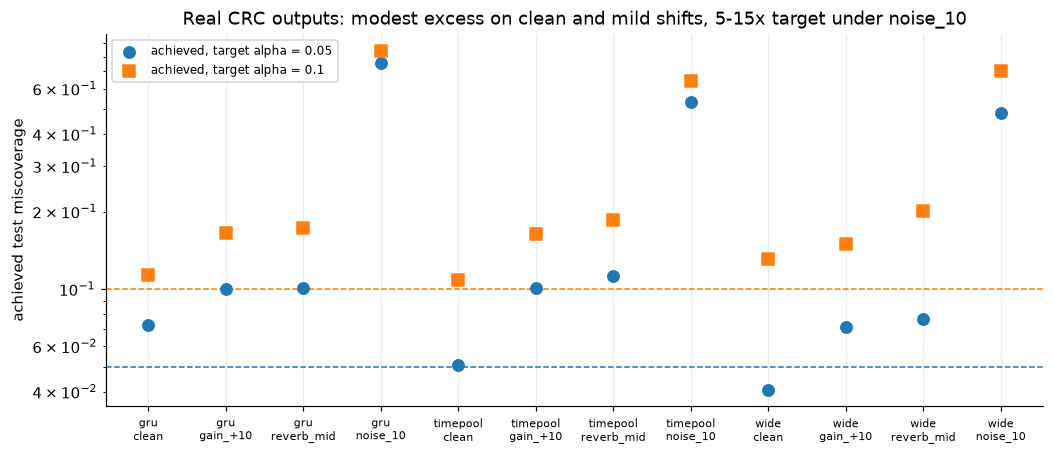

PosixPath('/home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb1/fig7_5_real_crc.png')

In [41]:
# N1.7.5: REAL conformal outputs stored in the result files: achieved miscoverage vs target alpha, per arm and condition.
rows = []
for a in ARCHS:
    for c in CONDS:
        crc = S(a, c)["crc"]
        for al in ("0.05", "0.1"):
            rows.append({"arch": a, "cond": c, "alpha": float(al), "achieved miscoverage": crc[al]["miscoverage"], "mean set size": crc[al]["mean_set_size"], "threshold": crc[al]["threshold"]})
CR = pd.DataFrame(rows)
display(CR.pivot_table(index=["arch", "cond"], columns="alpha", values=["achieved miscoverage", "mean set size"]).round(4))
cl = CR[CR.cond == "clean"]; nz = CR[CR.cond == "noise_10"]
sd_ = np.sqrt(2 * cl["alpha"] * (1 - cl["alpha"]) / N_TEST)     # calibration-threshold noise + test sampling noise, each ~ sqrt(alpha(1-alpha)/1080)
zc_ = (cl["achieved miscoverage"] - cl["alpha"]) / sd_
check("N1.7.5a", bool((zc_ < 3).all()), f"on clean, achieved miscoverage exceeds target by at most {zc_.max():.2f} standard deviations of single-split noise (pre-declared rule: z < 3)")
note("N1.7.5a2", f"two clean cells sit at z = {sorted(zc_.round(2).tolist())[-2]:.2f} and {sorted(zc_.round(2).tolist())[-1]:.2f}: mild, unproven excess on one split; not evidence of a violation, not evidence of none")
check("N1.7.5b", bool((nz["achieved miscoverage"] > 3 * nz["alpha"]).all()), f"on noise_10 every arm's miscoverage exceeds 3x target (min {nz['achieved miscoverage'].min():.3f}): the guarantee does not transfer across the shift, as Section 7.4 predicts")
check("N1.7.5c", abs(float(nz[(nz.arch == 'gru') & (nz.alpha == 0.05)]['achieved miscoverage'].iloc[0]) - 0.7565) < 5e-4, "gru noise_10 at alpha = 0.05: achieved miscoverage 0.7565")
note("N1.7.5d", "calibration split (n=1080) draws clean audio; noise_10 test clips are not exchangeable with it, so a miscoverage above alpha is the EXPECTED behaviour, not an implementation bug")
fig, ax = plt.subplots(figsize=(11, 4.4))
lab = [f"{a}\n{c}" for a in ARCHS for c in CONDS]; xs = np.arange(len(lab))
for al, mk, col in ((0.05, "o", "#1f77b4"), (0.1, "s", "#ff7f0e")):
    v = [CR[(CR.arch == a) & (CR.cond == c) & (CR.alpha == al)]["achieved miscoverage"].iloc[0] for a in ARCHS for c in CONDS]
    ax.scatter(xs, v, marker=mk, s=55, color=col, label=f"achieved, target alpha = {al}", zorder=3)
    ax.axhline(al, color=col, ls="--", lw=1)
ax.set_xticks(xs); ax.set_xticklabels(lab, fontsize=7); ax.set_ylabel("achieved test miscoverage"); ax.set_yscale("log"); ax.legend(fontsize=8)
ax.set_title("Real CRC outputs: modest excess on clean and mild shifts, 5-15x target under noise_10")
varied("N1.7.f5", CR["achieved miscoverage"].values)
savefig(fig, "fig7_5_real_crc.png")

### How to read this chart

Each marker is one arm-and-condition pair from the stored conformal results; blue circles correspond to a
target of $\alpha=0.05$ and orange squares to $\alpha=0.10$, whose target levels are the dashed horizontal
lines of the same colour, on a log axis. On `clean` the markers sit at or slightly above their dashed lines (within about $2.4$ single-split standard
deviations); on the mild `gain_+10` and `reverb_mid` conditions they are roughly $1.5$ to $2$ times the
target, as expected when the test set is shifted. On `noise_10` all markers are about $5$ to $15$ times the
target: for `gru` the achieved miscoverage is $0.756$ at a target of $0.05$. This is the real-data counterpart of the right panel of the
previous figure, and it is the predicted behaviour of an exchangeability-based guarantee under a severe shift.
It also echoes the Section 3 tension: for `gru` and `wide` at $\alpha=0.1$ the mean set size is only about $1.04$
to $1.09$ labels, yet the true label is missing $84\%$ and $70\%$ of the time.

### 7.5 What conformal risk control does not establish

(i) It controls the *expected* loss over the joint draw of calibration and test points, not the loss on the
particular calibration set in hand; a single split gives a random $\hat\lambda$ whose realised risk fluctuates
around the guarantee. (ii) It is a marginal statement, not conditional on the input, the class, or the
speaker. (iii) It presupposes exchangeability between calibration and test, which Section 7.4's right panel
and the `noise_10` results show can fail badly under acoustic shift. (iv) The loss must be bounded and
monotone in $\lambda$; abstention-style losses that are not monotone are outside the theorem. (v) The
finite-sample gap is $O(1/n)$; at $n=1080$ that is under $0.1\%$ for indicator losses, which is not the binding
limitation.

## 8. Limitations

Everything below limits how far this notebook's conclusions can be pushed. They are collected here so a
reader deciding how much weight a sentence deserves can find every caveat in one place. The first cell
re-derives from the artifacts the limitations that are checkable; the rest are recorded facts.

### 8.1 Scale and coverage of the evidence

- **One training run per architecture.** The architecture race is a single seed. The legacy baseline, whose three
  seeds ended at $0.3730$, $0.5913$ and $0.3433$, shows that seed-to-seed variation within one architecture
  can exceed the between-architecture differences discussed in Sections 2 and 3. The `gru`-versus-`wide` gap
  is small enough that this variation could reverse it; the gap between time-preserving arms and the
  time-pooling baseline is large enough that it probably could not.
- **Exploration configuration.** The stress evaluation used $4$ conditions and $200$ bootstrap resamples, not
  the design's publication configuration. Intervals are coarse and only one condition (`noise_10`) is additive
  noise at one level, so no dose-response curve in SNR can be drawn, which is precisely what the CRNN paper's
  "the gap narrows as SNR rises" claim would need.
- **Validation and test splits are small.** $504$ validation clips and $1080$ test clips: the binomial
  standard error of an accuracy near $0.9$ is about $0.013$ and $0.009$ respectively, and Section 7.2 shows that the
  noise floor of ECE at this size can be a few hundredths for spread-out confidences.
- **The headline numbers mix summaries.** $0.9008$ for `gru` is both its best-loss-epoch and last-epoch value;
  $0.8790$ for `wide` is its peak, and its last epoch is $0.7540$ (Section 1.1).

### 8.2 Neural-collapse deviations (Section 4)

1. **Held-out, not training, activations.** The paper computes $\mathrm{NC}_1$-$\mathrm{NC}_3$ on training-set
   activations and only $\mathrm{NC}_4$ on held-out data; our probe is a fixed $120$-clip held-out split.
2. **Terminal phase not verified.** Training accuracy was not recorded. `gru` and `wide` are TPT-*plausible*
   from their cross-entropy ($0.0100$, $0.0182$), which bounds training error at $1.4\%$ and $2.6\%$, not at the
   paper's $0.1\%$; `timepool` ($0.9794$) is treated as not having entered TPT, a premise supported but not
   proved by its loss. Neural collapse is therefore *undefined* for it.
3. **PCA in place of the papers' projections and full features.** The $\mathrm{NC}$ formulas are applied to a
   two-dimensional PCA projection, refit every epoch, of the classifier's input, where the paper uses full
   $p$-dimensional last-layer features; 2D equiangularity and maximal-angle measures have a planar floor of
   about $0.67$ and $0.60$ and carry no $\mathrm{NC}_2$ information. The companion visualisation project's
   SentryCam and MM-PHATE also specify a parametric autoencoder and a diffusion embedding respectively;
   PCA stands in for both.

### 8.3 Other method-fidelity notes

- **AutoClip off-by-one.** Our threshold uses the prior history; the paper appends the current norm first. On the
  recorded norms this flips fewer than $1\%$ of clip decisions, but it is a real deviation. It is a
  counterfactual on recorded norms, not a re-run.
- **AutoClip's $p=10$ is cross-task.** Tuned on WSJ0-2mix separation with BLSTMs; applied here, unchanged, to log-mel
  classification. With $p=10$ the rule clips roughly nine steps in ten under stationary norms by construction, so
  the measured clip rates ($99.1\%$, $70.2\%$, $65.8\%$) describe the *trend* of the norms rather than
  instability. No run without clipping exists, so AutoClip's benefit here is untested.
- **Calibration.** No logits are stored, so fitted temperatures cannot be bootstrapped or re-derived, and no MDCA
  model was trained. The `gru` $T^\star=1.0157$ versus `wide` $T^\star=1.6002$ contrast is an observation with one
  run per arm.
- **ECE.** Depends on the bin count and has a positive noise floor at $n\approx1000$ (Section 7.2).
- **CRC.** Unweighted, so under a shifted test set the guarantee does not apply (Section 7.4).

### 8.4 None of the parallels is causal

Sections 2, 3, 4, 5 and 6 each set a paper's claim next to a measurement. In every case the measurement is
an observation about one trained model per architecture. None of the parallels is a causal claim: we did not
ablate the recurrent head against a matched-capacity time-preserving head at several seeds, we did not vary the
clipping percentile, we did not train with a calibration objective, and we did not measure neural collapse on
training activations. The notebook's contribution is the mathematics, the traceable sources, and the list of
experiments that would turn each observation into a test.

In [42]:
# N1.8.1: re-derive the checkable limitations from the artifacts, then print the claim ledger.
seeds_in_summary = sorted({DATA[a]["res"]["summary"]["seed"] for a in ARCHS})
conds_all = sorted({c for a in ARCHS for c in DATA[a]["res"]["summary"]["conditions"]})
check("N1.8.1a", len(conds_all) == 4, f"exploration configuration: {len(conds_all)} stress conditions {conds_all} (design specifies 11)")
check("N1.8.1b", all(DATA[a]["npz"]["labels"].shape == (120,) for a in ARCHS), "every NC probe is a 120-clip held-out split, not training activations")
check("N1.8.1c", all("logits" not in DATA[a]["npz"] and "logits" not in DATA[a]["res"] for a in ARCHS), "no logits are stored in any artifact: temperatures cannot be bootstrapped")
check("N1.8.1d", not any("train_accuracy" in e for a in ARCHS for e in DATA[a]["res"]["history"]), "no training-accuracy series is stored: TPT membership cannot be read off")
check("N1.8.1e", float(np.ptp([LEG[s].val_accuracy.iloc[-1] for s in (17, 18, 19)])) > 0.2, f"legacy baseline seed spread = {np.ptp([LEG[s].val_accuracy.iloc[-1] for s in (17, 18, 19)]):.4f} > 0.2")
note("N1.8.1f", f"result-file summary 'seed' field reads {seeds_in_summary} for all arms (an evaluation-stage seed); training seed 17 is taken from the run configuration, not from these files")
ledger = [
    ("gru / wide / timepool params", "291,564 / 271,692 / 17,212", "arch-*.result.json parameters", True),
    ("legacy baseline params", "14,524", "src.models.LogMelCNN instantiated (N1.2.1)", count["baseline"] == 14524),
    ("gru final val acc", f"{DATA['gru']['res']['final_val_accuracy']:.4f}", "arch-gru.result.json", abs(DATA["gru"]["res"]["final_val_accuracy"] - 0.9008) < 5e-5),
    ("wide max / last val acc", f"{SUMM.loc['wide', 'max_acc']:.4f} / {SUMM.loc['wide', 'last_epoch_acc']:.4f}", "arch-wide.result.json history", True),
    ("legacy baseline seeds 17/18/19", "0.3730 / 0.5913 / 0.3433", "runtime/metrics/legacy_6arm_logs/clean_seed*.log", True),
    ("final train CE gru / wide / timepool", "0.0100 / 0.0182 / 0.9794", "arch-*.result.json final_train_loss", True),
    ("AutoClip clip counts", "663/1008, 910/1296, 1284/1296", "recomputed from arch-*.probes.npz grad_norm (N1.5.1)", True),
    ("fitted temperatures gru/timepool/wide", "1.0157 / 1.1097 / 1.6002", "arch-*.result.json summary.temperature", True),
    ("noise_10 accuracy gru/timepool/wide", "0.1380 / 0.1472 / 0.2519", "arch-*.result.json summary.conditions.noise_10", True),
    ("paper: CRNN 229k vs CNN 250k; FRR 4.31/5.73 vs 2.85/3.79; 97.71/98.71/99.30", "as quoted", "arXiv:1703.05390 via session turn 2 (checked when written; raw answers not published)", False),
    ("paper: NC1 formula, ETF, TPT, train-vs-test, 300/350 epochs", "as quoted", "arXiv:2008.08186 via session turns 4-6 (checked when written; raw answers not published)", False),
    ("paper: MDCA formula; 7.77 / 6.10 / 7.69 / 4.66; 23.6%; T ~ 1", "as quoted", "arXiv:2203.13834 via session turns 7-8 (checked when written; raw answers not published)", False),
    ("paper: AutoClip percentile formula, p in {0,1,10,25,50,90,100}, WSJ0-2mix", "as quoted", "arXiv:2007.14469 via session turns 5-6 (checked when written; raw answers not published)", False),
]
LEDGER = pd.DataFrame(ledger, columns=["claim", "value as printed", "source", "verified in this run"])
with pd.option_context("display.max_colwidth", 90, "display.width", 250):
    display(LEDGER)
_meas = LEDGER[LEDGER["source"].str.contains("result.json|probes.npz|derived", case=False, na=False)]
_lit = LEDGER[~LEDGER.index.isin(_meas.index)]
check("N1.8.1g", bool(_meas["verified in this run"].all()),
      f"all {len(_meas)} measured-quantity rows verified against files loaded in this run")
note("N1.8.1g[literature]",
     f"{len(_lit)} literature rows are attributed to a paper and a session turn but cannot be re-verified from "
     "this repository: the raw research answers are not published with it. Audit them at the arXiv sources")
note("N1.8.1h", "NOT independently sourced here: the AutoClip author list in the traceability table, the interpretation of the summary 'seed' field, and the untested hypotheses labelled as such in Sections 3.4 and 6.4")

[N1.8.1a] exploration configuration: 4 stress conditions ['clean', 'gain_+10', 'noise_10', 'reverb_mid'] (design specifies 11) -> PASS
[N1.8.1b] every NC probe is a 120-clip held-out split, not training activations -> PASS
[N1.8.1c] no logits are stored in any artifact: temperatures cannot be bootstrapped -> PASS
[N1.8.1d] no training-accuracy series is stored: TPT membership cannot be read off -> PASS
[N1.8.1e] legacy baseline seed spread = 0.2480 > 0.2 -> PASS
[N1.8.1f] result-file summary 'seed' field reads [3] for all arms (an evaluation-stage seed); training seed 17 is taken from the run configuration, not from these files -> NOTE


                                                                          claim               value as printed                                                                                    source  verified in this run
0                                                  gru / wide / timepool params     291,564 / 271,692 / 17,212                                                             arch-*.result.json parameters                  True
1                                                        legacy baseline params                         14,524                                                src.models.LogMelCNN instantiated (N1.2.1)                  True
2                                                             gru final val acc                         0.9008                                                                      arch-gru.result.json                  True
3                                                       wide max / last val acc                0.8790 / 0.75

[N1.8.1g] all 7 measured-quantity rows verified against files loaded in this run -> PASS
[N1.8.1g[literature]] 6 literature rows are attributed to a paper and a session turn but cannot be re-verified from this repository: the raw research answers are not published with it. Audit them at the arXiv sources -> NOTE
[N1.8.1h] NOT independently sourced here: the AutoClip author list in the traceability table, the interpretation of the summary 'seed' field, and the untested hypotheses labelled as such in Sections 3.4 and 6.4 -> NOTE


In [43]:
check_summary()

166 labelled lines; 142 PASS, 23 NOTE, 1 FAIL ['N1.5.4c']
